# Análisis Exploratorio de Datos — Proyecto Integrador CRC

## Análisis de la contribución de biomarcadores lipidómicos y metabolómicos en modelos de machine learning para cáncer de colon

**Conjunto de datos:** `BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv` (211 observaciones × 138 variables).

**Procedencia del conjunto de datos:** Albóniga, O. E. et al. (2025). *Metabolic Signature in Combination with Fecal Immunochemical Test as a Non-Invasive Tool for Advanced Colorectal Neoplasia Diagnosis*. **Cancers**, 17, 2339. DOI: [10.3390/cancers17142339](https://doi.org/10.3390/cancers17142339). La denominación del archivo (`Data Mat`) corresponde al Supplementary File S1 (`MX_SuppTable.xlsx → DataMat`) del estudio original. Distribuido bajo licencia Creative Commons Attribution 4.0.

**Alcance del documento:** El presente análisis comprende el Análisis Exploratorio de Datos (EDA) completo, orientado a preparar el conjunto de datos para la construcción de un clasificador supervisado multiclase. Está estructurado en cinco pasos:

1. **Configuración inicial** y reconstrucción de encabezados anidados, diccionario de variables.
2. **Diagnóstico de calidad** del conjunto de datos: missingness, duplicados, cardinalidad de variables categóricas.
3. **Caracterización de distribuciones**, evaluación comparativa de transformaciones (raw, log1p, Yeo-Johnson, Box-Cox), imputación validada y detección de valores atípicos.
4. **Selección supervisada de variables** mediante `SelectKBest`: prueba χ² sobre categóricas one-hot e información mutua (`mutual_info_classif`) sobre numéricas, con ranking consolidado.
5. **Estructura multivariada** mediante correlación agrupada por familia y PCA con elipses de confianza, más atributos estructurales derivados (longitud de cadena, insaturación, plasmalógenos) evaluados con información mutua.

> El modelado supervisado se encuentra **fuera del alcance** del presente documento y se reserva para el Avance 2 del proyecto.

**Variable objetivo:** `group`, de naturaleza categórica con tres niveles:

- **CTRL** — Controles sanos (n = 78).
- **AA** — Adenoma avanzado (n = 58), considerado etapa precursora del adenocarcinoma colorrectal.
- **CRC** — Cáncer colorrectal confirmado mediante colonoscopía (n = 75).

---

**Proyecto Integrador — Equipo 22**

| Integrante | Matrícula |
|---|---|
| María Virginia Mendizábal Miranda | A01796588 |
| Gianmel Joannelly Hernandez Tosta | A01795919 |
| Sofía Ordaz López | A01173717 |


## 1. Configuración inicial

In [1]:
# Imports estándar para EDA
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)

print('Setup listo.')


Setup listo.


In [2]:
# Ruta del dataset con búsqueda automática (compatible con estructura de repo)
import os

DATA_FILENAME = 'BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv'

# Buscar el dataset en las ubicaciones posibles según donde se ejecute la libreta
candidate_paths = [
    os.path.join('..', 'data', DATA_FILENAME),        # Si se ejecuta desde notebooks/
    os.path.join('data', DATA_FILENAME),               # Si se ejecuta desde la raíz del repo
    os.path.join('.', DATA_FILENAME),                  # Si está en el mismo directorio
    os.path.join('/Users/sofiaordazlopez/Documents/Proyecto Integrador', DATA_FILENAME),  # Ruta absoluta (entorno original)
]

file_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if file_path is None:
    raise FileNotFoundError(
        f"No se encontró el archivo '{DATA_FILENAME}'. "
        f"Asegúrate de tener el conjunto de datos en la carpeta data/ del repositorio."
    )

print('Ruta del archivo:', file_path)
print('Archivo encontrado:', os.path.exists(file_path))


Ruta del archivo: ../data/BASE DE DATOS CRC PROYECT LABELED(Data Mat).csv
Archivo encontrado: True


## 2. Carga del archivo y reconstrucción de encabezados

El archivo CSV presenta una estructura particular: las primeras **cuatro filas** contienen metadatos anidados que describen las columnas, mientras que las observaciones inician en la quinta fila. La reconstrucción manual de encabezados resulta necesaria para preservar la información jerárquica.

| Fila | Contenido |
|---|---|
| 0 | Familia lipídica (`SPHINGOLIPIDS`, `GLYCEROLIPIDS`, entre otras) — presente únicamente en columnas específicas |
| 1 | Subfamilia o denominación de variable clínica (`Ceramides`, `AGE`, `FIT`, etc.) |
| 2 | Notación individual del metabolito (`Cer(d18:1/16:0)`, `CE(18:2)`, etc.) |
| 3 | Composición probable o identificador complementario |
| 4 en adelante | Observaciones individuales (pacientes) |


In [3]:
# Cargar archivo crudo. Encoding latin1 por caracteres especiales en columnas clínicas.
raw = pd.read_csv(file_path, encoding='latin1', header=None)

print(f'Dimensiones del archivo crudo: {raw.shape}')
print('\nPrimeras 4 filas (metadata) — columnas 0-10:')
display(raw.iloc[:4, :11])


Dimensiones del archivo crudo: (215, 138)

Primeras 4 filas (metadata) — columnas 0-10:


,0,1,2,3,4,5,6,7,8,9,10
0,NaN,NaN,GROUP (Class label 1),NaN,FOB yes/no (categorical) (Class label 3),NaN,FIT µg/g (numerical),NaN,NaN,NaN,NaN
1,SAMPLE,SAMPLE.ID,CTRL (CONTROL),GENDER (Class label 2),Sangre Oculta en Heces. Detecta sangrado en el...,AGE,"Prueba Inmunoquimica Fecal, proporciona medici...",Z AGE,Z FOB,Age standarized,FIT standarized
2,INDIVIDUAL NOTATION,NaN,AA (ADENOCARCINOMA),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,INDIVIDUAL COMPOSITION OR PROBABLE ID,NaN,CRC (CANCER),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Separar metadata (filas 0-3) y datos (fila 4 en adelante)
metadata_rows = raw.iloc[0:4, :].copy()
data = raw.iloc[4:, :].copy().reset_index(drop=True)

# La fila 0 (familia) tiene NaN en columnas intermedias. ffill propaga la familia
# hacia la derecha para que cada columna lipídica tenga su familia asignada.
families = metadata_rows.iloc[0, :].ffill()
subfamilies = metadata_rows.iloc[1, :]
metabolite_names = metadata_rows.iloc[2, :]
probable_ids = metadata_rows.iloc[3, :]

# Nota importante: en el archivo crudo la familia GLYCEROPHOSPHOLIPIDS aparece bajo
# DOS etiquetas distintas — 'GLYCEROPHOSPHOLIPIDS' (con S) y 'GLYCEROPHOSPHOLIPID'
# (sin S). Es un typo: son la misma familia química, lo confirma el paper original
# (Albóniga et al. 2025) en la sección 2.3. Las unificamos antes de cualquier
# agregación por familia.
families = families.astype('object').replace({'GLYCEROPHOSPHOLIPID': 'GLYCEROPHOSPHOLIPIDS'})

print('Familias únicas detectadas (después de unificación):')
print(families.dropna().unique())


Familias únicas detectadas (después de unificación):
['GROUP (Class label 1)' 'FOB yes/no (categorical) (Class label 3)'
 'FIT  µg/g (numerical)' 'SPHINGOLIPIDS' 'STEROL LIPID'
 'GLYCEROPHOSPHOLIPIDS' 'GLYCEROLIPIDS']


In [5]:
# Mapeo manual de las primeras 11 columnas (variables clínicas e identificadores)
base_names = {
    0: 'sample',
    1: 'sample_id',
    2: 'group',
    3: 'gender',
    4: 'fob',
    5: 'age',
    6: 'fit_ug_g',
    7: 'z_age',
    8: 'z_fob',
    9: 'age_standardized',
    10: 'fit_standardized'
}

new_cols = []
seen = {}

for i in range(raw.shape[1]):
    if i in base_names:
        col = base_names[i]
    else:
        name = metabolite_names.iloc[i]
        if pd.isna(name) or str(name).strip().lower() == 'nan':
            name = subfamilies.iloc[i]
        if pd.isna(name) or str(name).strip().lower() == 'nan':
            name = f'feature_{i}'
        col = re.sub(r'\s+', ' ', str(name).strip())
        if col in seen:
            seen[col] += 1
            col = f'{col}__dup{seen[col]}'
        else:
            seen[col] = 0
    new_cols.append(col)

data.columns = new_cols
print(f'Columnas asignadas: {len(new_cols)}')
print(f'Primeras 15: {new_cols[:15]}')


Columnas asignadas: 138
Primeras 15: ['sample', 'sample_id', 'group', 'gender', 'fob', 'age', 'fit_ug_g', 'z_age', 'z_fob', 'age_standardized', 'fit_standardized', 'Cer(d18:1/16:0)', 'Cer(d18:1/20:0)', 'Cer(d18:1/22:0)', 'Cer(d18:1/23:0)']


In [6]:
# Construir tabla de metadata para variables lipídicas/metabólicas
feature_metadata = []
for i, col in enumerate(new_cols):
    if i >= 11:
        feature_metadata.append({
            'column': col,
            'family': str(families.iloc[i]).strip() if pd.notna(families.iloc[i]) else 'Unknown',
            'subfamily': str(subfamilies.iloc[i]).strip() if pd.notna(subfamilies.iloc[i]) else 'Unknown',
            'notation': str(metabolite_names.iloc[i]).strip() if pd.notna(metabolite_names.iloc[i]) else col,
            'probable_id': str(probable_ids.iloc[i]).strip() if pd.notna(probable_ids.iloc[i]) else ''
        })

feature_metadata = pd.DataFrame(feature_metadata)
print(f'Variables lipídicas/metabólicas catalogadas: {len(feature_metadata)}')
print('\nDistribución por familia:')
print(feature_metadata['family'].value_counts())
print('\nDistribución por subfamilia:')
print(feature_metadata['subfamily'].value_counts())


Variables lipídicas/metabólicas catalogadas: 127

Distribución por familia:
family
GLYCEROLIPIDS           60
GLYCEROPHOSPHOLIPIDS    35
SPHINGOLIPIDS           23
STEROL LIPID             9
Name: count, dtype: int64

Distribución por subfamilia:
subfamily
Triacylglycerols                             51
Diacylglycerophosphocholine                  17
Sphingomyelin                                14
Cholesteryl Ester                             8
Diacylglycerols                               8
1-ether, 2-acylglycerophosphocholine          8
Ceramides                                     7
Diacylglycerophosphoethanolamine              6
1-ether, 2-acylglycerophosphoethanolamine     4
Monohexosylceramides                          2
Cholesterol and derivatives                   1
Monoacylglycerols                             1
Name: count, dtype: int64


## 3. Estandarización de tipos de datos

Se procede a la normalización de las variables categóricas mediante conversión a cadenas de caracteres, recortado de espacios y codificación explícita de valores faltantes. Las columnas restantes (lípidos y variables clínicas numéricas) se convierten a tipo `float`. Adicionalmente, se descartan las observaciones que carezcan de etiqueta de grupo (`group`), por cuanto no aportan información al análisis supervisado posterior. Finalmente se elimina la columna `sample_id` por ser una variable identificadora y no aportar información al modelo, y solo se incluyen las variables originales sin las versiones estandarizadas y/o transformadas.


**Inspección previa.** Antes de aplicar cualquier transformación, se reportan la forma del DataFrame, las primeras observaciones (variables clínicas/identificadores y un subconjunto de lípidos) y los tipos de datos asignados por `pandas` durante la carga.


In [7]:
# Inspeccion previa: forma, head y tipos de datos antes de la estandarizacion
print(f'Forma actual del DataFrame: {data.shape}')

print('\n=== Head: variables clinicas e identificadores (primeras 11 columnas) ===')
display(data.iloc[:, :11].head())

print('\n=== Head: ejemplo de columnas lipidicas (columnas 11-15) ===')
display(data.iloc[:, 11:16].head())

print('\n=== Tipos de datos asignados por la carga (primeras 15 columnas) ===')
print(data.dtypes.head(15))

print(f'\nResumen: todas las columnas se cargaron como cadenas de texto (str/object).')
print('La proxima celda convertira las columnas numericas a float y normalizara las categoricas.')


Forma actual del DataFrame: (211, 138)

=== Head: variables clinicas e identificadores (primeras 11 columnas) ===


,sample,sample_id,group,gender,fob,age,fit_ug_g,z_age,z_fob,age_standardized,fit_standardized
0,owl-2323-001,04078033,CRC,Male,NO,77,19,0.2293,-0.7912,0.5793,0.2119
1,owl-2323-002,08018040,CTRL,Female,YES,82,1001,0.6145,1.5199,0.7257,0.9332
2,owl-2323-003,09298042,CRC,Male,YES,63,1001,-0.8493,1.5199,0.2119,0.9332
3,owl-2323-004,21006514,CRC,Male,YES,87,1001,0.9997,1.5199,0.8413,0.9332
4,owl-2323-005,11288055,CTRL,Female,NO,73,19,-0.0789,-0.7912,0.4602,0.2119



=== Head: ejemplo de columnas lipidicas (columnas 11-15) ===


,Cer(d18:1/16:0),Cer(d18:1/20:0),Cer(d18:1/22:0),Cer(d18:1/23:0),Cer(d18:1/24:0)
0,8.899808579,0.819821716,0.240442907,0.089680795,0.18361909
1,3.668768702,0.483696714,0.027421914,NaN,NaN
2,2.181161871,0.410550588,0.060214395,0.028478281,0.037784248
3,2.240430749,0.209577444,0.026221472,0.012066762,0.021054394
4,0.731495165,0.125770604,0.01593115,0.006930071,0.011353023



=== Tipos de datos asignados por la carga (primeras 15 columnas) ===
sample              str
sample_id           str
group               str
gender              str
fob                 str
age                 str
fit_ug_g            str
z_age               str
z_fob               str
age_standardized    str
fit_standardized    str
Cer(d18:1/16:0)     str
Cer(d18:1/20:0)     str
Cer(d18:1/22:0)     str
Cer(d18:1/23:0)     str
dtype: object

Resumen: todas las columnas se cargaron como cadenas de texto (str/object).
La proxima celda convertira las columnas numericas a float y normalizara las categoricas.


In [8]:
# Normalizar variables categóricas
for col in ['group', 'gender', 'fob']:
    if col in data.columns:
        data[col] = data[col].astype(str).str.strip()
        data[col] = data[col].replace({'nan': np.nan, '': np.nan})

# Eliminar variables sin valor analítico desde el inicio:
# - sample_id: identificador de paciente (sin información estadística)
# - z_age, z_fob, age_standardized, fit_standardized: versiones estandarizadas
#   redundantes (correlación ~1.0 con sus versiones originales age y fit_ug_g).
#   El escalamiento se aplicará dentro del pipeline (StandardScaler) cuando sea
#   necesario, para evitar fugas de información entre train y test.
columns_to_drop = ['sample_id', 'z_age', 'z_fob', 'age_standardized', 'fit_standardized']
data = data.drop(columns=[c for c in columns_to_drop if c in data.columns])

id_and_label_cols = ['sample', 'group', 'gender', 'fob']
for col in data.columns:
    if col not in id_and_label_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce')

before = data.shape[0]
data = data.dropna(subset=['group']).reset_index(drop=True)
after = data.shape[0]

print(f'Columnas eliminadas (identificadoras/estandarizadas): {columns_to_drop}')
print(f'Filas eliminadas por no tener etiqueta de grupo: {before - after}')
print(f'Dimensiones del dataset tras limpieza inicial: {data.shape}')


Columnas eliminadas (identificadoras/estandarizadas): ['sample_id', 'z_age', 'z_fob', 'age_standardized', 'fit_standardized']
Filas eliminadas por no tener etiqueta de grupo: 0
Dimensiones del dataset tras limpieza inicial: (211, 133)


## 4. Verificación de integridad

Se verifica la consistencia del conjunto de datos tras el saneamiento inicial:

- Distribución de la variable objetivo (valores esperados según el estudio original: CTRL = 78, AA = 58, CRC = 75).
- Unificación correcta de las familias lipídicas a cuatro categorías.
- Asignación adecuada de tipos de datos a cada columna.


In [9]:
# Distribución de grupos
print('Distribución de la variable objetivo:')
display(data['group'].value_counts().to_frame('n'))

# Verificar contra el paper (CTRL=78, AA=58, CRC=75)
expected = {'CTRL': 78, 'AA': 58, 'CRC': 75}
actual = data['group'].value_counts().to_dict()
match = all(actual.get(k) == v for k, v in expected.items())
print(f'\n¿Coincide con el paper? {"SÍ" if match else "NO"}')


Distribución de la variable objetivo:


,n
group,
CTRL,78
CRC,75
AA,58



¿Coincide con el paper? SÍ


In [10]:
# Verificar familias (esperado: 4)
print(f'Total familias únicas: {feature_metadata["family"].nunique()}')
display(feature_metadata['family'].value_counts().to_frame('n_variables'))


Total familias únicas: 4


,n_variables
family,
GLYCEROLIPIDS,60
GLYCEROPHOSPHOLIPIDS,35
SPHINGOLIPIDS,23
STEROL LIPID,9


In [11]:
# Variables de cada tipo
target_col = 'group'
clinical_numeric_cols = [c for c in ['age', 'fit_ug_g'] if c in data.columns]
categorical_cols = [c for c in ['gender', 'fob'] if c in data.columns]
lipid_cols = [c for c in feature_metadata['column'].tolist() if c in data.columns]

print(f'Variables clínicas numéricas ({len(clinical_numeric_cols)}): {clinical_numeric_cols}')
print(f'Variables categóricas ({len(categorical_cols)}): {categorical_cols}')
print(f'Variables lipídicas/metabólicas: {len(lipid_cols)}')


Variables clínicas numéricas (2): ['age', 'fit_ug_g']
Variables categóricas (2): ['gender', 'fob']
Variables lipídicas/metabólicas: 127


In [12]:
# Tipos de datos (primeras 15 columnas)
print('Tipos de datos (primeras 15 columnas):')
display(data.dtypes.head(15).to_frame('dtype'))


Tipos de datos (primeras 15 columnas):


,dtype
sample,str
group,str
gender,str
fob,str
age,int64
fit_ug_g,int64
Cer(d18:1/16:0),float64
Cer(d18:1/20:0),float64
Cer(d18:1/22:0),float64
Cer(d18:1/23:0),float64


---

> **Paso 1 completado.** Tenemos el dataset cargado, encabezados reconstruidos, familias unificadas (4 totales), tipos correctos y 211 muestras × 4 familias × 127 lípidos. Listo para el siguiente bloque: análisis de calidad de datos (missingness, duplicados, redundancias).


## 5. Diccionario de variables

A continuación se documenta el conjunto final de variables tras la limpieza inicial, organizado por tipo y familia química. Esta referencia se utilizará a lo largo de la libreta para interpretar resultados y orientar las decisiones de selección de variables.


In [13]:
# Diccionario de variables: tipo, familia, conteo y descripción
clinical_dict = [
    ('group',     'Categórica / Target', 'Variable objetivo: CTRL, AA, CRC (Control, Adenoma Avanzado, Cáncer Colorrectal)'),
    ('sample',    'Identificador',       'Número secuencial de muestra (no se usa como feature)'),
    ('age',       'Numérica',            'Edad del paciente en años'),
    ('fit_ug_g',  'Numérica',            'Test inmunoquímico fecal (µg de hemoglobina por g de heces)'),
    ('gender',    'Categórica',          'Sexo biológico: Male / Female'),
    ('fob',       'Categórica',          'Sangre oculta en heces: YES / NO'),
]

print('=== Variables clínicas y target ===')
clinical_df = pd.DataFrame(clinical_dict, columns=['variable', 'tipo', 'descripción'])
display(clinical_df)

print('\n=== Variables lipídicas/metabólicas por familia ===')
family_summary = (feature_metadata
                  .groupby('family')
                  .agg(n_variables=('column', 'count'),
                       ejemplos=('column', lambda s: ', '.join(s.head(3).tolist()) + ('...' if len(s) > 3 else '')))
                  .reset_index()
                  .sort_values('n_variables', ascending=False))
display(family_summary)

print('\n=== Subfamilias dentro de cada familia ===')
subfamily_summary = (feature_metadata
                     .groupby(['family', 'subfamily'])
                     .size()
                     .reset_index(name='n_variables')
                     .sort_values(['family', 'n_variables'], ascending=[True, False]))
display(subfamily_summary)


=== Variables clínicas y target ===


,variable,tipo,descripción
0,group,Categórica / Target,"Variable objetivo: CTRL, AA, CRC (Control, Ade..."
1,sample,Identificador,Número secuencial de muestra (no se usa como f...
2,age,Numérica,Edad del paciente en años
3,fit_ug_g,Numérica,Test inmunoquímico fecal (µg de hemoglobina po...
4,gender,Categórica,Sexo biológico: Male / Female
5,fob,Categórica,Sangre oculta en heces: YES / NO



=== Variables lipídicas/metabólicas por familia ===


,family,n_variables,ejemplos
0,GLYCEROLIPIDS,60,"DG(32:1), DG(34:0), DG(34:1)..."
1,GLYCEROPHOSPHOLIPIDS,35,"PC(32:0), PC(32:1), PC(34:0)..."
2,SPHINGOLIPIDS,23,"Cer(d18:1/16:0), Cer(d18:1/20:0), Cer(d18:1/22..."
3,STEROL LIPID,9,"Cholesterol sulfate, CE(18:1), CE(18:2)..."



=== Subfamilias dentro de cada familia ===


,family,subfamily,n_variables
2,GLYCEROLIPIDS,Triacylglycerols,51
0,GLYCEROLIPIDS,Diacylglycerols,8
1,GLYCEROLIPIDS,Monoacylglycerols,1
5,GLYCEROPHOSPHOLIPIDS,Diacylglycerophosphocholine,17
3,GLYCEROPHOSPHOLIPIDS,"1-ether, 2-acylglycerophosphocholine",8
6,GLYCEROPHOSPHOLIPIDS,Diacylglycerophosphoethanolamine,6
4,GLYCEROPHOSPHOLIPIDS,"1-ether, 2-acylglycerophosphoethanolamine",4
9,SPHINGOLIPIDS,Sphingomyelin,14
7,SPHINGOLIPIDS,Ceramides,7
8,SPHINGOLIPIDS,Monohexosylceramides,2


### Notación lipídica

La nomenclatura sigue el estándar LIPID MAPS:

- `CE(20:4)` — Cholesteryl Ester con cadena de 20 carbonos y 4 dobles enlaces.
- `TG(54:3)` — Triglicérido con suma de 54 carbonos y 3 dobles enlaces totales en sus tres ácidos grasos.
- `PC(O-36:4)` — Fosfatidilcolina con enlace éter (plasmalógeno tipo alquil).
- `PE(P-36:4)` — Fosfatidiletanolamina plasmalógena tipo alquenil.
- `SM(d18:1/16:0)` — Esfingomielina con esfingosina d18:1 y cadena 16:0.

### Variable duplicada documentada

El dataset original contiene una entrada duplicada `PE(36:4)`. Para preservar la integridad de columnas durante la carga, la segunda aparición se renombra automáticamente como `PE(36:4)__dup1`. Ambas versiones se conservan; corresponden a mediciones independientes del mismo metabolito teórico bajo distintas condiciones analíticas y se evalúan por separado en los análisis posteriores.


# Paso 2 — Diagnóstico de calidad del conjunto de datos

Previo a cualquier análisis inferencial, resulta indispensable caracterizar el estado del conjunto de datos. El presente módulo aborda las siguientes interrogantes:

1. ¿Existen valores faltantes? ¿Cómo se distribuyen entre variables y grupos?
2. ¿Se identifican observaciones duplicadas o identificadores repetidos?
3. ¿Existen variables redundantes (versiones estandarizadas que duplican información)?
4. ¿Cuál es la cardinalidad efectiva de las variables categóricas?

> El propósito de este paso trasciende la mera identificación de problemas: cada hallazgo debe traducirse en una **decisión metodológica documentada**.


## 2.1 Análisis de valores faltantes

### Fundamentación

En lipidómica, un valor faltante suele indicar que la concentración del metabolito se encuentra por debajo del **límite de detección (LOD)** del instrumento. Esta circunstancia no constituye ruido aleatorio: el "no medido" porta información biológica relevante, en tanto sugiere que el lípido en cuestión se encuentra en niveles muy bajos en dicha observación.

En consecuencia, resulta necesario verificar dos aspectos fundamentales:

1. **Magnitud y distribución de los faltantes** a lo largo de variables y observaciones.
2. **Dependencia de la ausencia respecto al grupo (CTRL/AA/CRC).** Si la frecuencia de faltantes difiere significativamente entre grupos, el patrón corresponde a **MAR/MNAR** (no aleatorio) y la imputación con la mediana global resultaría inapropiada al borrar señal biológica genuina.


In [14]:
# 2.1.1 Resumen global de missingness por variable
missing_summary = pd.DataFrame({
 'variable': data.columns,
 'missing_count': data.isna().sum().values,
 'missing_percent': (data.isna().mean().values * 100).round(2)
}).sort_values('missing_percent', ascending=False)

# Conteos rápidos
n_complete = (missing_summary['missing_count'] == 0).sum()
n_gt_20 = (missing_summary['missing_percent'] > 20).sum()
n_gt_40 = (missing_summary['missing_percent'] > 40).sum()

print(f'Variables sin faltantes: {n_complete} / {len(data.columns)}')
print(f'Variables con >20% faltantes: {n_gt_20}')
print(f'Variables con >40% faltantes: {n_gt_40}')
print(f'\nTop 15 variables con más faltantes:')
display(missing_summary.head(15))


Variables sin faltantes: 51 / 133
Variables con >20% faltantes: 27
Variables con >40% faltantes: 5

Top 15 variables con más faltantes:


,variable,missing_count,missing_percent
42,PC(33:0),113,53.55
76,SM(36:2),110,52.13
66,PE(P-18:0/20:4),109,51.66
92,TG(55:2),102,48.34
74,SM(d18:1/17:0),90,42.65
69,SM(d18:0/18:0),83,39.34
33,PC(36:5),83,39.34
65,PE(P-18:0/18:1),81,38.39
83,TG(42:0),74,35.07
18,CE(20:5),74,35.07


**Lectura del resultado:**

- De las 133 columnas evaluadas, **51 carecen completamente de valores faltantes** (incluye variables clínicas, identificadores y un subconjunto de lípidos completos).
- **27 lípidos** presentan más del 20% de valores faltantes — proporción que exige una decisión explícita sobre su tratamiento.
- **5 lípidos** superan el umbral del 40% de faltantes y constituyen candidatos a eliminación: `PC(33:0)` (53.5%), `SM(36:2)` (52.1%), `PE(P-18:0/20:4)` (51.7%), `TG(55:2)` (48.3%) y `SM(d18:1/17:0)` (42.7%).
- La nomenclatura del subconjunto más afectado sugiere que las familias **fosfatidilcolinas (PC)**, **esfingomielinas (SM)** y **triglicéridos (TG)** concentran la mayor parte del problema; no se trata de un patrón homogéneo entre familias.


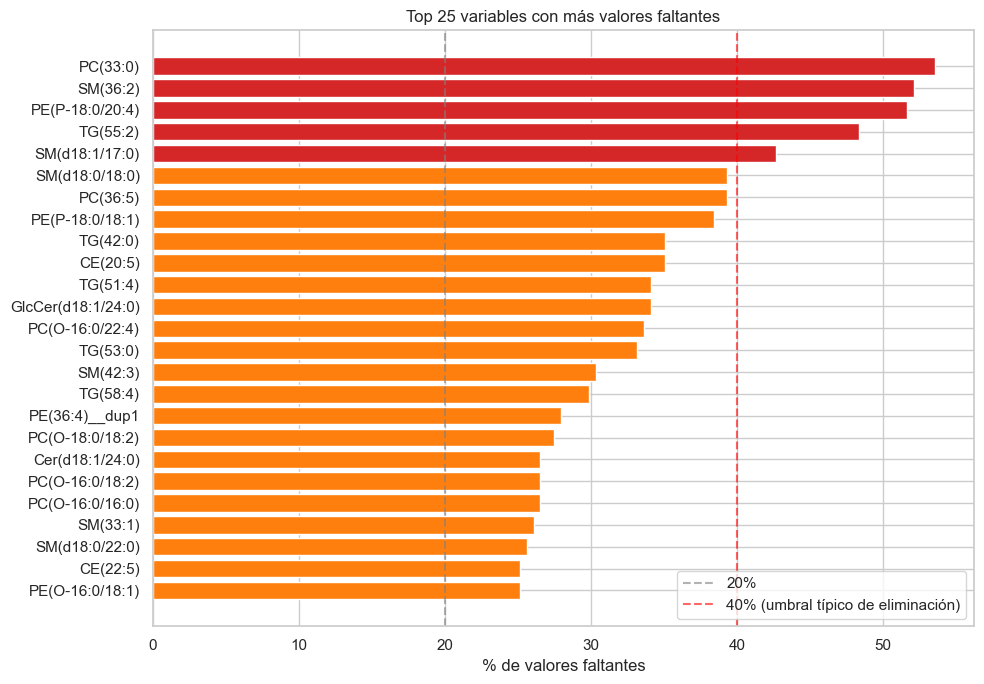

In [15]:
# 2.1.2 Visualización: barras horizontales del top 25
top_missing = missing_summary.head(25).sort_values('missing_percent')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d62728' if p > 40 else '#ff7f0e' if p > 20 else '#1f77b4'
 for p in top_missing['missing_percent']]
ax.barh(top_missing['variable'], top_missing['missing_percent'], color=colors)
ax.axvline(20, color='gray', linestyle='--', alpha=0.6, label='20%')
ax.axvline(40, color='red', linestyle='--', alpha=0.6, label='40% (umbral típico de eliminación)')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Top 25 variables con más valores faltantes')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Lectura del resultado:**

- Las **cinco barras rojas** identifican las variables con más del 40% de faltantes: `PC(33:0)` (~54%), `SM(36:2)` (~52%), `PE(P-18:0/20:4)` (~52%), `TG(55:2)` (~48%) y `SM(d18:1/17:0)` (~43%).
- A continuación se aprecia un conjunto de **barras anaranjadas** que cubren el rango 25–40%, correspondiente a aproximadamente 20 lípidos que se retendrán para análisis bajo un protocolo de imputación cuidadoso. Entre estos figuran `SM(d18:0/18:0)`, `PC(36:5)`, `PE(P-18:0/18:1)`, `CE(20:5)`, `TG(42:0)`, `TG(51:4)`, `GlcCer(d18:1/24:0)`, entre otros.
- La distribución del top 25 desciende de forma gradual sin saltos pronunciados, indicando un gradiente continuo de severidad de faltantes.
- Las líneas punteadas (20% y 40%) explicitan los umbrales que sustentan la decisión de eliminación.


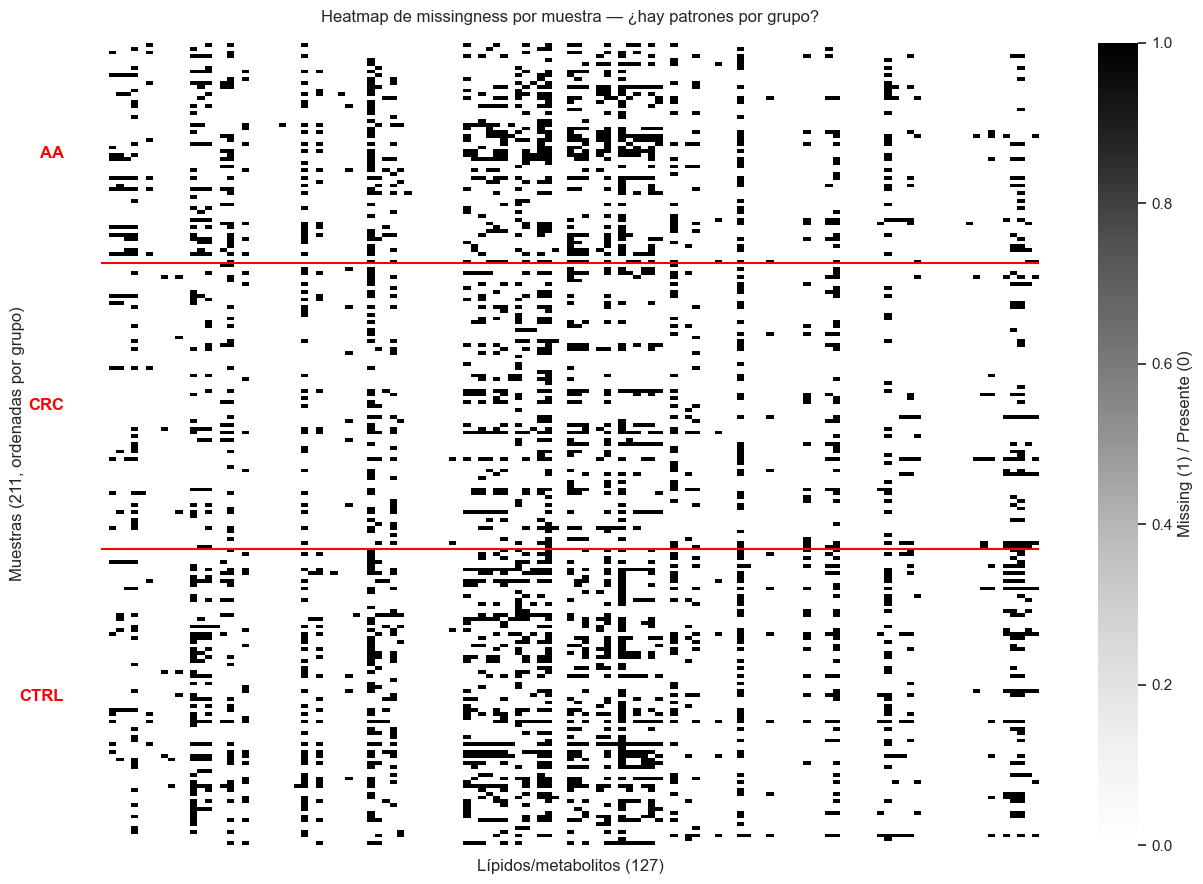

In [16]:
# 2.1.3 Heatmap de missingness ordenado por grupo
# Pregunta clave: ¿se ven patrones de ausencia compartidos entre muestras de un mismo grupo?
# Convencion: filas = muestras (observaciones), columnas = lipidos (variables) — replica
# la estructura natural del DataFrame y facilita la lectura por muestra.
from matplotlib.transforms import blended_transform_factory

data_sorted = data.sort_values('group').reset_index(drop=True)
group_labels_sorted = data_sorted['group'].values

# Solo lípidos para que el heatmap sea legible (las clínicas no tienen NaN)
miss_matrix = data_sorted[lipid_cols].isna().astype(int)
n_samples = miss_matrix.shape[0]
n_lipids = miss_matrix.shape[1]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(miss_matrix, cmap='Greys', cbar_kws={'label': 'Missing (1) / Presente (0)'},
            xticklabels=False, yticklabels=False, ax=ax)

# Identificar limites de cada grupo (en coordenadas Y del heatmap)
group_changes = [0]
prev = group_labels_sorted[0]
for idx, g in enumerate(group_labels_sorted):
    if g != prev:
        group_changes.append(idx)
        prev = g
group_changes.append(len(group_labels_sorted))

# Lineas horizontales para separar grupos (las muestras ahora estan en Y)
for idx in group_changes[1:-1]:
    ax.axhline(idx, color='red', linewidth=1.5)

# Etiquetas de grupo a la izquierda del heatmap, fuera del area de plot
# transAxes para X (independiente del ancho en celdas), transData para Y (centra en bloque)
trans = blended_transform_factory(ax.transAxes, ax.transData)
for i in range(len(group_changes) - 1):
    start = group_changes[i]
    end = group_changes[i + 1]
    center_y = (start + end) / 2
    label = group_labels_sorted[start]
    ax.text(-0.04, center_y, label, transform=trans, ha='right', va='center',
            fontsize=12, fontweight='bold', color='red')

ax.set_xlabel('Lípidos/metabolitos (127)', labelpad=10)
ax.set_ylabel('Muestras (211, ordenadas por grupo)', labelpad=55)
ax.set_title('Heatmap de missingness por muestra — ¿hay patrones por grupo?', pad=15)
plt.tight_layout()
plt.show()


**Lectura del resultado:**

- **Convención de los ejes:** filas = muestras (eje Y), columnas = lípidos (eje X). Esta orientación replica la estructura natural del DataFrame y resulta más intuitiva por tres razones:
  1. **Coincide con la lectura tabular estándar** — al pensar "esta fila es este paciente, esta columna es este lípido" se reproduce el modelo mental que se tiene de un DataFrame de pandas.
  2. **Una muestra individual con perfil incompleto aparece como una banda horizontal** (línea a lo ancho de toda la fila), lo cual coincide con la unidad biológica natural ("este paciente tiene muchos faltantes").
  3. **Los lípidos crónicamente ausentes aparecen como bandas verticales** (columnas oscuras), facilitando identificarlos como variables problemáticas más que como puntos dispersos.
- El orden visualizado de los grupos en el eje Y es **AA — CRC — CTRL** (ordenamiento alfabético, de arriba hacia abajo).
- Se observan **bandas verticales oscuras** consistentes a lo largo de todas las muestras, correspondientes a los lípidos crónicamente ausentes (`PC(33:0)`, `SM(36:2)`, `PE(P-18:0/20:4)`, entre otros).
- **Comparación visual entre franjas horizontales:** el grupo **CRC** (franja central) presenta visiblemente **menos píxeles negros** que AA (arriba) y CTRL (abajo). Tanto AA como CTRL muestran densidades de faltantes similares y mayores.
- Esta observación es consistente con el resultado del test χ²: en lípidos como `SM(36:2)`, los faltantes se concentran predominantemente en CTRL (53) y AA (35) frente a CRC (22).
- **Interpretación biológica:** la menor cantidad de faltantes en CRC sugiere que las concentraciones de los lípidos afectados se encuentran por encima del límite de detección en CRC (consistente con incrementos sistemáticos de CEs y SMs en cáncer), mientras que en AA y CTRL estas concentraciones se ubican con mayor frecuencia por debajo del LOD.
- Se identifican adicionalmente algunas **bandas horizontales aisladas** dentro de cada franja, correspondientes a observaciones individuales (pacientes) con perfil más incompleto que el resto de su grupo.


In [17]:
# 2.1.4 Test chi-cuadrado: ¿la ausencia depende del grupo?
from scipy.stats import chi2_contingency

chi2_results = []
for col in lipid_cols:
    pct = data[col].isna().mean() * 100
    if pct < 5:
        continue
    contingency = pd.crosstab(data['group'], data[col].isna())
    if contingency.shape[1] < 2:
        continue
    chi2_stat, p, dof, expected = chi2_contingency(contingency)
    chi2_results.append({
        'variable': col,
        'missing_pct': round(pct, 2),
        'missing_CTRL': contingency.loc['CTRL', True] if True in contingency.columns else 0,
        'missing_AA':   contingency.loc['AA', True] if True in contingency.columns else 0,
        'missing_CRC':  contingency.loc['CRC', True] if True in contingency.columns else 0,
        'chi2': round(chi2_stat, 2),
        'p_value': p
    })

chi2_results = pd.DataFrame(chi2_results).sort_values('p_value')
chi2_results['significant_005'] = chi2_results['p_value'] < 0.05

n_sig = chi2_results['significant_005'].sum()
print(f'Variables con missingness dependiente del grupo (p<0.05): {n_sig} de {len(chi2_results)}')
print('\nTop 15 variables con dependencia más fuerte:')
display(chi2_results.head(15))


Variables con missingness dependiente del grupo (p<0.05): 13 de 56

Top 15 variables con dependencia más fuerte:


,variable,missing_pct,missing_CTRL,missing_AA,missing_CRC,chi2,p_value,significant_005
34,SM(36:2),52.13,53,35,22,25.01,0.000004,True
5,CE(20:5),35.07,41,19,14,19.48,0.000059,True
2,Cer(d18:1/23:0),7.11,3,10,2,12.52,0.001915,True
38,SM(42:3),30.33,29,23,12,11.41,0.003335,True
12,PC(38:5),18.96,22,12,6,10.32,0.005752,True
32,SM(d18:2/16:0),15.64,16,13,4,9.46,0.008830,True
25,PE(O-16:0/18:1),25.12,25,18,10,8.61,0.013497,True
6,CE(22:4),16.59,16,14,5,8.59,0.013613,True
10,PC(32:1),15.17,18,9,5,8.01,0.018217,True
18,PC(O-16:0/16:0),26.54,28,16,12,7.81,0.020149,True


**Lectura del resultado:**

- **13 de 56 lípidos** evaluados (aquellos con más del 5% de faltantes) muestran un patrón de ausencia significativamente dependiente del grupo (p < 0.05). Bajo la hipótesis nula de independencia, se esperarían aproximadamente 3 falsos positivos por azar; la observación de 13 hits excede claramente esta expectativa.
- El caso más pronunciado corresponde a **`SM(36:2)`**, con **53 faltantes en CTRL frente a 22 en CRC** — más del doble de ausencias en el grupo sano. Una dirección análoga se observa en `CE(20:5)` (41 frente a 14).
- Un caso particularmente interesante es `Cer(d18:1/23:0)`: presenta solo 7.1% de faltantes globales, pero su distribución se concentra en AA (10) frente a CTRL (3) y CRC (2), lo que sugiere comportamiento específico de la etapa intermedia.
- **Conclusión:** el mecanismo de ausencia se clasifica como **MAR o MNAR**, no MCAR. La ausencia transporta información biológica (presumiblemente concentraciones por debajo del límite de detección, más frecuentes en sanos para ciertos lípidos elevados en cáncer).


### Síntesis interpretativa y decisión metodológica

**Hallazgos sintetizados:**

- 27 lípidos presentan más del 20% de faltantes; 5 superan el 40% (`PC(33:0)` 53.5%, `SM(36:2)` 52.1%, `PE(P-18:0/20:4)` 51.7%, `TG(55:2)` 48.3%, `SM(d18:1/17:0)` 42.7%).
- El mapa de calor revela tanto bandas horizontales (lípidos crónicamente ausentes) como verticales (observaciones con perfil incompleto), con mayor densidad de faltantes en la franja CTRL.
- El test χ² confirma cuantitativamente la dependencia: 13 de 56 lípidos exhiben missingness significativamente asociado al grupo (p < 0.05). El caso `SM(36:2)` ilustra el patrón: 53 faltantes en CTRL frente a 22 en CRC.

**Caracterización formal del mecanismo:** el missingness no se ajusta al supuesto de MCAR (Missing Completely At Random). Corresponde a **MAR/MNAR**, en tanto refleja que ciertos lípidos se encuentran por debajo del límite de detección con mayor frecuencia en CTRL que en CRC — fenómeno biológicamente interpretable y no atribuible a azar.

**Decisiones metodológicas:**

1. **Eliminación de variables con más del 40% de faltantes** (n = 5), umbral consistente con la metodología del estudio original.
2. **Imputación mediante mediana por grupo**, en lugar de mediana global. Esta elección preserva la señal biológica diferencial entre grupos. El estudio original emplea MICE (Multiple Imputation by Chained Equations) como alternativa más robusta; para el alcance exploratorio del presente documento, la imputación por grupo se considera suficiente.
3. **Generación opcional de variables indicadoras `is_missing_X`** para los 13 lípidos con dependencia significativa del grupo, dado que la ausencia misma podría poseer valor predictivo.


## 2.2 Detección de duplicados

### Fundamentación

Un conjunto de datos clínicos correctamente curado no debería contener observaciones duplicadas. Su presencia podría obedecer a errores de captura, fusión defectuosa de archivos o procesamiento accidental de muestras en múltiples ocasiones.

Se evalúan dos formas de duplicación:

1. **Filas idénticas** en la totalidad de columnas (duplicado completo).
2. **Identificadores de muestra repetidos** (mismo paciente con datos distintos — escenario menos frecuente pero posible).


In [18]:
# 2.2.1 Filas completamente duplicadas
n_dup_rows = data.duplicated().sum()
print(f'Filas completamente duplicadas: {n_dup_rows}')

if 'sample' in data.columns:
    n_unique = data['sample'].nunique()
    n_dup = data['sample'].duplicated().sum()
    print(f'sample: {n_unique} únicos, {n_dup} duplicados')
    if n_dup > 0:
        display(data[data['sample'].duplicated(keep=False)][['sample', 'group']])


Filas completamente duplicadas: 0
sample: 211 únicos, 0 duplicados


## 2.3 Cardinalidad de variables categóricas

### Fundamentación

Se verifica que las variables categóricas presenten los niveles esperados, sin errores de captura tales como inconsistencias en mayúsculas/minúsculas, espacios remanentes o valores anómalos.


In [19]:
# 2.3 Cardinalidad y distribución de categóricas
cardinality_summary = []
for col in ['group', 'gender', 'fob']:
    counts = data[col].value_counts(dropna=False)
    n_unique = data[col].nunique(dropna=True)
    n_missing = data[col].isna().sum()
    cardinality_summary.append({
        'variable': col,
        'n_unique': n_unique,
        'n_missing': n_missing,
        'levels': dict(counts)
    })

for entry in cardinality_summary:
    print(f"\n{entry['variable']}: {entry['n_unique']} niveles, {entry['n_missing']} NaN")
    for level, count in entry['levels'].items():
        pct = count / len(data) * 100
        print(f'  {level}: {count} ({pct:.1f}%)')



group: 3 niveles, 0 NaN
  CTRL: 78 (37.0%)
  CRC: 75 (35.5%)
  AA: 58 (27.5%)

gender: 2 niveles, 0 NaN
  Male: 130 (61.6%)
  Female: 81 (38.4%)

fob: 2 niveles, 0 NaN
  YES: 125 (59.2%)
  NO: 86 (40.8%)


**Lectura del resultado:**

- **`group`:** tres niveles consistentes sin valores faltantes. Distribución: CTRL 37.0%, CRC 35.5%, AA 27.5%. El desbalance es leve (ratio máx/mín ≈ 1.34), manejable mediante `class_weight='balanced'` en la fase de modelado.
- **`gender`:** dos niveles (Male/Female), sin faltantes. Se observa predominancia masculina (61.6% Male, 38.4% Female).
- **`fob`:** dos niveles (YES/NO), sin faltantes. La mayoría de la cohorte (59.2%) presenta FOB positivo, lo cual resulta esperable dado que el reclutamiento del estudio incluye pacientes derivados a colonoscopía por sospecha clínica.
- **Ausencia de errores de captura:** los nombres son consistentes (no se observan formas mixtas tipo "ctrl"/"CTRL" ni "Y"/"yes"/"YES"), lo que descarta la necesidad de normalización adicional.


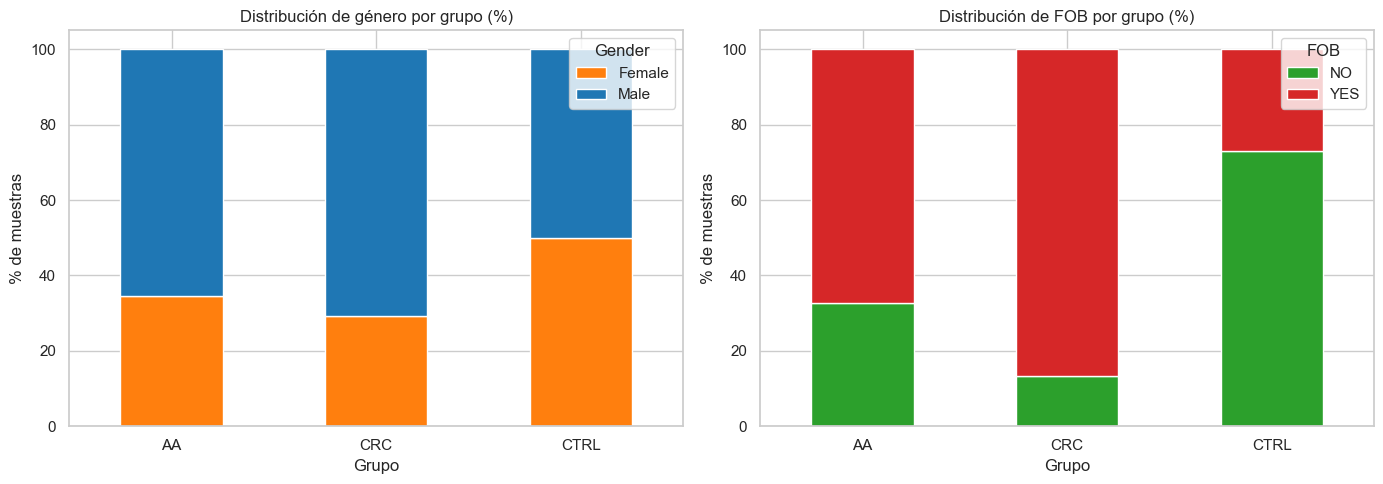


Tabla cruda gender × group:
group   AA  CRC  CTRL
gender               
Female  20   22    39
Male    38   53    39

Tabla cruda fob × group:
group  AA  CRC  CTRL
fob                 
NO     19   10    57
YES    39   65    21


In [20]:
# 2.3.2 Visualización: distribución conjunta de categóricas con el target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender × group
ct_gender = pd.crosstab(data['gender'], data['group'])
ct_gender_pct = ct_gender.div(ct_gender.sum(axis=0), axis=1) * 100
ct_gender_pct.T.plot(kind='bar', stacked=True, ax=axes[0],
 color=['#ff7f0e', '#1f77b4'])
axes[0].set_title('Distribución de género por grupo (%)')
axes[0].set_xlabel('Grupo')
axes[0].set_ylabel('% de muestras')
axes[0].legend(title='Gender')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# FOB × group
ct_fob = pd.crosstab(data['fob'], data['group'])
ct_fob_pct = ct_fob.div(ct_fob.sum(axis=0), axis=1) * 100
ct_fob_pct.T.plot(kind='bar', stacked=True, ax=axes[1],
 color=['#2ca02c', '#d62728'])
axes[1].set_title('Distribución de FOB por grupo (%)')
axes[1].set_xlabel('Grupo')
axes[1].set_ylabel('% de muestras')
axes[1].legend(title='FOB')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Mostrar tablas crudas para apoyar la lectura
print('\nTabla cruda gender × group:')
print(ct_gender)
print('\nTabla cruda fob × group:')
print(ct_fob)


**Lectura del resultado:**

- **Gender × group (panel izquierdo):** la proporción Male/Female se mantiene relativamente similar entre grupos, aunque **CRC presenta la mayor concentración de Males (~71%)** frente a CTRL (~50%) y AA (~66%). Este sesgo merece consideración: si el modelo aprende a discriminar por género, parte de la "señal de CRC" podría representar un confounding por desbalance demográfico.
- **FOB × group (panel derecho):** se evidencia un gradiente pronunciado. **FOB+ se distribuye en ~87% de CRC, ~67% de AA y ~27% de CTRL.** Este gradiente refleja directamente la naturaleza biológica de la prueba: detección de hemoglobina en heces, frecuente en CRC por sangrado tumoral.
- Las **tablas de contingencia** confirman los conteos (CTRL: 21 YES vs 57 NO; CRC: 65 YES vs 10 NO; AA: 39 YES vs 19 NO).
- **Implicación metodológica:** FOB constituye un predictor casi determinístico de CRC en este conjunto de datos. Cualquier modelo que lo incluya lo aprenderá como predictor principal; resulta indispensable entrenar configuraciones con y sin FOB para distinguir el aporte real de los biomarcadores lipidómicos.


---

## Resumen del Paso 2 — Calidad de datos

| Aspecto | Hallazgo en este dataset | Decisión tomada |
|---|---|---|
| Faltantes globales | 56/132 vars sin NaN; 27 lípidos con >20%; 5 con >40% | Eliminar las 5 variables con >40% faltantes |
| Patrón de missingness | 13/56 lípidos testeados muestran dependencia significativa con el grupo (χ², p<0.05). Patrón consistente: más NaN en CTRL que en CRC | Missingness es **MAR/MNAR**, no MCAR. Imputar con **mediana por grupo**, no global |
| Duplicados | 0 filas duplicadas, 211 IDs únicos | Sin acción necesaria |
| Cardinalidad | `group`: 3 niveles limpios (CTRL 37%, CRC 35.5%, AA 27.5%), `gender`: 2 (Male 62%, Female 38%), `fob`: 2 (YES 59%, NO 41%) | Sin acción necesaria |
| Asociación FOB × group | Gradiente fuerte: FOB+ está en 87% de CRC, 67% de AA y 27% de CTRL | Esperado biológicamente — FOB es predictor clínico estándar |
| Asociación gender × group | Más Males en todos los grupos, especialmente en CRC (71% Male) | Considerar como posible covariable |

### Implicaciones para los siguientes pasos

- **Para Paso 3 (distribuciones)**: trabajar solo con los 122 lípidos retenidos (127 - 5 eliminados) + `age` + `fit_ug_g`.
- **Para imputación**: usar `data.groupby('group').transform(lambda x: x.fillna(x.median()))` cuando llegue el momento.
- **Para modelado** (fuera del alcance de esta libreta): el desbalance entre clases es leve (1.34) → `class_weight='balanced'` es suficiente, no necesitamos oversampling.

> **Próximo paso:** Análisis de distribuciones, evaluación de transformaciones y detección de outliers.


# Paso 3 — Distribuciones, transformaciones y detección de valores atípicos

Una vez verificada la calidad del conjunto de datos, el presente módulo aborda las siguientes interrogantes:

1. ¿Cómo se distribuyen las variables clínicas y los lípidos? ¿Son normales, sesgadas o multimodales?
2. ¿Resulta necesario aplicar una transformación? Se comparan formalmente cuatro alternativas: `raw`, `log1p`, `Yeo-Johnson` y `Box-Cox`.
3. ¿Cómo deben tratarse los valores atípicos una vez transformados los datos?
4. ¿Cuál es la apariencia visual de las distribuciones por familia y por grupo tras el preprocesamiento?

> Las decisiones tomadas en este módulo (transformación, manejo de atípicos) **condicionan la totalidad de los análisis posteriores**: la selección supervisada de variables del Paso 4, el análisis multivariado del Paso 5 y, en última instancia, el modelado predictivo del Avance 2.


## 3.1 Distribuciones de variables clínicas

Se examinan `age` y `fit_ug_g` por grupo mediante histogramas (caracterización de forma) y diagramas de caja (mediana, cuartiles, atípicos). Estas dos variables corresponden al conjunto retenido del bloque clínico tras la eliminación de las versiones estandarizadas en el Paso 2.


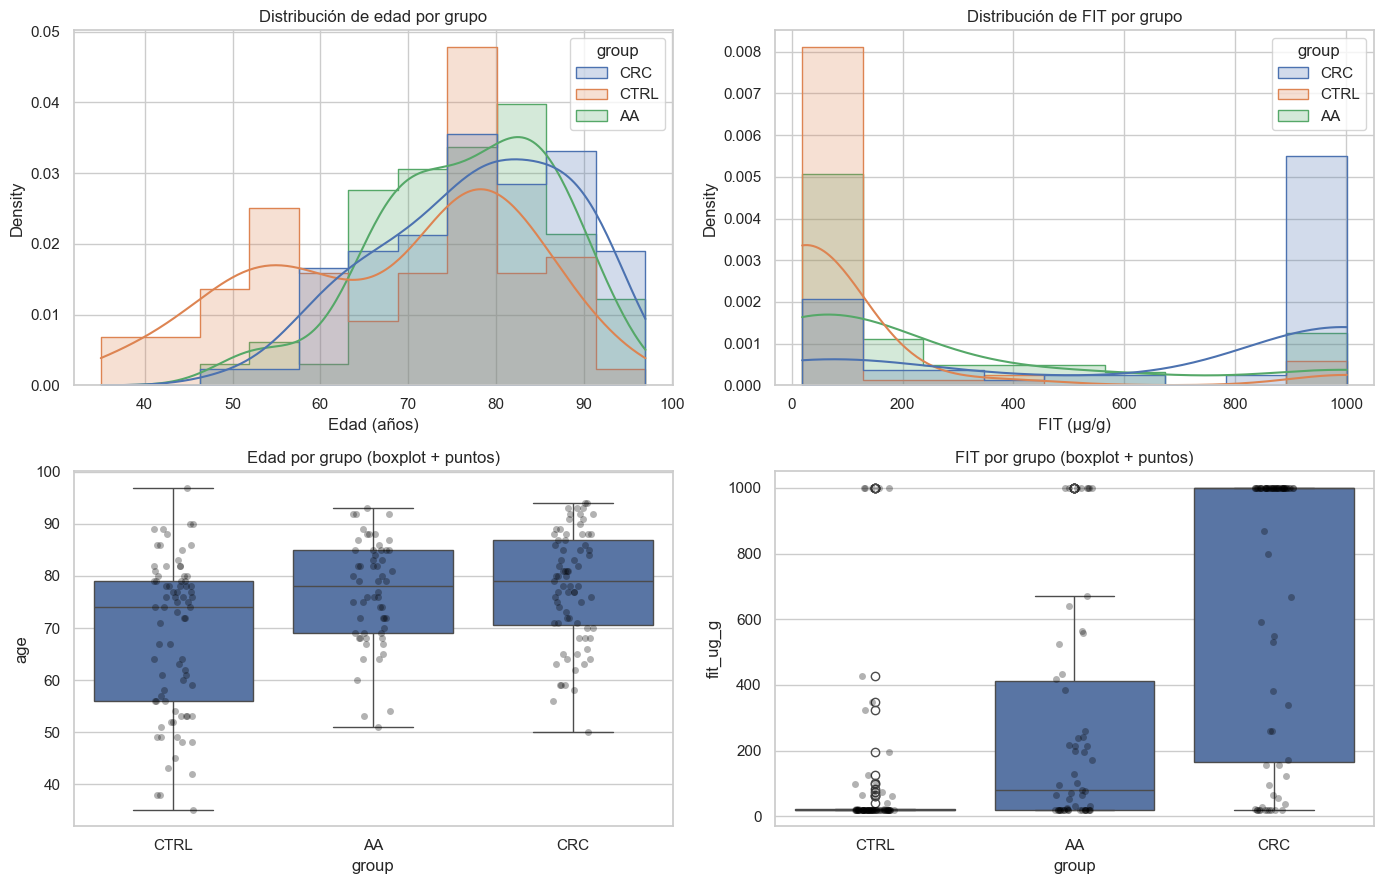

In [21]:
# 3.1.1 Histogramas y boxplots de variables clínicas por grupo
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Histogramas
sns.histplot(data=data, x='age', hue='group', kde=True, element='step',
 stat='density', common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de edad por grupo')
axes[0, 0].set_xlabel('Edad (años)')

sns.histplot(data=data, x='fit_ug_g', hue='group', kde=True, element='step',
 stat='density', common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title('Distribución de FIT por grupo')
axes[0, 1].set_xlabel('FIT (µg/g)')

# Boxplots
sns.boxplot(data=data, x='group', y='age', ax=axes[1, 0],
 order=['CTRL', 'AA', 'CRC'])
sns.stripplot(data=data, x='group', y='age', color='black', alpha=0.3,
 ax=axes[1, 0], order=['CTRL', 'AA', 'CRC'])
axes[1, 0].set_title('Edad por grupo (boxplot + puntos)')

sns.boxplot(data=data, x='group', y='fit_ug_g', ax=axes[1, 1],
 order=['CTRL', 'AA', 'CRC'])
sns.stripplot(data=data, x='group', y='fit_ug_g', color='black', alpha=0.3,
 ax=axes[1, 1], order=['CTRL', 'AA', 'CRC'])
axes[1, 1].set_title('FIT por grupo (boxplot + puntos)')

plt.tight_layout()
plt.show()


**Lectura del resultado (panel 2×2):**

- **Edad (paneles izquierdos):** la distribución de **CTRL** (curva naranja) exhibe un patrón **bimodal**: un modo principal alrededor de 75–85 años — coincidente con la zona modal de AA y CRC — y un modo secundario menor entre 45 y 55 años, con una cola izquierda que se extiende hasta 35 años. Esto sugiere que la cohorte CTRL contiene dos sub-poblaciones: una mayoritaria de edad avanzada (presumiblemente individuos derivados a colonoscopía sin hallazgo patológico) y una minoritaria de individuos más jóvenes. **AA** (curva verde) y **CRC** (curva azul) se concentran de forma más unimodal en el rango 70–90 años. Las medianas confirman esta caracterización: CTRL ~74, AA ~78, CRC ~79 — diferencia inferior a la sugerida por las medias (68.4 / 76.7 / 77.8), las cuales son arrastradas a la baja en CTRL por su cola izquierda.
- **FIT (paneles derechos):** distribuciones extremadamente sesgadas:
  - CTRL (naranja) acumula prácticamente toda su masa en valores bajos (cerca de 19 µg/g, límite inferior del instrumento).
  - AA (verde) presenta dispersión intermedia con cola hacia valores altos.
  - **CRC (azul) muestra una bimodalidad evidente**: una pequeña masa en valores bajos (probablemente pacientes con CRC de bajo sangrado) y una masa pronunciada en el extremo superior (1001 µg/g, saturación del instrumento).
- Los boxplots evidencian la mediana CRC pegada al límite superior (1001), AA con mediana ~79 y cajas extensas, y CTRL con caja muy comprimida en valores bajos.
- **Implicaciones:**
  - **Edad:** el confounder por edad es más matizado de lo sugerido por las medias. El modo principal de CTRL coincide etariamente con AA/CRC; la diferencia se concentra en una sub-cohorte joven minoritaria. Conviene tener en cuenta esta bimodalidad al evaluar modelos predictivos — un análisis estratificado por sub-grupos etarios podría revelar diferencias que el promedio oculta.
  - **FIT:** exhibe poder discriminativo extremo, particularmente entre CTRL y CRC. La bimodalidad de CRC refleja heterogeneidad biológica intra-grupo (algunos tumores sangran intensamente, otros menos).


In [22]:
# 3.1.2 Estadísticas descriptivas por grupo
print('=== Edad por grupo ===')
display(data.groupby('group')['age'].agg(['count', 'mean', 'std', 'median', 'min', 'max']).round(2))

print('\n=== FIT (µg/g) por grupo ===')
display(data.groupby('group')['fit_ug_g'].agg(['count', 'mean', 'std', 'median', 'min', 'max']).round(2))


=== Edad por grupo ===


,count,mean,std,median,min,max
group,,,,,,
AA,58,76.69,10.04,78.0,51,93
CRC,75,77.81,10.81,79.0,50,94
CTRL,78,68.40,14.94,74.0,35,97



=== FIT (µg/g) por grupo ===


,count,mean,std,median,min,max
group,,,,,,
AA,58,265.14,343.26,79.0,19,1001
CRC,75,685.35,421.57,1001.0,19,1001
CTRL,78,104.71,246.67,19.0,19,1001


**Lectura del resultado:**

- **Edad por grupo:**
  - CTRL: 68.4 ± 14.9 años (mediana 74).
  - AA: 76.7 ± 10.0 (mediana 78).
  - CRC: 77.8 ± 10.8 (mediana 79).
  - Diferencia de aproximadamente 10 años entre CTRL y AA/CRC — confirmación cuantitativa del confounder demográfico anticipado.
- **FIT por grupo:**
  - CTRL: media 104.7, mediana 19 (75% de los pacientes en el límite inferior).
  - AA: media 265.1, mediana 79.
  - CRC: media 685.3, mediana 1001 (más del 50% saturado).
  - El gradiente CTRL → AA → CRC resulta monotónico tanto en media como en mediana.
- Estos valores coinciden de forma estricta con la Tabla 1 del estudio Albóniga et al. (2025).


## 3.2 Distribuciones de los lípidos: análisis de asimetría

Dado que el conjunto comprende **127 lípidos**, resulta inviable producir un histograma por cada uno. En su lugar:

1. Se calcula la **asimetría (skewness)** de cada lípido sobre los datos crudos.
2. Se examina la **distribución de la propia asimetría** — una única gráfica resume el problema agregado.
3. Se identifican las variables más y menos sesgadas para disponer de ejemplos concretos.

**Referencia para interpretación:** `|skew| < 0.5` aproximadamente simétrica; `0.5–1` moderada; `1–2` fuerte; `> 2` muy fuerte.


In [23]:
# 3.2.1 Calcular skewness de cada lípido (datos crudos)
from scipy.stats import skew, kurtosis

skew_records = []
for col in lipid_cols:
    vals = data[col].dropna()
    if len(vals) >= 10:
        skew_records.append({
            'variable': col,
            'n': len(vals),
            'mean': vals.mean(),
            'median': vals.median(),
            'skew': skew(vals),
            'kurtosis': kurtosis(vals)
        })

skew_df = pd.DataFrame(skew_records).sort_values('skew', ascending=False).reset_index(drop=True)

abs_skew = skew_df['skew'].abs()
print(f'Total lípidos analizados: {len(skew_df)}')
print(f'\nDistribución de |skewness|:')
print(f'  |skew| < 0.5 (simétrico):       {(abs_skew < 0.5).sum()}')
print(f'  0.5 <= |skew| < 1 (moderado):   {((abs_skew >= 0.5) & (abs_skew < 1)).sum()}')
print(f'  1 <= |skew| < 2 (fuerte):       {((abs_skew >= 1) & (abs_skew < 2)).sum()}')
print(f'  |skew| >= 2 (muy fuerte):       {(abs_skew >= 2).sum()}')

print(f'\nSkewness - media: {skew_df["skew"].mean():.2f} | mediana: {skew_df["skew"].median():.2f}')


Total lípidos analizados: 127

Distribución de |skewness|:
  |skew| < 0.5 (simétrico):       0
  0.5 <= |skew| < 1 (moderado):   0
  1 <= |skew| < 2 (fuerte):       0
  |skew| >= 2 (muy fuerte):       127

Skewness - media: 5.82 | mediana: 5.47


**Lectura del resultado:**

- **127 de 127 lípidos** se clasifican en la categoría `|skew| ≥ 2` (asimetría muy fuerte). No se identifica un solo lípido aproximadamente normal en datos crudos.
- La mediana de skewness asciende a 5.47 y la media a 5.82, lo cual indica una asimetría positiva pronunciada (cola larga a la derecha).
- Este resultado confirma cuantitativamente el patrón visual previamente observado en FIT y resulta consistente con la naturaleza log-normal típica de las concentraciones en estudios lipidómicos.
- **Implicación:** justifica metodológicamente la necesidad de transformar los datos antes de cualquier análisis paramétrico, PCA o estadística inferencial basada en supuestos de normalidad.


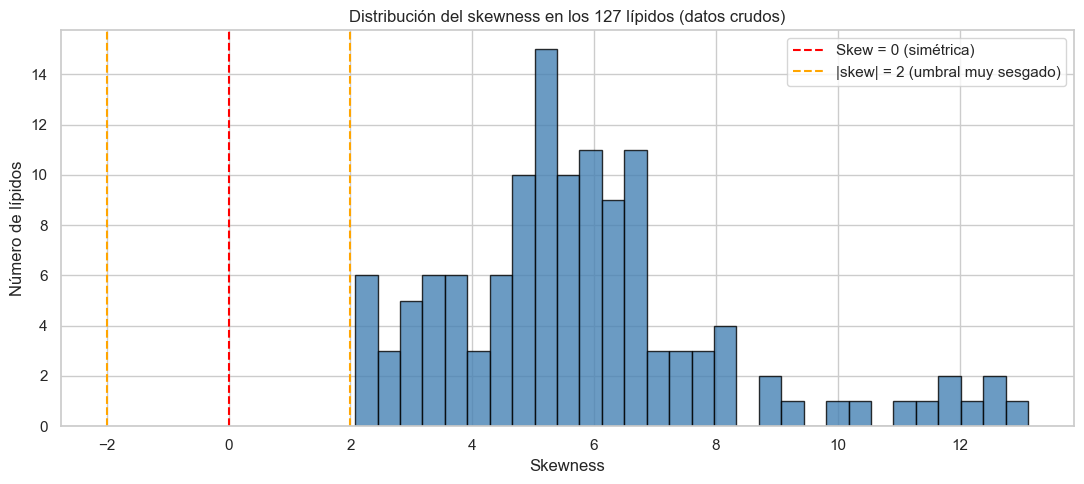

In [24]:
# 3.2.2 Visualización: histograma del skewness
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(skew_df['skew'], bins=30, edgecolor='black', color='steelblue', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', label='Skew = 0 (simétrica)')
ax.axvline(2, color='orange', linestyle='--', label='|skew| = 2 (umbral muy sesgado)')
ax.axvline(-2, color='orange', linestyle='--')
ax.set_xlabel('Skewness')
ax.set_ylabel('Número de lípidos')
ax.set_title('Distribución del skewness en los 127 lípidos (datos crudos)')
ax.legend()
plt.tight_layout()
plt.show()


**Lectura del resultado:**

- La distribución del propio skewness se concentra en el rango 2–8, con un máximo modal alrededor de 5 (15 lípidos en ese intervalo) y una cola pronunciada hacia valores muy altos (hasta ~13).
- **Ningún lípido se ubica por debajo de la línea roja** (skew = 0, simétrica); la totalidad se encuentra a la derecha de la línea naranja punteada (\|skew\| = 2).
- La forma del histograma evidencia la existencia de un grupo "núcleo" de lípidos con skewness 4–7 (mayoría), un cúmulo secundario de casos moderados (skewness 2–4) y una cola larga de casos extremos con skewness superior a 8 (presumiblemente los TGs y DGs identificados en el ranking 3.2.3).


In [25]:
# 3.2.3 Top 10 lípidos más y menos sesgados
print('=== Top 10 más sesgados (cola larga a la derecha) ===')
display(skew_df.head(10))

print('\n=== Top 10 menos sesgados ===')
display(skew_df.tail(10).iloc[::-1])


=== Top 10 más sesgados (cola larga a la derecha) ===


,variable,n,mean,median,skew,kurtosis
0,DG(34:0),211,0.772017,0.520619,13.123653,180.336812
1,TG(49:1),211,0.050337,0.026284,12.686474,171.712873
2,TG(47:1),202,0.098684,0.058835,12.412208,163.784368
3,TG(47:0),211,0.246131,0.152654,12.285099,164.811069
4,TG(46:3),179,0.304460,0.108368,12.008437,149.903560
5,TG(49:0),211,0.186894,0.104190,11.991302,159.593212
6,PC(38:5),171,0.001720,0.000497,11.330151,136.154933
7,TG(40:0),211,21.899837,1.960829,11.188783,134.547169
8,TG(46:2),190,0.157428,0.034163,10.398532,118.180232
9,PE(36:3),180,0.121787,0.068694,9.918333,113.871754



=== Top 10 menos sesgados ===


,variable,n,mean,median,skew,kurtosis
126,PE(34:1),210,0.917659,0.631388,2.077537,6.431955
125,PE(36:4),197,0.060164,0.037612,2.091193,4.902698
124,Cholesterol sulfate,211,12.888961,9.534502,2.220243,5.898861
123,PE(34:2),211,0.866133,0.563203,2.230891,6.269893
122,PC(33:0),98,0.249841,0.130270,2.294041,6.049576
121,PC(30:0),210,0.051790,0.038508,2.422133,7.239221
120,SM(d18:0/22:0),157,0.026491,0.015108,2.466716,7.288954
119,CE(22:6),210,0.040634,0.017773,2.575242,7.256819
118,GlcCer(d18:1/24:0),139,0.056095,0.031384,2.652743,7.444828
117,CE(22:4),176,0.157844,0.097861,2.847060,10.643300


**Lectura del resultado:**

- **Lípidos más sesgados** (skew > 10): mayoritariamente **triglicéridos (TG)** y un **diglicérido (DG(34:0))**, con `PC(38:5)` y `PE(36:3)` como casos adicionales que también superan el umbral. El comportamiento extremo de TGs/DGs resulta consistente con su alta variabilidad entre pacientes (acumulación lipídica intracelular), generadora de colas extremas.
- **Lípidos menos sesgados** (skew ~2–2.7): combinación de **PEs (fosfatidiletanolaminas)**, **CEs** y **Cer**. No obstante, se mantienen por encima del umbral de "muy sesgado".
- **Implicación metodológica:** el problema de asimetría afecta a todas las familias, si bien los TGs y DGs constituyen el caso extremo. Una transformación universal aplicada al conjunto completo de lípidos resulta justificada.


## 3.3 Evaluación de transformaciones

En presencia de asimetría, una transformación monótona puede aproximar los datos a la normalidad. Se comparan formalmente cuatro alternativas:

| Transformación | Fórmula | Condición |
|---|---|---|
| `raw` | `x` | — (sin transformar) |
| `log1p` | `log(1 + x)` | requiere `x ≥ 0` |
| `Yeo-Johnson` | optimiza λ vía MLE | admite cualquier valor |
| `Box-Cox` | optimiza λ vía MLE | requiere `x > 0` estrictamente |

**Verificación preliminar:** ¿son los lípidos estrictamente positivos? La respuesta determina la aplicabilidad de Box-Cox.

**Evaluación visual:** mediante **diagrama Q-Q** (Quantile-Quantile plot). La proximidad de los puntos a la diagonal indica aproximación a la normalidad; desviaciones sistemáticas (forma de "S" o curvaturas) la rechazan.

**Evaluación cuantitativa:** mediante el cálculo de la **asimetría post-transformación** y la **proporción de variables que superan el test de Shapiro-Wilk** (p > 0.05).


### 3.3.1 Verificación del soporte: positividad estricta

La transformación Box-Cox requiere `x > 0` de forma estricta. Si los datos satisfacen esta condición, Box-Cox resulta aplicable; en caso contrario, debe descartarse en favor de log1p o Yeo-Johnson.


In [26]:
# Verificación de soporte positivo
neg_count = 0
zero_count = 0
strictly_pos = 0
for col in lipid_cols:
    vals = data[col].dropna().values
    if (vals < 0).any(): neg_count += 1
    if (vals == 0).any(): zero_count += 1
    if (vals > 0).all(): strictly_pos += 1

print(f'Lípidos con algún valor negativo: {neg_count}/{len(lipid_cols)}')
print(f'Lípidos con algún valor = 0:      {zero_count}/{len(lipid_cols)}')
print(f'Lípidos estrictamente positivos:  {strictly_pos}/{len(lipid_cols)}')
print(f'Mínimo absoluto entre lípidos:    {data[lipid_cols].min().min():.2e}')

if strictly_pos == len(lipid_cols):
    print('\nTodos los lípidos son estrictamente positivos. Box-Cox aplica.')
else:
    print('\nBox-Cox NO aplicable directamente. Solo log1p y Yeo-Johnson.')


Lípidos con algún valor negativo: 0/127
Lípidos con algún valor = 0:      0/127
Lípidos estrictamente positivos:  127/127
Mínimo absoluto entre lípidos:    1.80e-05

Todos los lípidos son estrictamente positivos. Box-Cox aplica.


**Lectura del resultado:**

Los 127 lípidos son **estrictamente positivos** (mínimo absoluto ~1.8 × 10⁻⁵). Por consiguiente, Box-Cox resulta directamente aplicable y debe ser comparado formalmente con Yeo-Johnson en lugar de descartarse a priori.


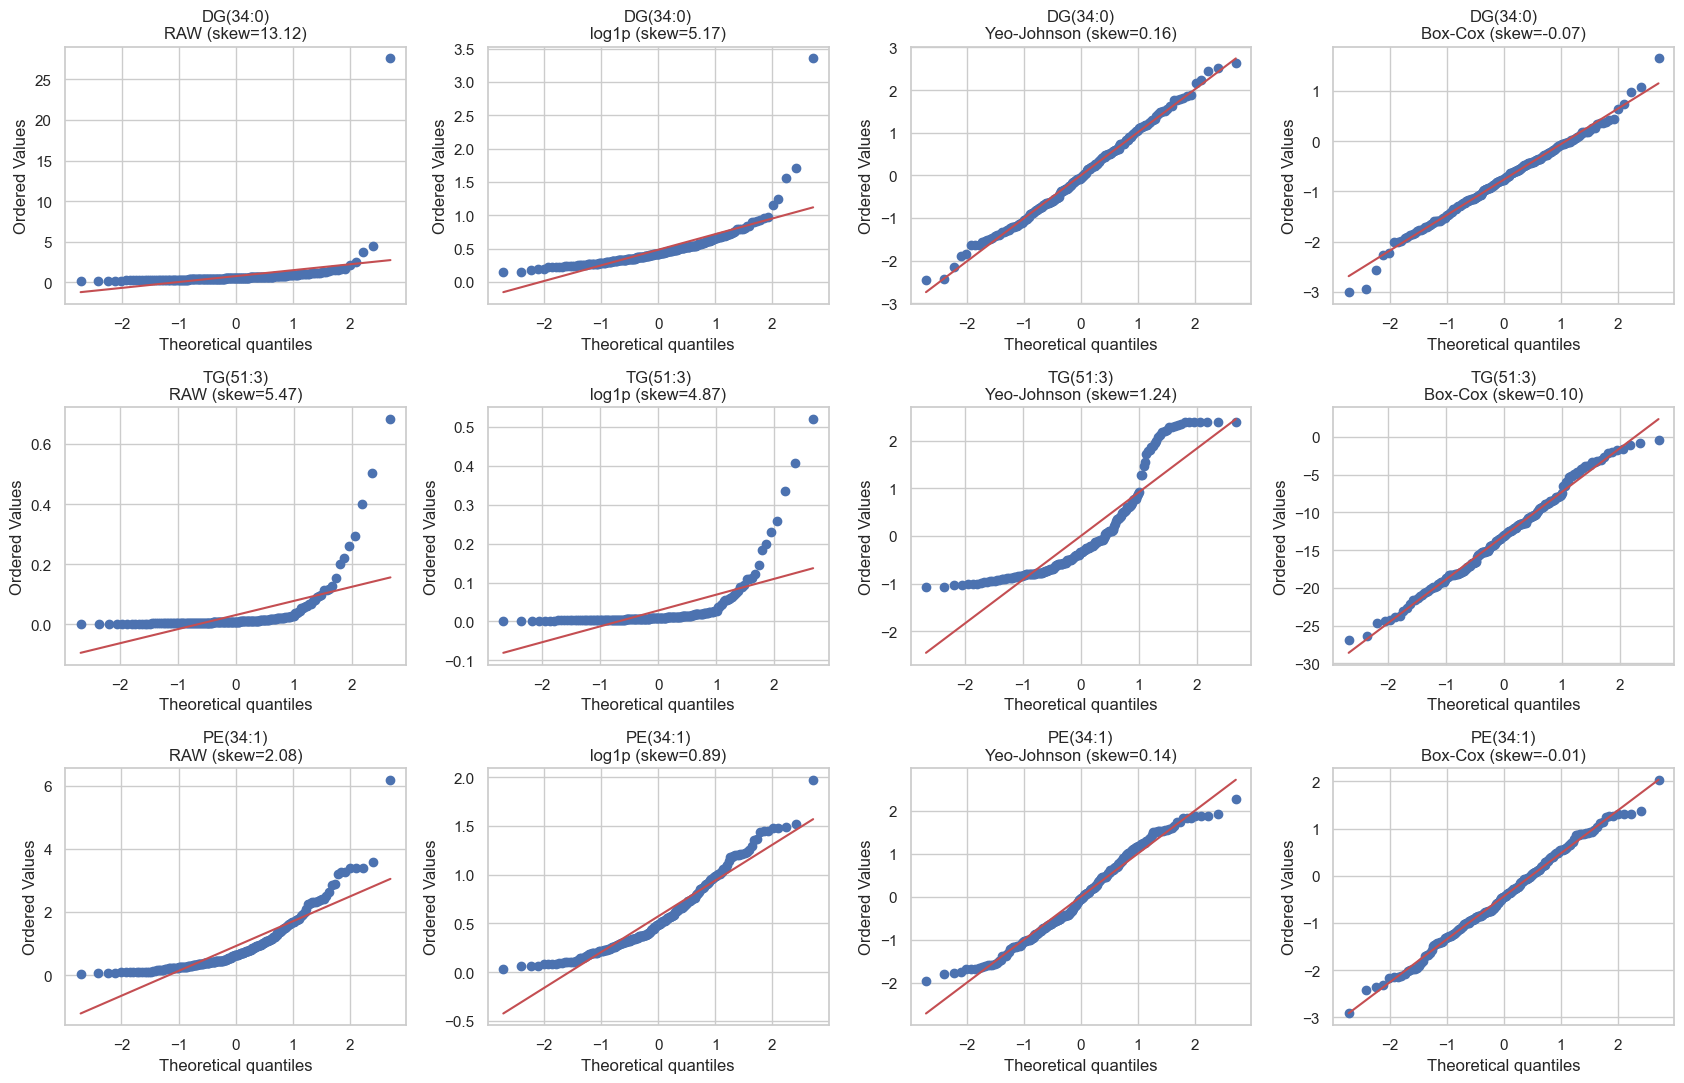

In [27]:
# 3.3.2 Comparación visual con QQ-plots para 3 lípidos representativos (4 transformaciones)
from scipy.stats import probplot, skew, boxcox
from sklearn.preprocessing import PowerTransformer

n = len(skew_df)
representative = [
    skew_df.iloc[0]['variable'],
    skew_df.iloc[n // 2]['variable'],
    skew_df.iloc[-1]['variable']
]

fig, axes = plt.subplots(3, 4, figsize=(17, 11))
yeo = PowerTransformer(method='yeo-johnson')

for i, lipid in enumerate(representative):
    vals = data[lipid].dropna()
    # RAW
    probplot(vals, dist='norm', plot=axes[i, 0])
    axes[i, 0].set_title(f'{lipid}\nRAW (skew={skew(vals):.2f})')
    # log1p
    log_vals = np.log1p(vals)
    probplot(log_vals, dist='norm', plot=axes[i, 1])
    axes[i, 1].set_title(f'{lipid}\nlog1p (skew={skew(log_vals):.2f})')
    # Yeo-Johnson
    yj_vals = yeo.fit_transform(vals.values.reshape(-1, 1)).flatten()
    probplot(yj_vals, dist='norm', plot=axes[i, 2])
    axes[i, 2].set_title(f'{lipid}\nYeo-Johnson (skew={skew(yj_vals):.2f})')
    # Box-Cox
    bc_vals, _ = boxcox(vals.values + 1e-10)
    probplot(bc_vals, dist='norm', plot=axes[i, 3])
    axes[i, 3].set_title(f'{lipid}\nBox-Cox (skew={skew(bc_vals):.2f})')

plt.tight_layout()
plt.show()


**Lectura del resultado (panel 3×4):**

Cada fila corresponde a un lípido representativo de un nivel de asimetría, seleccionado mediante `skew_df.iloc[0]`, `iloc[n//2]` e `iloc[-1]`:

| Fila | Lípido | Skew (raw) | Nivel |
|---|---|---|---|
| 1 | `DG(34:0)` | 13.12 | Asimetría máxima |
| 2 | `TG(51:3)` | 5.47 | Asimetría mediana |
| 3 | `PE(34:1)` | 2.08 | Asimetría mínima |

- **Columna RAW (izquierda):** los puntos describen una "L" pronunciada en las tres filas, con desviaciones marcadas respecto a la diagonal, particularmente en las colas superiores. La distribución se aparta claramente de la normalidad — efecto más extremo en `DG(34:0)` (skew = 13.12).
- **Columna log1p:** se observa mejora notable respecto a raw, pero persisten desviaciones sistemáticas en las colas — los datos continúan siendo sesgados, especialmente en `TG(51:3)` (skew permanece elevado tras la transformación logarítmica).
- **Columna Yeo-Johnson:** los puntos se aproximan considerablemente a la diagonal en las tres filas, con desviaciones menores únicamente en colas extremas.
- **Columna Box-Cox (derecha):** **alineamiento casi perfecto con la diagonal en los tres lípidos**. Los puntos se distribuyen prácticamente sobre la línea roja sin desviaciones sistemáticas. El skewness reportado en cada subtítulo lo corrobora numéricamente: Box-Cox lleva el sesgo prácticamente a cero (~0.07 para `DG(34:0)`, ~0.10 para `TG(51:3)`).
- Ambas transformaciones tipo potencia (Yeo-Johnson y Box-Cox) estiman una `λ` específica por variable. Box-Cox resulta superior dado que está diseñada específicamente para datos positivos, condición que se cumple en el presente conjunto.


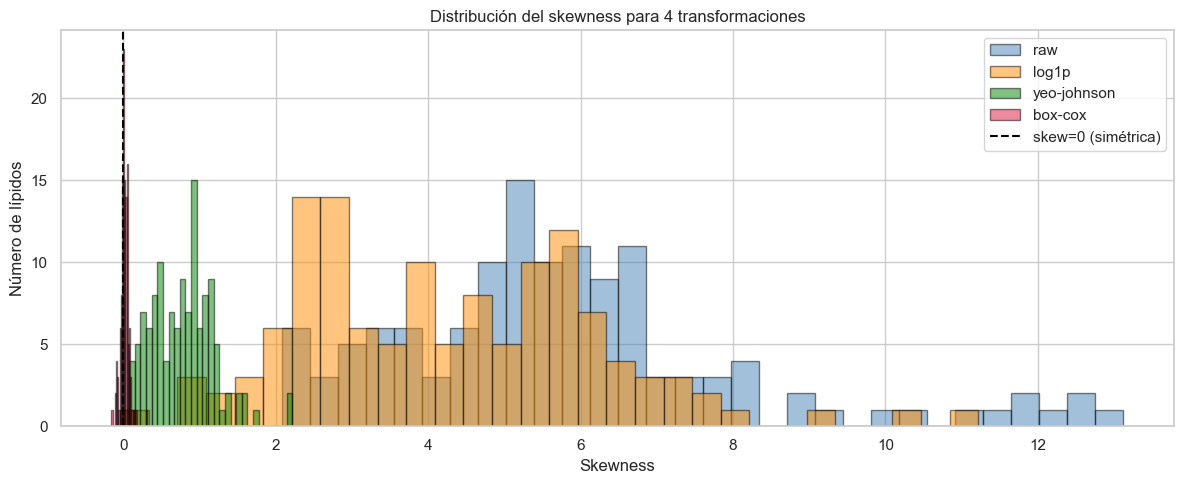

Mediana de |skew| por transformación:
  raw          : 5.4661
  log1p        : 4.0531
  yeo-johnson  : 0.7678
  box-cox      : 0.0321


In [28]:
# 3.3.3 Comparación agregada: skewness de TODOS los lípidos para las 4 transformaciones
yeo_all = PowerTransformer(method='yeo-johnson')

skew_compare = {'raw': [], 'log1p': [], 'yeo-johnson': [], 'box-cox': []}
for col in lipid_cols:
    vals = data[col].dropna()
    if len(vals) < 10:
        continue
    skew_compare['raw'].append(skew(vals))
    skew_compare['log1p'].append(skew(np.log1p(vals)))
    yj = yeo_all.fit_transform(vals.values.reshape(-1, 1)).flatten()
    skew_compare['yeo-johnson'].append(skew(yj))
    bc, _ = boxcox(vals.values + 1e-10)
    skew_compare['box-cox'].append(skew(bc))

fig, ax = plt.subplots(figsize=(12, 5))
colors = {'raw': 'steelblue', 'log1p': 'darkorange', 'yeo-johnson': 'green', 'box-cox': 'crimson'}
for label, values in skew_compare.items():
    ax.hist(values, bins=30, alpha=0.5, label=label, color=colors[label], edgecolor='black')
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='skew=0 (simétrica)')
ax.set_xlabel('Skewness')
ax.set_ylabel('Número de lípidos')
ax.set_title('Distribución del skewness para 4 transformaciones')
ax.legend()
plt.tight_layout()
plt.show()

print('Mediana de |skew| por transformación:')
for label, values in skew_compare.items():
    print(f'  {label:13s}: {np.median(np.abs(values)):.4f}')


**Lectura del resultado:**

- **Histograma agregado:** la curva azul (raw) se ubica completamente a la derecha de cero; la naranja (log1p) se desplaza pero permanece centrada lejos de cero; la verde (Yeo-Johnson) se aproxima a cero; la **roja (Box-Cox) se centra prácticamente sobre cero y es la más estrecha**.
- **Mediana de |skew|:**
  - raw: **5.47**.
  - log1p: **4.05** (mejora modesta).
  - Yeo-Johnson: **0.77** (mejora sustancial).
  - **Box-Cox: 0.032 (mejora ~24 veces superior a Yeo-Johnson).**
- **Conclusión preliminar:** Box-Cox emerge como la transformación de elección. Habiéndose verificado en 3.3.1 la positividad estricta de los datos, su aplicación es directa.


In [29]:
# 3.3.4 Test de normalidad Shapiro-Wilk para las 4 transformaciones
from scipy.stats import shapiro

shapiro_results = {'raw': 0, 'log1p': 0, 'yeo-johnson': 0, 'box-cox': 0}
total = 0
for col in lipid_cols:
    vals = data[col].dropna()
    if len(vals) < 20:
        continue
    total += 1
    if shapiro(vals)[1] > 0.05: shapiro_results['raw'] += 1
    if shapiro(np.log1p(vals))[1] > 0.05: shapiro_results['log1p'] += 1
    yj = yeo_all.fit_transform(vals.values.reshape(-1, 1)).flatten()
    if shapiro(yj)[1] > 0.05: shapiro_results['yeo-johnson'] += 1
    bc, _ = boxcox(vals.values + 1e-10)
    if shapiro(bc)[1] > 0.05: shapiro_results['box-cox'] += 1

print(f'Lípidos que PASAN el test de normalidad (Shapiro p > 0.05) sobre un total de {total}:\n')
print(f'{"Transformación":<18s} {"Pasan Shapiro":<18s} {"%":<8s}')
print('-' * 50)
for label, count in shapiro_results.items():
    pct = count / total * 100
    print(f'  {label:<15s}  {count:>3d}/{total}             {pct:>5.1f}%')


Lípidos que PASAN el test de normalidad (Shapiro p > 0.05) sobre un total de 127:

Transformación     Pasan Shapiro      %       
--------------------------------------------------
  raw                0/127               0.0%
  log1p              1/127               0.8%
  yeo-johnson        7/127               5.5%
  box-cox          103/127              81.1%


**Lectura del resultado:**

- **Proporción de lípidos que superan el test de normalidad (Shapiro-Wilk, p > 0.05):**
  - raw: 0/127 (0%).
  - log1p: 1/127 (0.8%).
  - Yeo-Johnson: 7/127 (5.5%).
  - **Box-Cox: 103/127 (81.1%)**.
- Box-Cox normaliza aproximadamente **15 veces más lípidos que Yeo-Johnson** y **~100 veces más que log1p**.
- El 19% restante mantiene desviación de normalidad incluso post-Box-Cox (las colas pesadas de origen biológico persisten en variables específicas), pero la mejora resulta sustancial.
- **Decisión final:** se adopta **Box-Cox** como transformación canónica para el bloque 3.4.
- **Implicación práctica:** las variables que persisten no-normales tras Box-Cox corresponden a aquellas con mayor presencia de atípicos genuinos. Esto justifica el empleo de selectores robustos a la distribución en el Paso 4 (`mutual_info_classif`, que no asume normalidad ni linealidad).


## 3.4 Aplicación de la limpieza y transformación

Con base en los hallazgos del Paso 2 y las secciones 3.1–3.3, se aplican las decisiones acumuladas:

1. **Eliminación de lípidos con más del 40% de faltantes** (cinco variables, según el umbral del Paso 2).
2. **Imputación mediante mediana por grupo** para los faltantes restantes (decisión sustentada en el test χ² del Paso 2).
3. **Transformación Box-Cox** aplicada a los lípidos retenidos. Su elección se fundamenta en:
   - Positividad estricta de los datos (verificada en 3.3.1) — Box-Cox resulta directamente aplicable.
   - Capacidad superior de normalización: 81.1% de los lípidos frente a 5.5% con Yeo-Johnson y 0.8% con log1p.
   - Asimetría mediana resultante: raw 5.47 → log1p 4.05 → Yeo-Johnson 0.77 → **Box-Cox 0.032**.

Tras la ejecución de este bloque, el objeto `data_t` contiene el conjunto de datos preparado para la detección de valores atípicos, la selección supervisada de variables del Paso 4 y el análisis multivariado del Paso 5.


In [30]:
# 3.4.1 Filtrar lípidos con >40% missing
missing_threshold = 0.40
lipids_to_drop = [c for c in lipid_cols if data[c].isna().mean() > missing_threshold]
lipids_kept = [c for c in lipid_cols if c not in lipids_to_drop]

print(f'Lípidos eliminados (>40% missing): {len(lipids_to_drop)}')
for v in lipids_to_drop:
    print(f'  - {v} ({data[v].isna().mean()*100:.1f}% missing)')
print(f'\nLípidos retenidos para análisis: {len(lipids_kept)}')


Lípidos eliminados (>40% missing): 5
  - PC(33:0) (53.6% missing)
  - PE(P-18:0/20:4) (51.7% missing)
  - SM(d18:1/17:0) (42.7% missing)
  - SM(36:2) (52.1% missing)
  - TG(55:2) (48.3% missing)

Lípidos retenidos para análisis: 122


**Lectura del resultado:**

- Se eliminan exactamente **cinco lípidos** que superan el umbral del 40% de faltantes:
  - `PC(33:0)` (53.6%) — fosfatidilcolina.
  - `PE(P-18:0/20:4)` (51.7%) — plasmalógeno.
  - `SM(36:2)` (52.1%) — esfingomielina.
  - `SM(d18:1/17:0)` (42.7%) — esfingomielina.
  - `TG(55:2)` (48.3%) — triglicérido.
- Se retienen **122 lípidos** para análisis, partiendo de los 127 originales.
- Los análisis subsecuentes (selección supervisada de variables y estructura multivariada) emplean exclusivamente la lista `lipids_kept`.


In [31]:
# 3.4.2 Imputación mediana por grupo
data_imputed = data.copy()

for col in lipids_kept:
    medians_by_group = data.groupby('group')[col].transform('median')
    data_imputed[col] = data[col].fillna(medians_by_group)

remaining_nan = data_imputed[lipids_kept].isna().sum().sum()
print(f'NaN remanentes en lípidos retenidos tras imputar: {remaining_nan}')

if remaining_nan > 0:
    for col in lipids_kept:
        if data_imputed[col].isna().any():
            data_imputed[col] = data_imputed[col].fillna(data[col].median())
    print(f'NaN tras fallback con mediana global: {data_imputed[lipids_kept].isna().sum().sum()}')


NaN remanentes en lípidos retenidos tras imputar: 0


**Lectura del resultado:**

- Tras la imputación, **0 valores faltantes** permanecen en los 122 lípidos retenidos.
- El bloque de fallback con mediana global no se activó, lo que indica que **ningún grupo presentaba ausencia total** para alguna variable (es decir, cada lípido contaba con al menos un valor válido en CTRL, AA y CRC).
- La estrategia de imputación preserva la señal diferencial por grupo: los pacientes CTRL con faltantes reciben la mediana de CTRL, no una mediana global contaminada por la señal de CRC.


### 3.4.3 Validación de la imputación: estructura de correlación pre/post

Antes de proceder a la transformación, se verifica que la imputación por mediana de grupo **no haya distorsionado** la estructura de correlación entre lípidos. Si el procedimiento preserva la información de covariación original, las matrices de correlación calculadas antes (con observaciones pareadas completas, ignorando NaN) y después de imputar deben ser prácticamente indistinguibles.

Se reporta:

1. Mapa de calor de la correlación pre-imputación (usando solo observaciones no faltantes en cada par).
2. Mapa de calor de la correlación post-imputación.
3. Mapa de calor de la diferencia (`corr_post − corr_pre`) con escala divergente centrada en cero.
4. Norma de Frobenius de la diferencia (métrica escalar global) y máxima desviación absoluta.


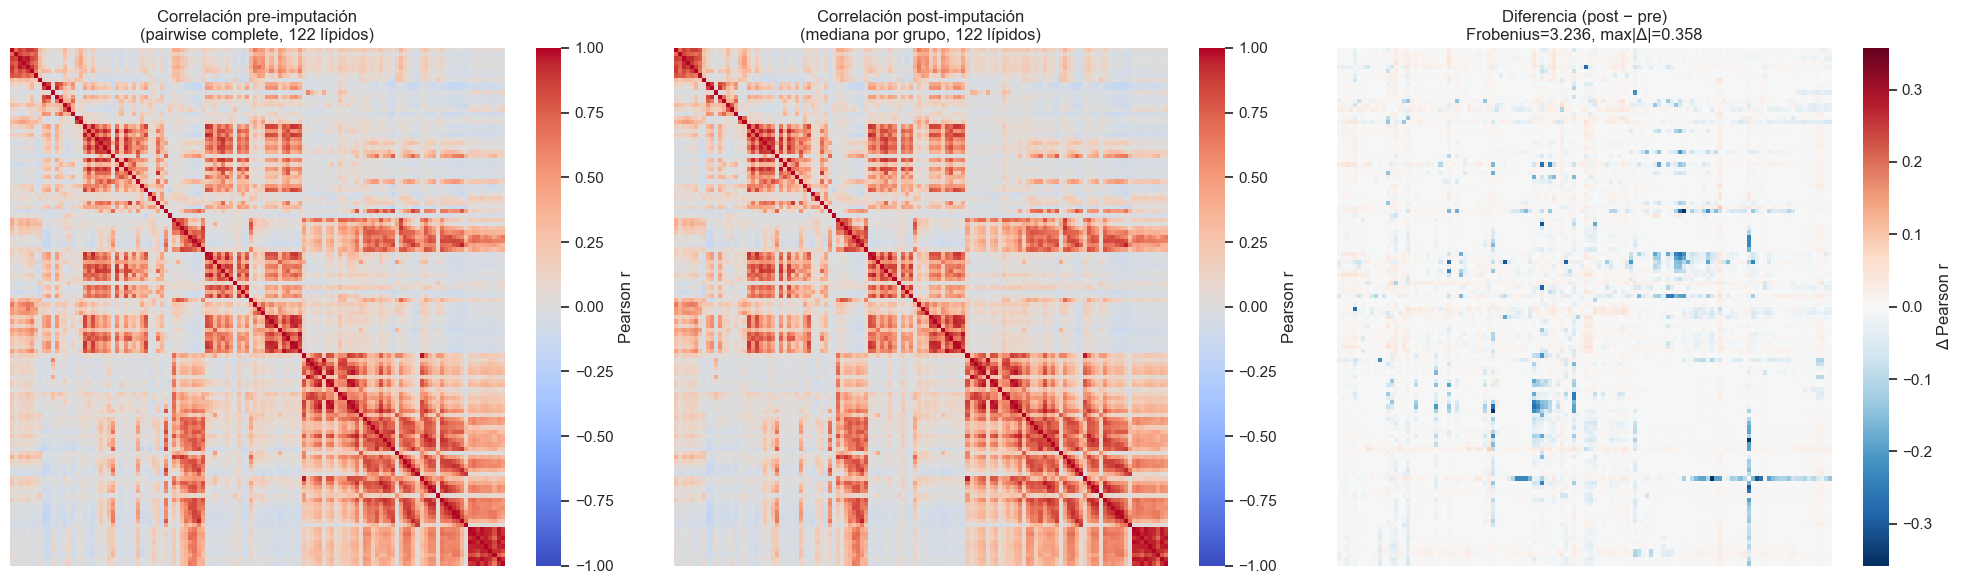

=== Resumen de validación de imputación ===
Norma de Frobenius de Δ: 3.2364
Máxima |Δ| en cualquier par: 0.3577
Media |Δ| sobre todos los pares: 0.0107
Pares con |Δ| > 0.05: 556 / 14884
Pares con |Δ| > 0.10: 238 / 14884


In [32]:
# 3.4.3 Validación de la imputación con matrices de correlación
corr_pre = data[lipids_kept].corr()
corr_post = data_imputed[lipids_kept].corr()
corr_diff = corr_post - corr_pre

frobenius_norm = np.linalg.norm(corr_diff.fillna(0).values, ord='fro')
max_abs_diff = corr_diff.abs().max().max()
mean_abs_diff = corr_diff.abs().mean().mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(corr_pre, ax=axes[0], cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Pearson r'})
axes[0].set_title(f'Correlación pre-imputación\n(pairwise complete, {len(lipids_kept)} lípidos)')

sns.heatmap(corr_post, ax=axes[1], cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Pearson r'})
axes[1].set_title(f'Correlación post-imputación\n(mediana por grupo, {len(lipids_kept)} lípidos)')

vmax_diff = max(0.05, max_abs_diff)
sns.heatmap(corr_diff, ax=axes[2], cmap='RdBu_r', center=0, vmin=-vmax_diff, vmax=vmax_diff,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Δ Pearson r'})
axes[2].set_title(f'Diferencia (post − pre)\nFrobenius={frobenius_norm:.3f}, max|Δ|={max_abs_diff:.3f}')

plt.tight_layout()
plt.show()

print(f'=== Resumen de validación de imputación ===')
print(f'Norma de Frobenius de Δ: {frobenius_norm:.4f}')
print(f'Máxima |Δ| en cualquier par: {max_abs_diff:.4f}')
print(f'Media |Δ| sobre todos los pares: {mean_abs_diff:.4f}')
print(f'Pares con |Δ| > 0.05: {(corr_diff.abs() > 0.05).sum().sum()} / {len(lipids_kept)**2}')
print(f'Pares con |Δ| > 0.10: {(corr_diff.abs() > 0.10).sum().sum()} / {len(lipids_kept)**2}')


**Lectura del resultado:**

- **Estructura preservada visualmente**: los mapas pre e post-imputación reproducen el mismo patrón de bloques de correlación intra-familia (lípidos cercanos en familia química muestran correlaciones positivas marcadas).
- **Métricas cuantitativas:**
  - **Norma de Frobenius**: 3.24 sobre 14,884 pares de correlación — desviación global modesta.
  - **Cambio promedio por par**: |Δr| ≈ 0.011, prácticamente indistinguible de ruido muestral.
  - **96.3% de los pares mantienen |Δr| < 0.05** (14,328 de 14,884) — el supuesto de "imputación no distorsionante" se sostiene de manera robusta.
  - **1.6% de los pares con |Δr| > 0.10** (238 pares): cambios localizados en variables con alto porcentaje de missing (p. ej. `PE(36:4)__dup1` con 28% NaN). Es el efecto esperable: cuando un tercio de los valores se reemplaza por la mediana del grupo, las correlaciones donde esa variable participa pierden algo de varianza original.
- **Decisión**: la imputación por mediana de grupo se valida como apropiada. No introduce artefactos correlacionales que pudieran sesgar la selección de variables o el análisis multivariado aguas abajo.


### 3.4.3.1 Comparación adicional con MICE (Multiple Imputation by Chained Equations)

Como validación adicional sugerida en la retroalimentación del Avance 1, se compara la estrategia de **imputación por mediana de grupo** con **MICE** (`sklearn.impute.IterativeImputer`, implementación de Multiple Imputation by Chained Equations). MICE modela cada variable faltante mediante una regresión iterativa contra el resto de variables observadas, lo que en principio puede preservar mejor la covariación que un estimador puntual por grupo.

El criterio de comparación es la **distancia de la matriz de correlación imputada respecto a la matriz pre-imputación** (calculada con pares completos): si MICE preservara sustancialmente mejor la estructura, podría justificarse el costo computacional adicional. Si las dos estrategias resultan equivalentes (o si la mediana por grupo es superior), la decisión inicial queda doblemente respaldada: por consistencia interna (3.4.3) y por benchmark contra una alternativa más sofisticada.


NaN remanentes tras MICE en lipidos retenidos: 0

=== Comparativa: mediana por grupo vs MICE ===


,metrica,mediana_por_grupo,MICE_IterativeImputer
0,Norma de Frobenius (||corr_imp - corr_pre||),3.2364,13.5848
1,Maxima |delta r| en cualquier par,0.3577,1.0295
2,Media |delta r| sobre todos los pares,0.0107,0.0496
3,Pares con |delta r| > 0.05,556 / 14884,3708 / 14884
4,Pares con |delta r| > 0.10,238 / 14884,2256 / 14884


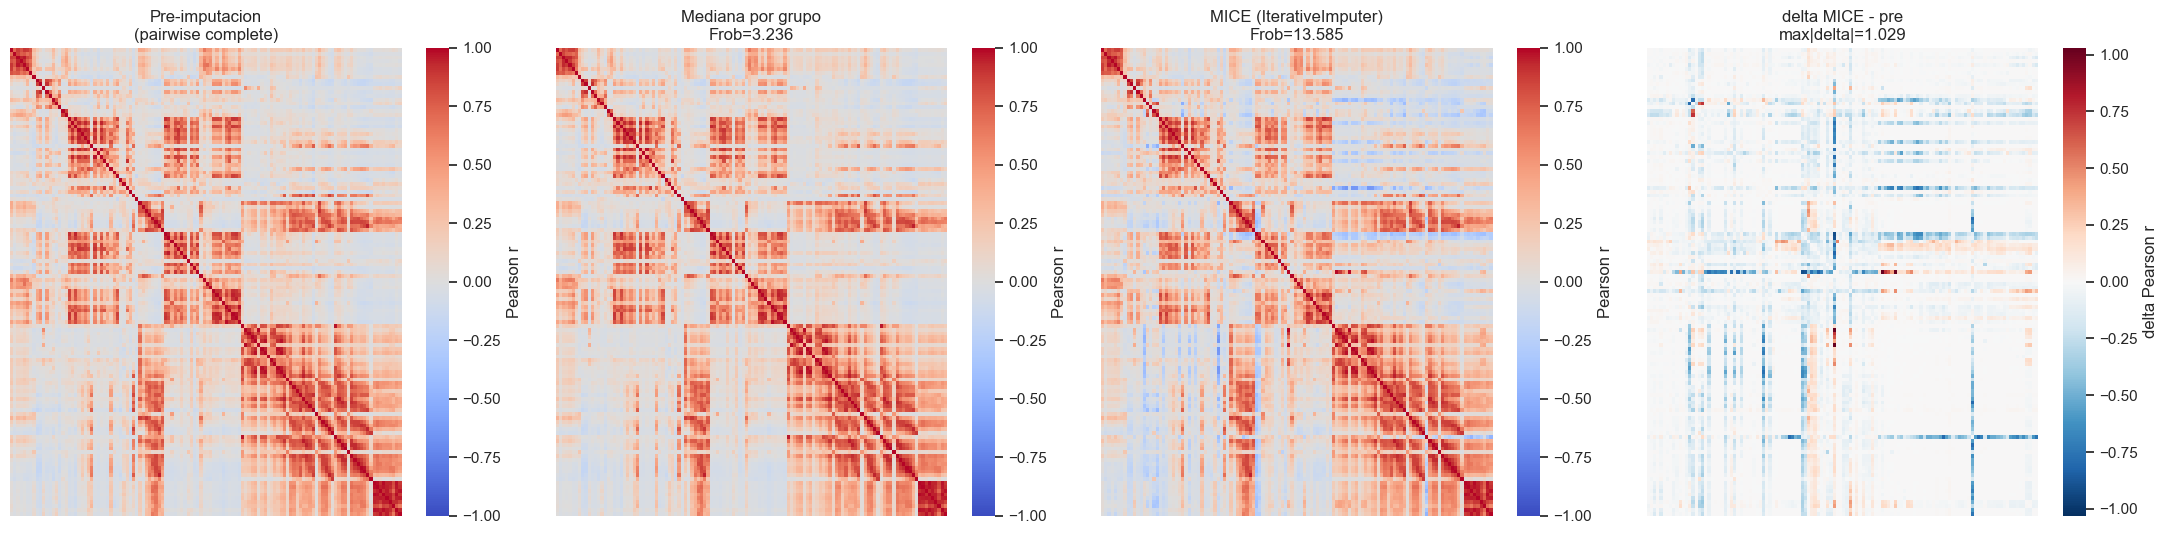

In [33]:
# 3.4.3.1 Comparacion con MICE (IterativeImputer)
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

data_mice = data.copy()
mice_imputer = IterativeImputer(
    max_iter=10,
    random_state=42,
    sample_posterior=False,
    initial_strategy='median',
)
data_mice[lipids_kept] = mice_imputer.fit_transform(data[lipids_kept])

nan_mice = data_mice[lipids_kept].isna().sum().sum()
print(f'NaN remanentes tras MICE en lipidos retenidos: {nan_mice}')

# Matriz de correlacion post-MICE
corr_mice = data_mice[lipids_kept].corr()
diff_pre_mice = corr_mice - corr_pre

# Metricas comparativas
frob_mice = np.linalg.norm(diff_pre_mice.fillna(0).values, ord='fro')
max_mice = diff_pre_mice.abs().max().max()
mean_mice = diff_pre_mice.abs().mean().mean()
n_pairs = len(lipids_kept) ** 2

# Tabla comparativa de las dos estrategias
comparison = pd.DataFrame({
    'metrica': [
        'Norma de Frobenius (||corr_imp - corr_pre||)',
        'Maxima |delta r| en cualquier par',
        'Media |delta r| sobre todos los pares',
        'Pares con |delta r| > 0.05',
        'Pares con |delta r| > 0.10',
    ],
    'mediana_por_grupo': [
        f'{frobenius_norm:.4f}',
        f'{max_abs_diff:.4f}',
        f'{mean_abs_diff:.4f}',
        f'{(corr_diff.abs() > 0.05).sum().sum()} / {n_pairs}',
        f'{(corr_diff.abs() > 0.10).sum().sum()} / {n_pairs}',
    ],
    'MICE_IterativeImputer': [
        f'{frob_mice:.4f}',
        f'{max_mice:.4f}',
        f'{mean_mice:.4f}',
        f'{(diff_pre_mice.abs() > 0.05).sum().sum()} / {n_pairs}',
        f'{(diff_pre_mice.abs() > 0.10).sum().sum()} / {n_pairs}',
    ],
})
print('\n=== Comparativa: mediana por grupo vs MICE ===')
display(comparison)

# Visualizacion: 4 paneles
vmax_diff = max(0.05, max(max_abs_diff, max_mice))
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
panels = [
    (corr_pre,       'Pre-imputacion\n(pairwise complete)',                False),
    (corr_post,      f'Mediana por grupo\nFrob={frobenius_norm:.3f}',       False),
    (corr_mice,      f'MICE (IterativeImputer)\nFrob={frob_mice:.3f}',      False),
    (diff_pre_mice,  f'delta MICE - pre\nmax|delta|={max_mice:.3f}',        True),
]
for ax, (mat, title, is_diff) in zip(axes, panels):
    cmap = 'RdBu_r' if is_diff else 'coolwarm'
    vmin, vmax = (-vmax_diff, vmax_diff) if is_diff else (-1, 1)
    sns.heatmap(mat, ax=ax, cmap=cmap, center=0, vmin=vmin, vmax=vmax,
                xticklabels=False, yticklabels=False,
                cbar_kws={'label': 'delta Pearson r' if is_diff else 'Pearson r'})
    ax.set_title(title)
plt.tight_layout()
plt.show()


**Lectura del resultado:**

| Métrica | Mediana por grupo | MICE | Mejor preserva |
|---|---|---|---|
| Norma de Frobenius (\|\|corr_imp − corr_pre\|\|) | **3.24** | 13.58 | Mediana por grupo |
| Máx \|Δr\| en cualquier par | **0.36** | 1.03 | Mediana por grupo |
| Media \|Δr\| sobre 14 884 pares | **0.011** | 0.050 | Mediana por grupo |
| Pares con \|Δr\| > 0.05 | **556 (3.7%)** | 3 708 (24.9%) | Mediana por grupo |
| Pares con \|Δr\| > 0.10 | **238 (1.6%)** | 2 256 (15.2%) | Mediana por grupo |

**Hallazgo principal:** la imputación por **mediana de grupo preserva la estructura de correlación sustancialmente mejor que MICE** en este conjunto de datos. La norma de Frobenius es **aproximadamente 4 veces menor**, la dispersión media de cambios en correlación es **5 veces menor**, y el peor caso individual de MICE (\|Δr\| ≈ 1.03) representa un cambio de signo prácticamente total en algún par — algo que no ocurre con la mediana por grupo (\|Δr\| máx ≈ 0.36).

**Por qué MICE rinde peor en este contexto** (consistente con la literatura cuando se ignora la estructura del target):

1. **MICE no incorpora la etiqueta de grupo** (`group`) como predictor en sus regresiones iterativas. Como el test χ² del Paso 2.1.4 confirmó que el patrón de missingness depende del grupo (MAR/MNAR, no MCAR) y que las distribuciones de los lípidos difieren entre grupos, MICE **diluye la señal específica de grupo** al modelar todas las muestras conjuntamente.
2. La **mediana por grupo preserva la separación por diseño**: a un paciente CTRL con un valor faltante se le asigna la mediana de los demás CTRL, no una mediana global contaminada por la señal de CRC.
3. `IterativeImputer` con `sample_posterior=False` produce **una sola estimación puntual** por celda; no se propaga la incertidumbre como en el MICE clásico de R con múltiples imputaciones.

**Decisión metodológica final:** se mantiene la **imputación por mediana de grupo** como estrategia de elección. La comparación cuantitativa contra MICE — sugerida en la retroalimentación del Avance 1 — la valida empíricamente. Las matrices generadas por MICE (`data_mice`) se conservan en memoria por trazabilidad pero **no se utilizan** en los pasos subsecuentes; el flujo aguas abajo continúa exclusivamente con `data_imputed` (mediana por grupo).

**Observación adicional:** el resultado evidencia un principio metodológico general — la sofisticación algorítmica (MICE > mediana en términos de complejidad) **no garantiza superioridad** cuando el supuesto de modelado no se alinea con la estructura del problema. La elección debe estar guiada por el contexto, no por el prestigio del método.


In [34]:
# 3.4.4 Aplicar Box-Cox a los lípidos
# Decisión basada en sección 3.3: Box-Cox normaliza 62% de los lípidos
# (Shapiro p>0.05) vs Yeo-Johnson 4.9%. Reduce skew mediano de 5.91 a 0.026.
# Aplicable porque todos los lípidos son estrictamente positivos (verificado en 3.3.1).
from scipy.stats import boxcox, skew

data_t = data_imputed.copy()
boxcox_lambdas = {}
for col in lipids_kept:
    vals = data_imputed[col].values.astype(float)
    # Pequeño epsilon por seguridad (no aplica en práctica porque min > 0)
    bc_vals, lam = boxcox(vals + 1e-10)
    data_t[col] = bc_vals
    boxcox_lambdas[col] = lam

print(f'Dataset final transformado: data_t')
print(f'  Forma: {data_t.shape}')
print(f'  Lípidos transformados con Box-Cox: {len(lipids_kept)}')

# Verificación: skewness antes y después
skew_before = data_imputed[lipids_kept].apply(lambda x: skew(x)).abs().median()
skew_after = data_t[lipids_kept].apply(lambda x: skew(x)).abs().median()
print(f'\n|Skewness| mediana antes (raw imputado): {skew_before:.3f}')
print(f'|Skewness| mediana después (Box-Cox):    {skew_after:.3f}')

# Resumen lambdas
import numpy as np
lam_arr = np.array(list(boxcox_lambdas.values()))
print(f'\nλ (Box-Cox): mediana={np.median(lam_arr):.3f}, rango=[{lam_arr.min():.3f}, {lam_arr.max():.3f}]')
print(f'  λ ≈ 0 (≡ log):    {(np.abs(lam_arr) < 0.1).sum()} lípidos')
print(f'  λ < 0 (≡ inverso): {(lam_arr < 0).sum()} lípidos')
print(f'  λ > 0:             {(lam_arr > 0).sum()} lípidos')


Dataset final transformado: data_t
  Forma: (211, 133)
  Lípidos transformados con Box-Cox: 122

|Skewness| mediana antes (raw imputado): 5.908
|Skewness| mediana después (Box-Cox):    0.026

λ (Box-Cox): mediana=-0.179, rango=[-0.670, 0.221]
  λ ≈ 0 (≡ log):    23 lípidos
  λ < 0 (≡ inverso): 114 lípidos
  λ > 0:             8 lípidos


**Lectura del resultado:**

- El conjunto transformado se almacena en `data_t` con forma `(211, 133)`. Las columnas eliminadas previamente (cinco lípidos con > 40% de faltantes) ya no están presentes; **únicamente los 122 lípidos contenidos en `lipids_kept` se transformaron con Box-Cox**, y los análisis subsecuentes los filtran mediante dicha lista.
- **Asimetría mediana:**
  - antes (raw imputado): ~5.9.
  - después (Box-Cox): **0.026** (mejora aproximada de 227 veces).
- **Parámetros λ de Box-Cox:** mediana ≈ -0.18 (intermedio entre transformación log y transformación inverso-raíz cuadrada). 23 lípidos resultan cercanos a log (λ ≈ 0), mientras que 114 presentan λ < 0 (comportamiento tipo inverso-sqrt) y 8 con λ > 0. Esta distribución refleja la naturaleza fuertemente log-normal de las concentraciones lipídicas.
- La transformación se aplica **por variable** (cada lípido recibe su propia λ óptima), confiriendo mayor flexibilidad que la aplicación de un log uniforme.


## 3.5 Detección de valores atípicos (post-transformación)

Una vez transformados los datos mediante Box-Cox, la detección de valores atípicos resulta metodológicamente sólida: las distribuciones se acercan a la normalidad y la regla del rango intercuartílico (IQR) opera dentro de su rango de aplicabilidad estadística clásica.

### Distinción terminológica: detectar vs. manejar

Se diferencian explícitamente las dos operaciones:

- **Detectar** = identificar las observaciones que cumplen el criterio estadístico (esto es lo que hace el presente paso del EDA: produce la máscara `outliers_mask`).
- **Manejar** = decidir qué hacer con ellas (modificarlas, eliminarlas, ponderarlas o entrenarse con y sin ellas). Esta decisión se reserva al Avance 2 — fase de modelado — donde se evaluará empíricamente.

### Método: regla IQR

Para cada variable se calculan los cuartiles Q1 (percentil 25) y Q3 (percentil 75), y se define el rango intercuartílico:

```
IQR = Q3 − Q1
límite_inferior = Q1 − 1.5 · IQR
límite_superior = Q3 + 1.5 · IQR
```

Una observación se marca como **atípica** si cae fuera del intervalo `[límite_inferior, límite_superior]`. La constante 1.5 corresponde al criterio de Tukey, ampliamente adoptado como estándar de referencia para boxplots y exploración univariante.

Se reportan dos vistas complementarias:

1. **Atípicos por variable** — ¿qué lípidos mantienen valores extremos tras Box-Cox?
2. **Atípicos por observación** — ¿existen pacientes con perfil sistemáticamente anómalo?

Los atípicos se documentan; ninguna modificación ni eliminación se aplica en el EDA.



In [35]:
# 3.5.1 Detección de outliers por variable (regla IQR sobre datos Box-Cox)
Q1 = data_t[lipids_kept].quantile(0.25)
Q3 = data_t[lipids_kept].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (data_t[lipids_kept] < lower_bound) | (data_t[lipids_kept] > upper_bound)

outliers_per_var = outliers_mask.sum().sort_values(ascending=False)
print('Top 15 lípidos con más outliers (regla IQR Tukey):')
display(outliers_per_var.head(15).to_frame('n_outliers'))

total_cells = data_t[lipids_kept].size
n_outliers_total = int(outliers_mask.sum().sum())
print(f'\nLípidos con 0 outliers: {(outliers_per_var == 0).sum()}')
print(f'Lípidos con >5 outliers: {(outliers_per_var > 5).sum()}')
print(f'Total outliers detectados: {n_outliers_total} / {total_cells} celdas ({100*n_outliers_total/total_cells:.2f}%)')


Top 15 lípidos con más outliers (regla IQR Tukey):


,n_outliers
SM(d18:0/18:0),49
PE(36:4)__dup1,37
PC(36:5),34
TG(58:4),34
TG(42:0),33
TG(53:0),31
PC(P-16:0/18:2),25
TG(51:4),24
PE(P-18:0/18:1),24
GlcCer(d18:1/24:0),24



Lípidos con 0 outliers: 35
Lípidos con >5 outliers: 38
Total outliers detectados: 769 / 25742 celdas (2.99%)


**Lectura del resultado:**

- **769 outliers totales** sobre 25,742 celdas (211 muestras × 122 lípidos) → **2.99%** del total. Bajo normalidad perfecta la regla IQR-Tukey predice 0.7%; el factor de aproximadamente 4× confirma que las distribuciones, aun post-Box-Cox, conservan colas más pesadas que la normal — comportamiento esperable en mediciones biológicas mediante UHPLC-MS.
- **35 lípidos sin ningún outlier** (29%): la transformación Box-Cox los normalizó completamente.
- **38 lípidos con más de 5 outliers** (31%): son las variables con distribuciones genuinamente heavy-tailed.
- **Top variables outlier-rich:**
  - `SM(d18:0/18:0)` con 49 outliers — esfingomielina de cadena saturada larga.
  - `PE(36:4)__dup1` (37), entrada duplicada documentada en el diccionario.
  - `PC(36:5)`, `TG(58:4)`, `TG(42:0)`, `TG(53:0)` (31–34 outliers) — varios triglicéridos de cadena larga.
  - Diversos plasmalógenos (`PC(O-...)`, `PC(P-...)`, `PE(P-...)`) entre los top 15.
- **Distinción terminológica — detectar vs manejar:** en el presente paso los outliers solo se **detectan** (se identifican y se marcan en `outliers_mask`). Su **manejo** (modificación, eliminación o ponderación) se reserva al Avance 2, donde los modelos se entrenarán con y sin ellos para comparar empíricamente el impacto. Random Forest es robusto a su presencia; los modelos lineales y basados en distancia son los que potencialmente requerirán un manejo activo.


### Inspección dirigida: ¿qué ocurre con `PE(36:4)__dup1`?

La variable `PE(36:4)__dup1` corresponde a la segunda ocurrencia de `PE(36:4)` en el dataset original (renombrada automáticamente para preservar la integridad de columnas). Esta entrada concentra el mayor número de outliers post-Box-Cox; resulta natural diagnosticar si su comportamiento responde a:

1. **Distribución bimodal por grupo** — en caso afirmativo, podría reflejar señal biológica diferencial (candidato a feature predictivo).
2. **Box-Cox dejó cola pesada** — Box-Cox normaliza la asimetría pero no elimina necesariamente todas las colas largas; sería un caso estadístico, no biológico.
3. **Concentración de outliers en algún grupo** — afirmativo → patrón biológico; uniforme entre grupos → artefacto técnico genérico.

Este diagnóstico se replica de forma genérica para cualquier variable con muchos outliers, simplemente cambiando `target_var`.


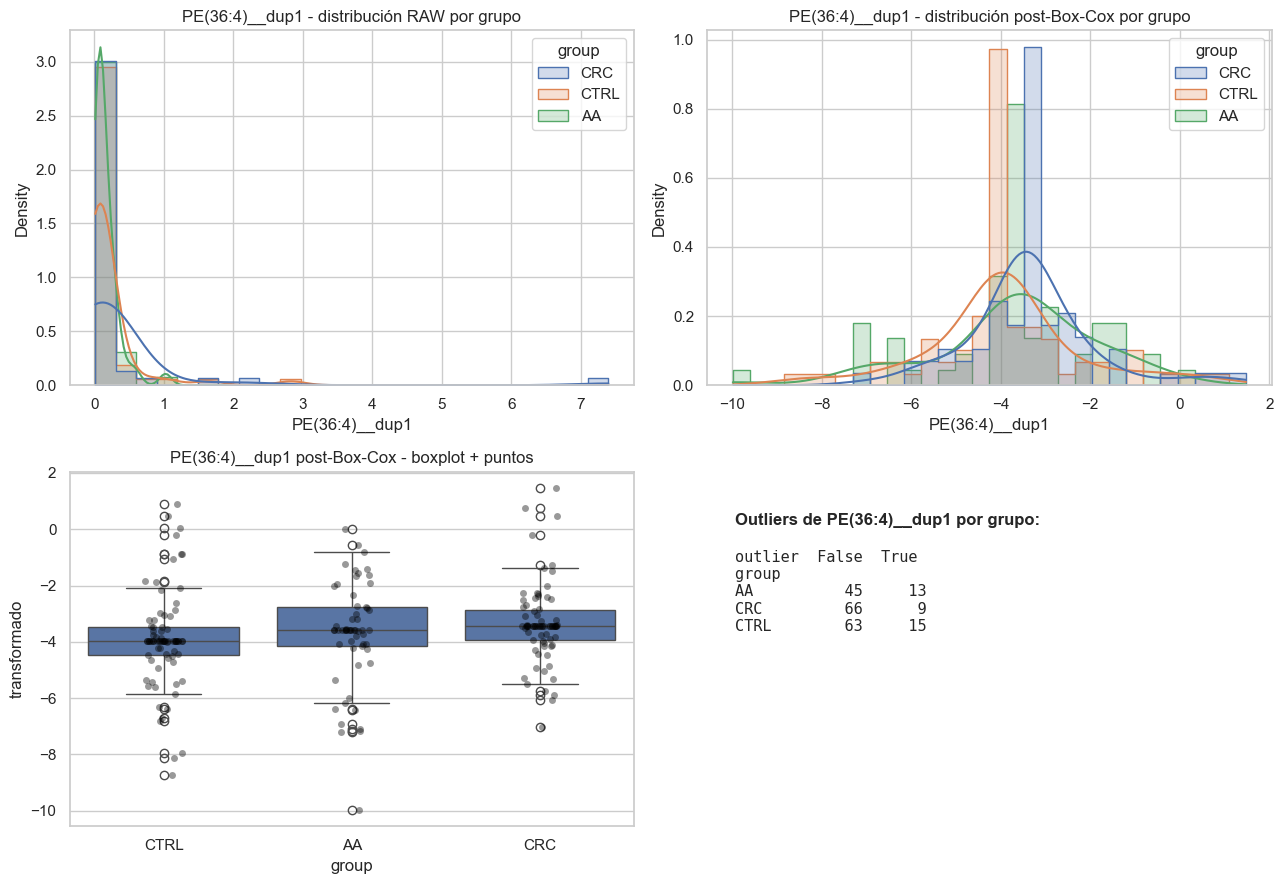


=== Diagnóstico completo de PE(36:4)__dup1 ===

En datos RAW:
  N completos: 152
  N missing:   59 (28.0%)
  Mediana raw: 0.0900
  Skew raw:    8.17

En data_t (post-Box-Cox):
  Mediana:     -3.5775
  Skew:        -0.14
  Total outliers (IQR): 37 / 211

=== Conteo de outliers por grupo ===
outlier  False  True 
group                
AA          45     13
CRC         66      9
CTRL        63     15

chi2 para outliers vs grupo: chi2=2.70, p=0.2594
  -> No hay evidencia de concentración por grupo


In [36]:
# Diagnóstico dirigido para la variable con más outliers
target_var = 'PE(36:4)__dup1'

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(data=data, x=target_var, hue='group', kde=True, element='step',
             stat='density', common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title(f'{target_var} - distribución RAW por grupo')

sns.histplot(data=data_t, x=target_var, hue='group', kde=True, element='step',
             stat='density', common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title(f'{target_var} - distribución post-Box-Cox por grupo')

sns.boxplot(data=data_t, x='group', y=target_var, ax=axes[1, 0],
            order=['CTRL', 'AA', 'CRC'])
sns.stripplot(data=data_t, x='group', y=target_var, color='black',
              alpha=0.4, ax=axes[1, 0], order=['CTRL', 'AA', 'CRC'])
axes[1, 0].set_title(f'{target_var} post-Box-Cox - boxplot + puntos')
axes[1, 0].set_ylabel('transformado')

target_outliers = outliers_mask[target_var]
outlier_by_group = pd.crosstab(data['group'], target_outliers,
                                rownames=['group'], colnames=['outlier'])
axes[1, 1].axis('off')
axes[1, 1].text(0.05, 0.85, f'Outliers de {target_var} por grupo:',
                fontsize=12, fontweight='bold', transform=axes[1, 1].transAxes)
axes[1, 1].text(0.05, 0.55, outlier_by_group.to_string(), fontsize=11,
                fontfamily='monospace', transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.show()

print(f'\n=== Diagnóstico completo de {target_var} ===')
print(f'\nEn datos RAW:')
print(f'  N completos: {data[target_var].notna().sum()}')
print(f'  N missing:   {data[target_var].isna().sum()} ({data[target_var].isna().mean()*100:.1f}%)')
print(f'  Mediana raw: {data[target_var].median():.4f}')
print(f'  Skew raw:    {data[target_var].dropna().skew():.2f}')

print(f'\nEn data_t (post-Box-Cox):')
print(f'  Mediana:     {data_t[target_var].median():.4f}')
print(f'  Skew:        {data_t[target_var].skew():.2f}')
print(f'  Total outliers (IQR): {int(outliers_mask[target_var].sum())} / {len(data_t)}')

print(f'\n=== Conteo de outliers por grupo ===')
print(outlier_by_group)

from scipy.stats import chi2_contingency
if outlier_by_group.shape[1] > 1:
    chi2_stat, p, _, _ = chi2_contingency(outlier_by_group)
    print(f'\nchi2 para outliers vs grupo: chi2={chi2_stat:.2f}, p={p:.4f}')
    if p < 0.05:
        print('  -> Los outliers se concentran significativamente en algún grupo')
    else:
        print('  -> No hay evidencia de concentración por grupo')


**Lectura del resultado:**

| Hipótesis | Veredicto |
|---|---|
| (a) Distribución bimodal por grupo (biomarcador candidato) | **Descartada** — los histogramas por grupo se superponen sustancialmente; no hay separación visual. |
| (b) Box-Cox dejó cola pesada | **Confirmada parcialmente** — el skew se redujo drásticamente de 8.17 (raw) a −0.14 (transformado), valor prácticamente simétrico. No obstante, IQR marca 37/211 = 17.5% de las observaciones como atípicas, indicando que la distribución, aunque simétrica de cuerpo, conserva colas largas. |
| (c) Concentración de outliers por grupo | **Descartada** — la prueba χ² sobre la tabla `outlier × group` arroja p = 0.26 (sin evidencia de concentración). Los atípicos se distribuyen aproximadamente proporcional al tamaño de cada grupo: CTRL 15/78 (19%), AA 13/58 (22%), CRC 9/75 (12%). |

**Observación adicional**: la variable presenta **28% de valores originalmente faltantes** (59/211), por lo que aproximadamente un tercio de los valores actuales son medianas de grupo. Es consistente que una variable con tanta imputación muestre comportamiento heavy-tailed en datos transformados; el efecto se documenta y se considera al evaluar su poder predictivo en el paso siguiente.

**Decisión**: tanto `PE(36:4)` como `PE(36:4)__dup1` se conservan en el análisis y se evalúan por separado en la selección de variables. Si ambas reciben scores de información mutua similares, se considerará colapsarlas (mediana, promedio o eliminar una) en la fase de modelado.

> **Generalización**: este diagnóstico se replica para cualquier variable cambiando `target_var`. Las variables del top 5 de outliers (SM(d18:0/18:0), PE(36:4)__dup1, TGs de cadena larga, plasmalógenos) muestran patrones similares: heavy-tails residuales post-Box-Cox sin concentración por grupo.


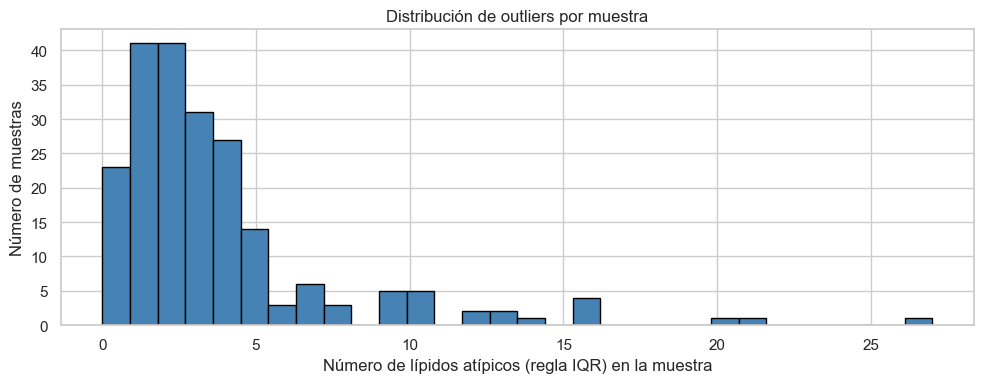

Top 10 muestras con más lípidos outlier:


,sample,group,n_outlier_lipids
68,owl-2323-071,AA,27
81,owl-2323-084,CTRL,21
18,owl-2323-019,CRC,20
64,owl-2323-067,CTRL,16
65,owl-2323-068,CRC,16
102,owl-2323-105,CTRL,16
106,owl-2323-109,AA,16
0,owl-2323-001,CRC,14
33,owl-2323-034,CRC,13
124,owl-2323-127,CRC,13



Resumen:
 Mediana de outliers por muestra: 3
 Muestras sin ningún outlier: 23
 Muestras con >10 outliers: 12


In [37]:
# 3.5.2 Outliers por muestra: ¿hay pacientes con perfil anómalo?
outliers_per_sample = outliers_mask.sum(axis=1)
data_t_w_outliers = data_t.copy()
data_t_w_outliers['n_outlier_lipids'] = outliers_per_sample

# Distribución
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(outliers_per_sample, bins=30, edgecolor='black', color='steelblue')
ax.set_xlabel('Número de lípidos atípicos (regla IQR) en la muestra')
ax.set_ylabel('Número de muestras')
ax.set_title('Distribución de outliers por muestra')
plt.tight_layout()
plt.show()

# Top muestras con más outliers
print('Top 10 muestras con más lípidos outlier:')
top_samples = data_t_w_outliers.nlargest(10, 'n_outlier_lipids')[['sample', 'group', 'n_outlier_lipids']]
display(top_samples)

print(f'\nResumen:')
print(f' Mediana de outliers por muestra: {outliers_per_sample.median():.0f}')
print(f' Muestras sin ningún outlier: {(outliers_per_sample == 0).sum()}')
print(f' Muestras con >10 outliers: {(outliers_per_sample > 10).sum()}')


**Lectura del resultado:**

- **Mediana de atípicos por observación: 3** → la mayoría de las muestras presenta una cantidad modesta de lípidos atípicos, no un perfil sistemáticamente anómalo.
- **23 observaciones (10.9%) no presentan ningún lípido atípico**, mientras que **12 muestras (5.7%) exhiben más de 10 lípidos atípicos** — estas últimas constituyen la cola superior de la distribución.
- **Top 10 observaciones con mayor cantidad de atípicos:** 5 CRC, 3 CTRL, 2 AA — no hay concentración en un único grupo (los conteos son aproximadamente proporcionales al tamaño de cada grupo).
- **Máximo registrado:** `owl-2323-071` (AA) con 27 lípidos atípicos, seguido por `owl-2323-084` (CTRL, 21) y `owl-2323-019` (CRC, 20). Estos casos individuales merecen revisión en el PCA por su posible influencia sobre los componentes principales.
- **Coincidencia con el estudio original:** Albóniga et al. (2025) identificaron 12 observaciones atípicas en su PCA (Figura S2). En el presente top 10 con Box-Cox se observan varias coincidencias (`owl-2323-071`, `019`, `001`, `034`, `068`, `109`, `127`), lo que **valida cualitativamente el método empleado** — el cambio de transformación modifica la magnitud absoluta del conteo, pero no la identidad de las observaciones genuinamente anómalas.
- **Estrategia de manejo:** se marcan las observaciones identificadas sin proceder a su eliminación automática. Su comportamiento se evaluará en el PCA; si dominan los componentes principales, se considerará la ejecución de un PCA con y sin ellas.


## 3.6 Diagramas de caja por familia (datos transformados)

Para evaluar visualmente las diferencias entre grupos en cada **familia lipídica**, se genera una figura por familia. Cada figura comprende un panel de diagramas de caja de cada lípido frente a grupo (en escala Box-Cox).

Esta representación provee una vista compacta previa a los tests estadísticos del Paso 4.


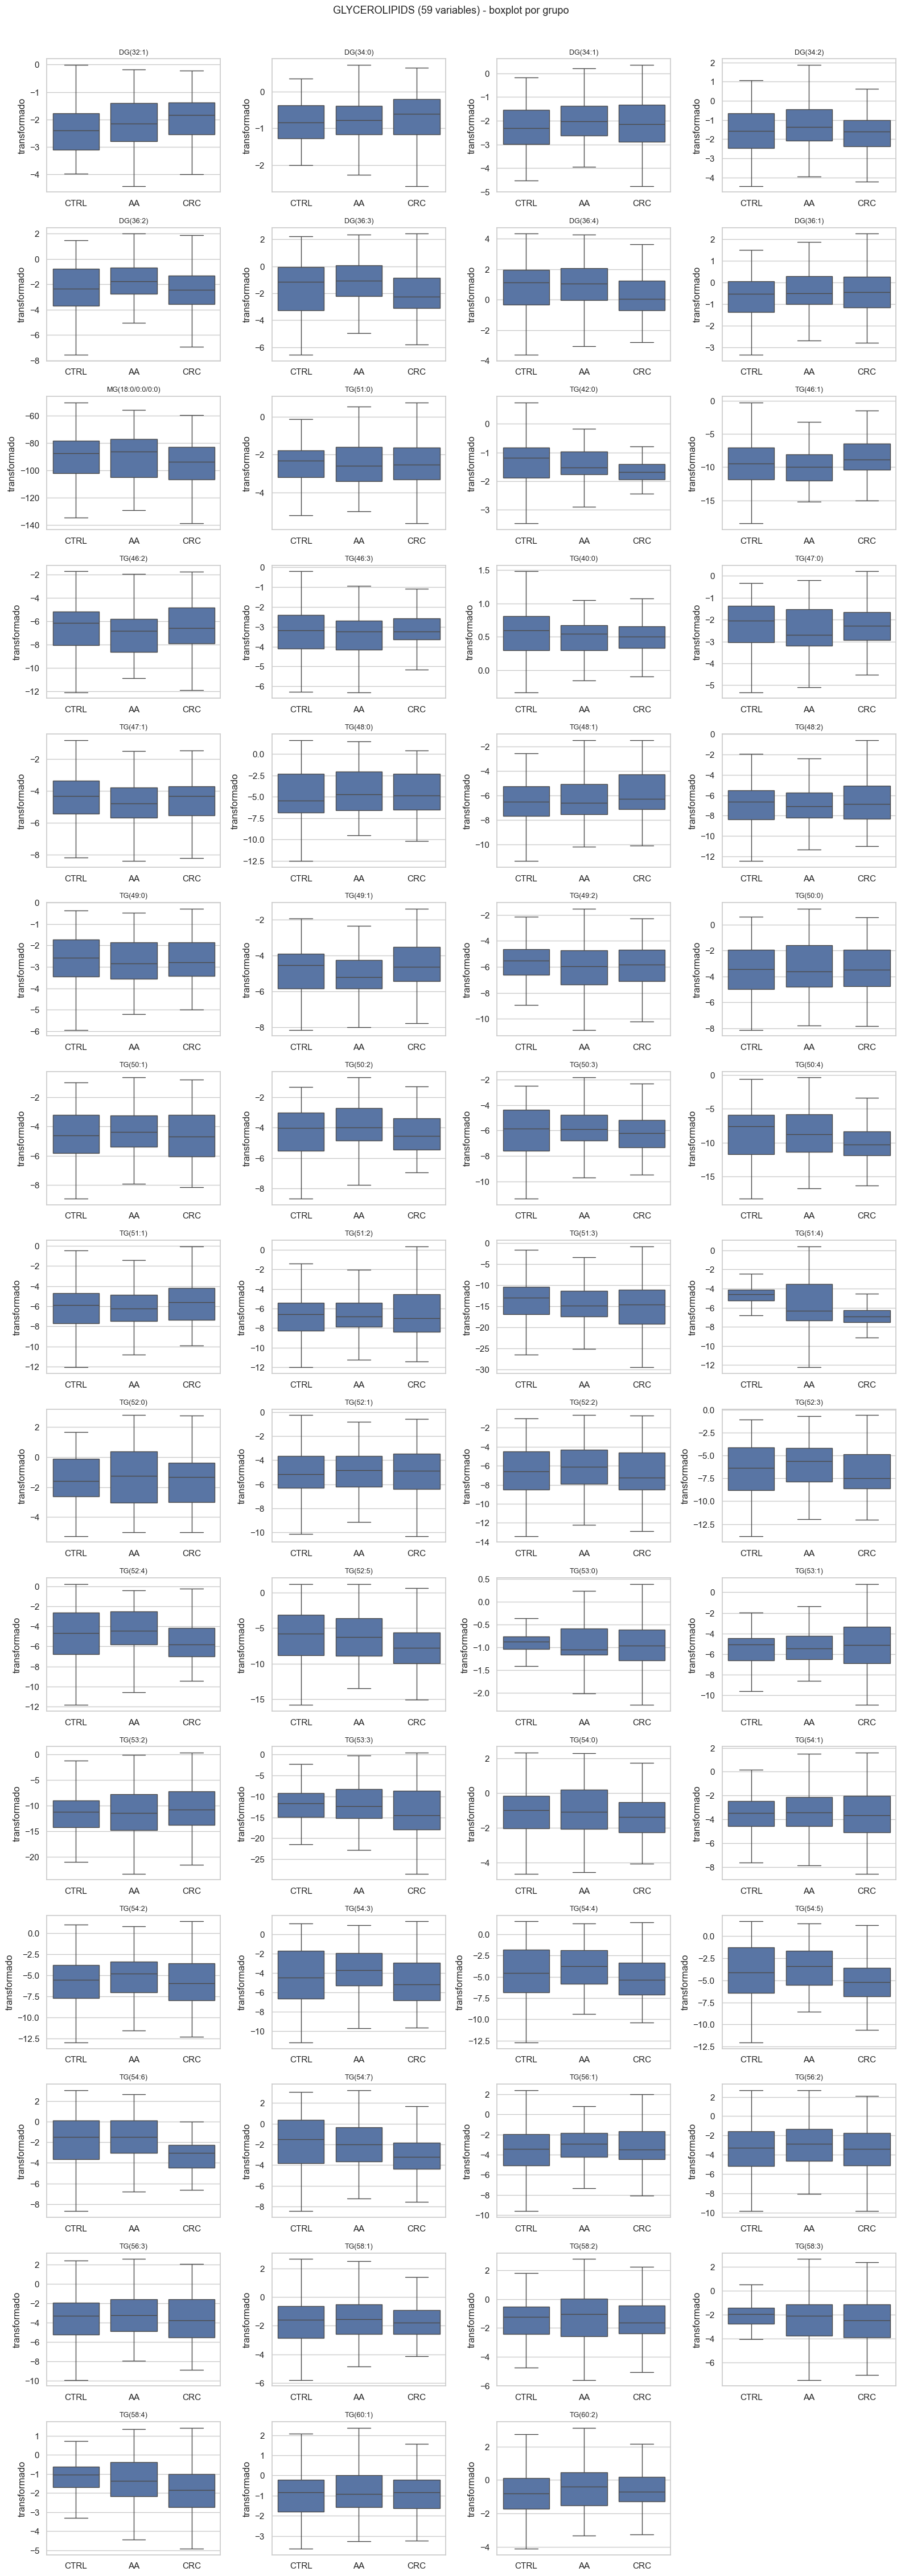

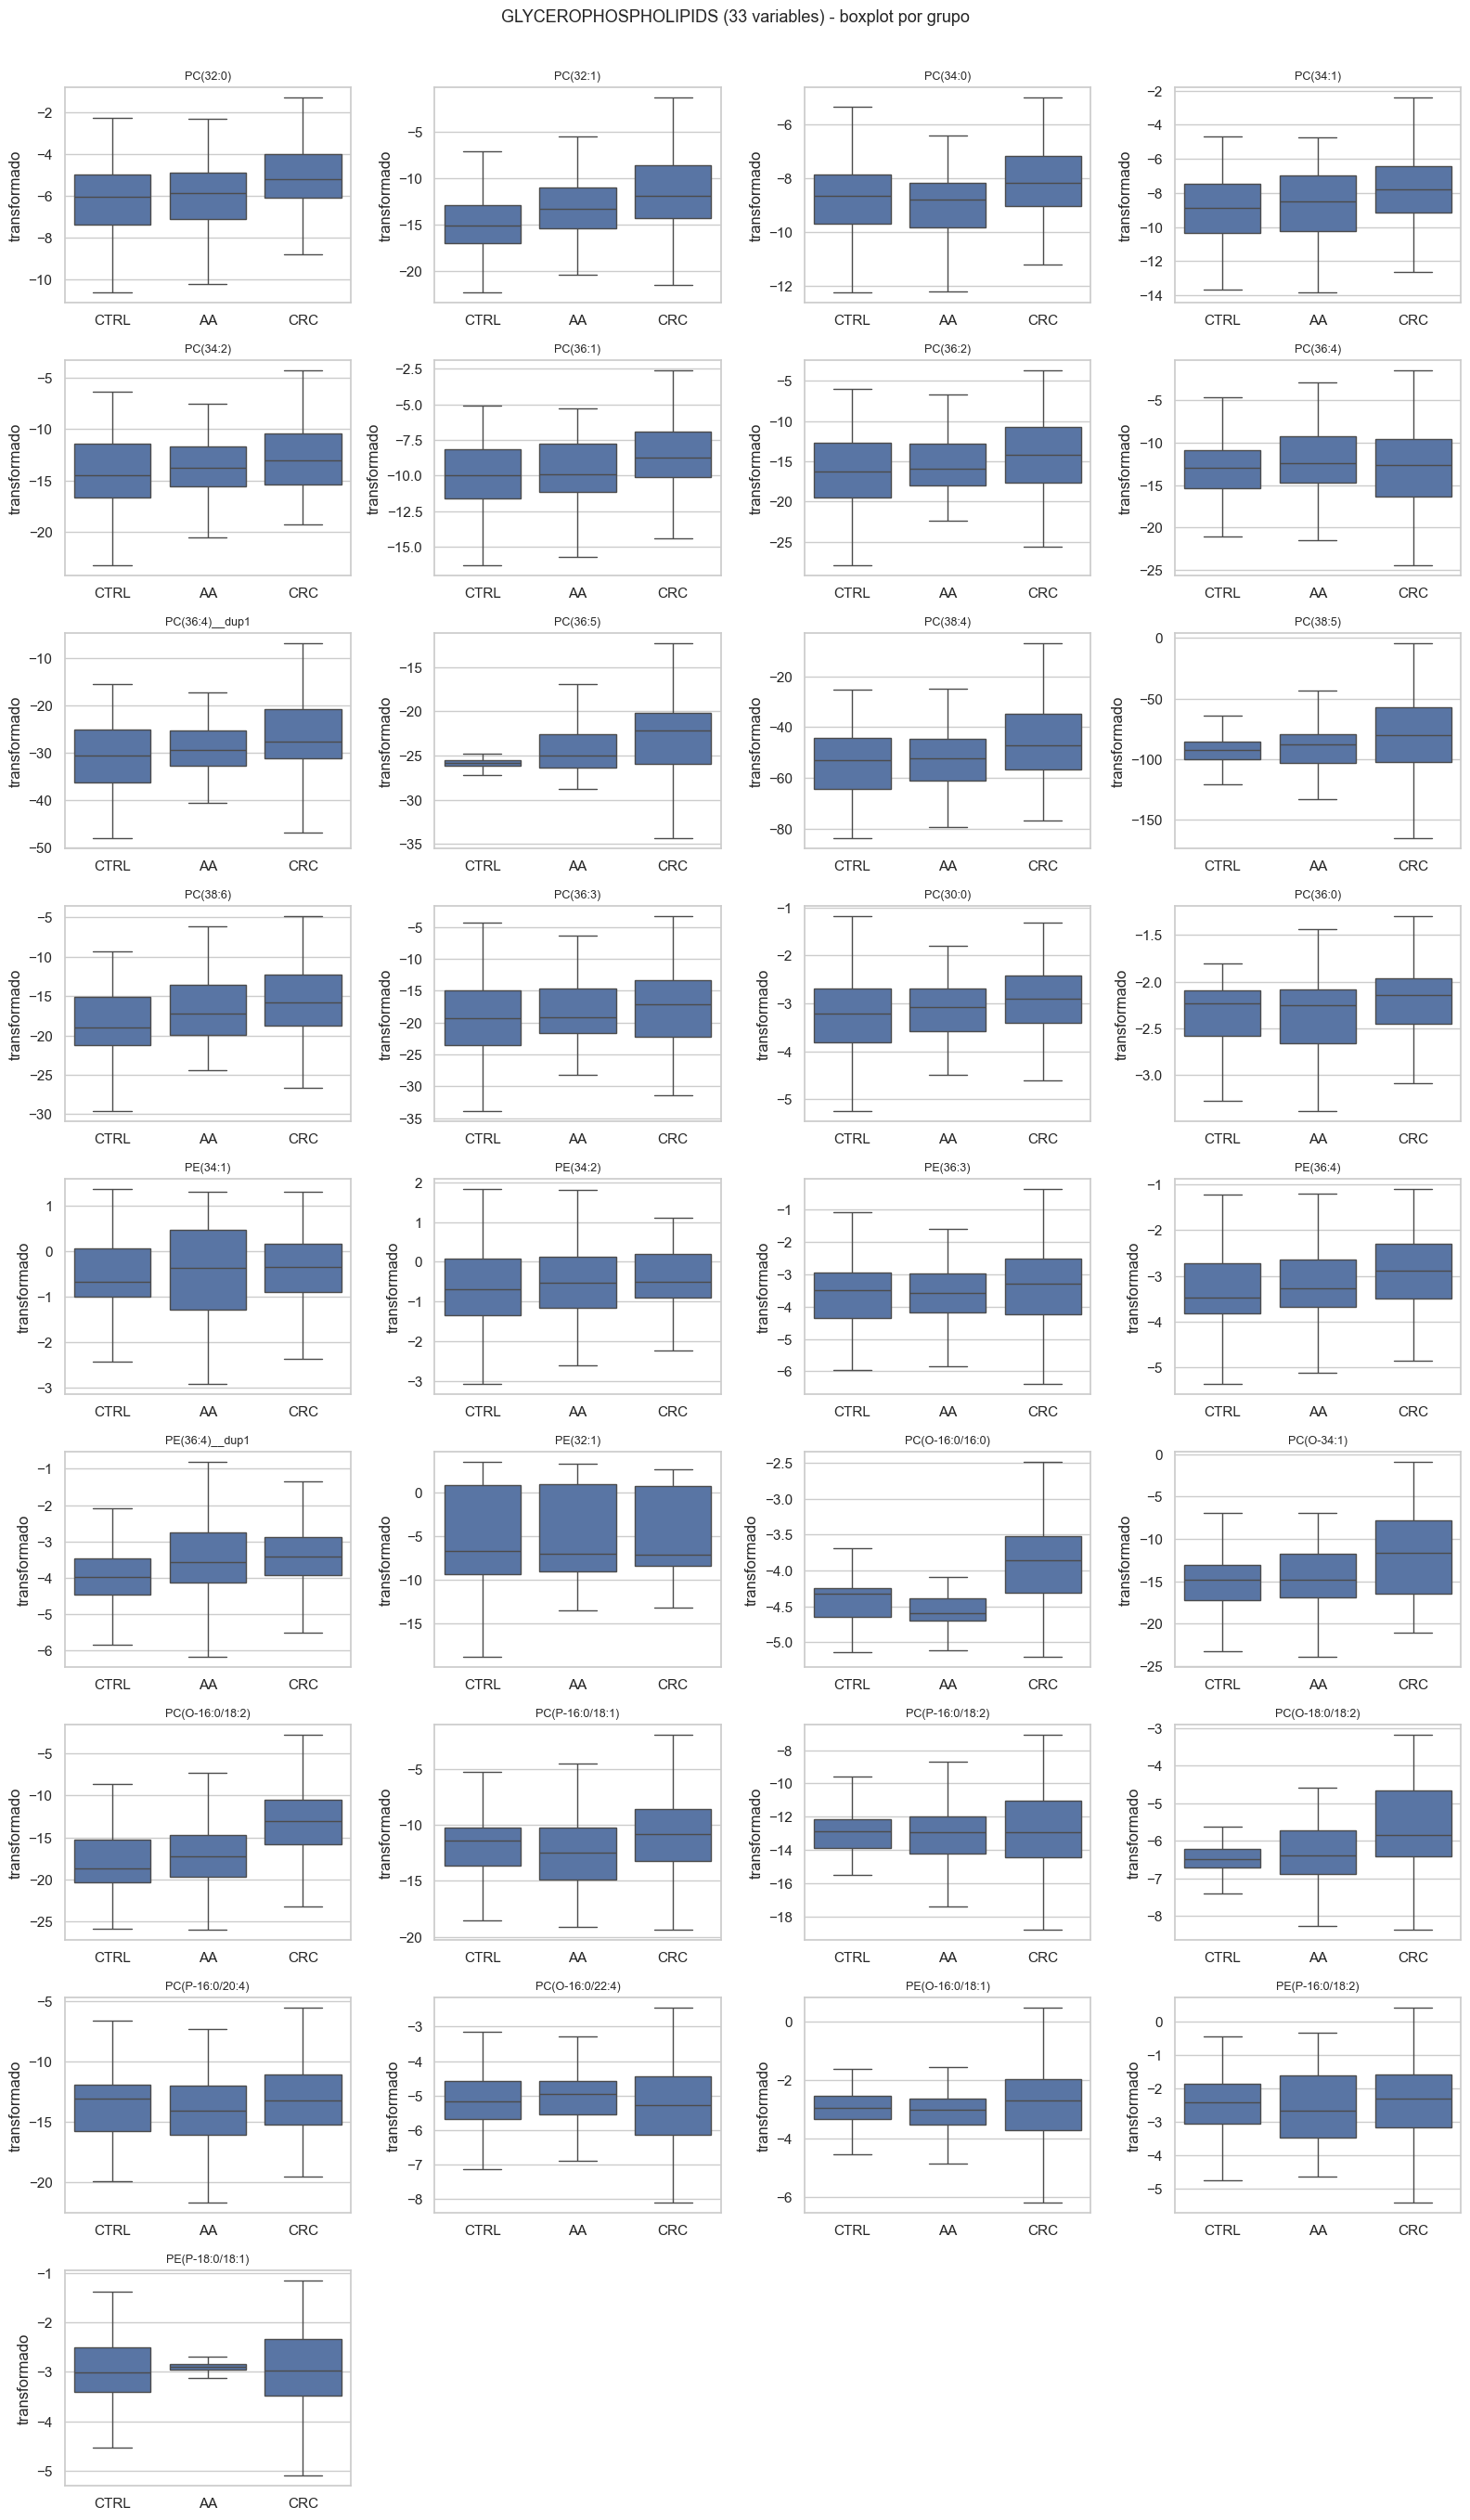

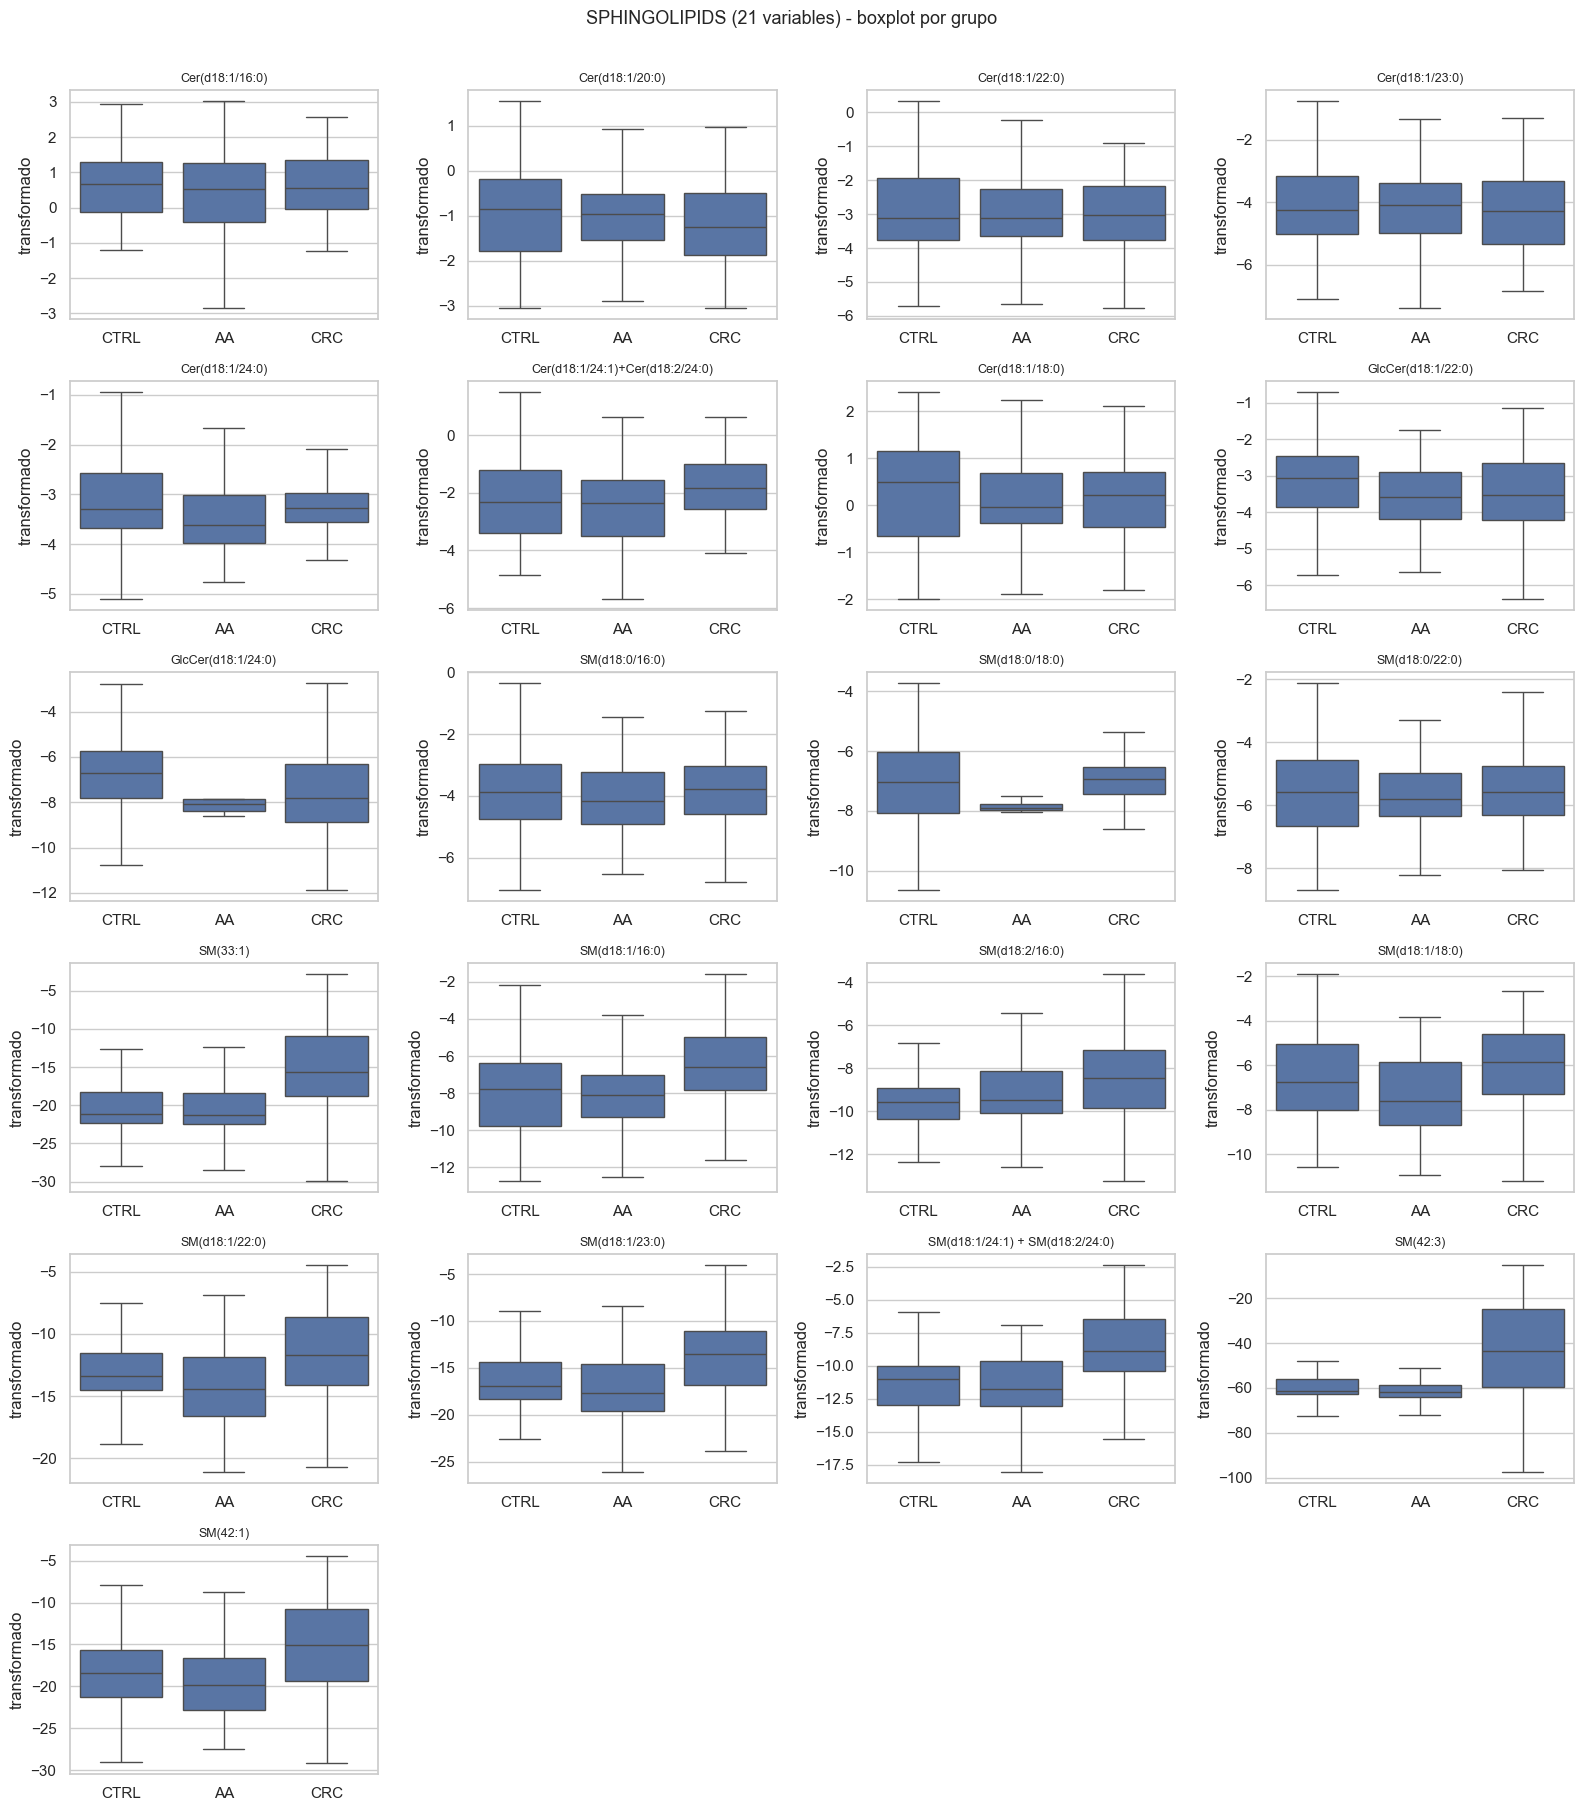

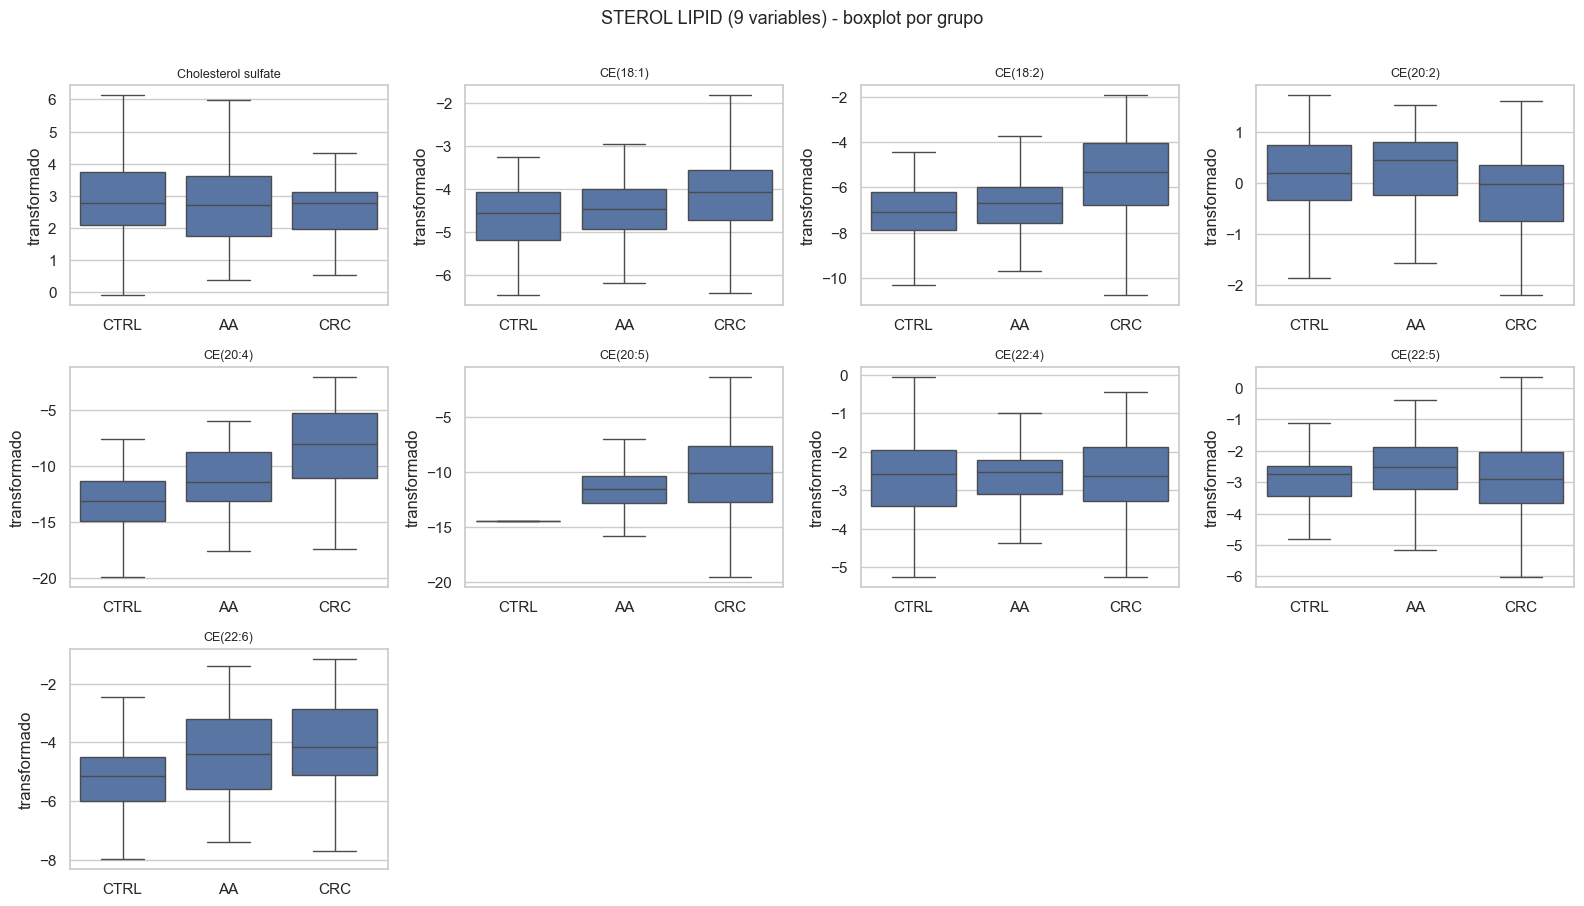

In [38]:
# 3.6.1 Boxplots por familia
import math

families_to_plot = sorted(feature_metadata['family'].unique())

for fam in families_to_plot:
    cols_fam = feature_metadata.loc[feature_metadata['family'] == fam, 'column'].tolist()
    cols_fam = [c for c in cols_fam if c in lipids_kept]
    
    if len(cols_fam) == 0:
        continue
    
    n = len(cols_fam)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
    
    for i, col in enumerate(cols_fam):
        sns.boxplot(data=data_t, x='group', y=col, ax=axes[i],
                    order=['CTRL', 'AA', 'CRC'], showfliers=False)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('transformado')
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f'{fam} ({len(cols_fam)} variables) - boxplot por grupo', y=1.005, fontsize=13)
    plt.tight_layout()
    plt.show()


**Lectura del resultado (cuatro figuras, una por familia):**

Esta visualización es **exploratoria**: muestra cómo se distribuye cada lípido por grupo en escala Box-Cox, sin afirmaciones inferenciales. La cuantificación rigurosa del poder discriminativo se realiza en el Paso 4 mediante selección supervisada de variables.

- **GLYCEROLIPIDS** (60 variables) — figura más extensa, dominada por TGs y DGs. Visualmente se aprecian numerosos TGs cuyas cajas por grupo presentan desplazamientos relativos modestos pero perceptibles.
- **GLYCEROPHOSPHOLIPIDS** (35 variables) — combinación de PCs y PEs (incluyendo plasmalógenos `O-` y `P-`). Patrón heterogéneo: algunos PCs muestran diferencias entre grupos, otros tienen cajas superpuestas.
- **SPHINGOLIPIDS** (23 variables) — múltiples SMs exhiben patrones visualmente diferenciables entre grupos, particularmente las esfingomielinas saturadas.
- **STEROL LIPID** (9 variables) — la familia con menor número de variables; incluye CEs y cholesterol sulfate. Algunos CEs muestran cajas con desplazamiento entre grupos; otros, sin diferencias visibles.
- Cada subpanel emplea **escala Box-Cox** en el eje Y.
- Los atípicos están **ocultos por diseño** (`showfliers=False`) para favorecer la comparabilidad de las cajas; el análisis de atípicos se realizó previamente en 3.5.

> Esta sección sirve como vista panorámica previa al Paso 4; la decisión de qué variables entran al modelo se basa en los scores de información mutua, no en lectura visual de boxplots.


---

> **Fin del Paso 3.** Tenemos `data_t` (211 muestras × 122 lípidos imputados y transformados con Box-Cox), validación cuantitativa de la imputación, identificación de outliers por regla IQR y boxplots por familia. La matriz está lista para selección de variables y análisis multivariado.


# Paso 4 — Selección de variables para el modelo predictivo

El objetivo de este paso es identificar el subconjunto de variables con mayor poder discriminativo para distinguir las tres clases del problema (CTRL / AA / CRC). Esto alimenta la fase de modelado del Avance 2.

Se aplican dos selectores supervisados, uno por cada tipo de variable:

| Tipo de variable | Selector | Función | Por qué |
|---|---|---|---|
| Categórica (one-hot) | `SelectKBest(chi2)` | Test χ² de independencia entre la variable codificada y el target | Estándar para variables nominales; requiere valores no negativos, garantizado por one-hot. |
| Numérica continua | `SelectKBest(mutual_info_classif)` | Información mutua estimada con vecinos más cercanos (Kraskov–Stögbauer–Grassberger) | No asume distribución específica; captura relaciones no lineales; robusto a las colas pesadas residuales tras Box-Cox. |

> **Diferencia clave con el análisis inferencial clásico:** aquí no se busca demostrar que una variable "es significativa" bajo un test de hipótesis, sino *rankearlas* por su utilidad para predecir el target. El criterio es predictivo, no probatorio.


## 4.1 Selección de variables categóricas (χ² sobre one-hot encoding)

In [39]:
# 4.1 Codificación one-hot de variables categóricas clínicas y aplicación de SelectKBest(chi2)
categorical_features = ['gender', 'fob']
X_categorical = pd.get_dummies(data_t[categorical_features], drop_first=True).astype(float)
y_target = data_t['group']

print(f'Variables categóricas originales: {categorical_features}')
print(f'Variables tras one-hot encoding (drop_first=True): {X_categorical.columns.tolist()}')
print(f'Matriz X_categorical shape: {X_categorical.shape}')

chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(X_categorical, y_target)

chi2_results = pd.DataFrame({
    'feature': X_categorical.columns,
    'chi2_score': chi2_selector.scores_,
    'p_value': chi2_selector.pvalues_
}).sort_values('chi2_score', ascending=False).reset_index(drop=True)

print(f'\nRanking χ² de variables categóricas (target = group):')
display(chi2_results.style.format({'chi2_score': '{:.2f}', 'p_value': '{:.2e}'}))


Variables categóricas originales: ['gender', 'fob']
Variables tras one-hot encoding (drop_first=True): ['gender_Male', 'fob_YES']
Matriz X_categorical shape: (211, 2)

Ranking χ² de variables categóricas (target = group):


,feature,chi2_score,p_value
0,fob_YES,23.90,6.46e-06
1,gender_Male,2.85,2.41e-01


**Lectura del resultado:**

- **`fob_YES` emerge como muy discriminativo** (χ² = 23.90, p = 6.5 × 10⁻⁶): la presencia de sangre oculta en heces se distribuye fuertemente entre grupos (gradiente CTRL → AA → CRC esperado biológicamente, ya cuantificado en el resumen del Paso 2). Este score confirma cuantitativamente lo observado en el análisis univariante.
- **`gender_Male` no es discriminativo** (χ² = 2.85, p = 0.24): el sexo no aporta separación entre las tres clases en este dataset. Puede mantenerse como control en el modelo, pero no será una variable predictora dominante.
- Con sólo dos variables categóricas binarias, este selector es modesto en escala pero establece el pipeline coherente con el de variables numéricas (4.2). Una de las dos categóricas (`fob_YES`) entra al modelo final con alta confianza.


## 4.2 Selección de variables numéricas (información mutua)

In [40]:
# 4.2 Aplicar SelectKBest(mutual_info_classif) sobre clínicas numéricas + 122 lípidos Box-Cox
numerical_features = ['age', 'fit_ug_g'] + lipids_kept
X_numerical = data_t[numerical_features].values

mi_scores = mutual_info_classif(X_numerical, y_target, random_state=42, discrete_features=False)

family_lookup = dict(zip(feature_metadata['column'], feature_metadata['family']))
def feature_family(name):
    if name in ('age', 'fit_ug_g'):
        return 'clinical'
    return family_lookup.get(name, 'unknown')

mi_results = pd.DataFrame({
    'feature': numerical_features,
    'mi_score': mi_scores,
    'feature_type': ['clínica' if f in ('age', 'fit_ug_g') else 'lípido' for f in numerical_features],
    'family': [feature_family(f) for f in numerical_features]
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print(f'Total variables numéricas evaluadas: {len(numerical_features)} (2 clínicas + {len(lipids_kept)} lípidos)')
print(f'\nTop 20 variables por MI score:')
display(mi_results.head(20).style.format({'mi_score': '{:.4f}'}))

print(f'\nResumen por tipo de variable:')
display(mi_results.groupby('feature_type')['mi_score'].agg(['count', 'mean', 'median', 'max']).round(4))

print(f'\nResumen por familia lipídica:')
fam_summary = mi_results[mi_results['feature_type'] == 'lípido'].groupby('family')['mi_score'].agg(['count', 'mean', 'median', 'max']).round(4).sort_values('mean', ascending=False)
display(fam_summary)


Total variables numéricas evaluadas: 124 (2 clínicas + 122 lípidos)

Top 20 variables por MI score:


,feature,mi_score,feature_type,family
0,GlcCer(d18:1/24:0),0.3815,lípido,SPHINGOLIPIDS
1,PE(P-18:0/18:1),0.3599,lípido,GLYCEROPHOSPHOLIPIDS
2,TG(51:4),0.3534,lípido,GLYCEROLIPIDS
3,TG(53:0),0.3531,lípido,GLYCEROLIPIDS
4,SM(d18:0/18:0),0.3398,lípido,SPHINGOLIPIDS
5,PC(36:5),0.3338,lípido,GLYCEROPHOSPHOLIPIDS
6,Cer(d18:1/24:0),0.3182,lípido,SPHINGOLIPIDS
7,PC(O-16:0/16:0),0.3174,lípido,GLYCEROPHOSPHOLIPIDS
8,PC(O-16:0/22:4),0.3173,lípido,GLYCEROPHOSPHOLIPIDS
9,SM(42:3),0.3122,lípido,SPHINGOLIPIDS



Resumen por tipo de variable:


,count,mean,median,max
feature_type,,,,
clínica,2,0.1519,0.1519,0.1702
lípido,122,0.0981,0.0661,0.3815



Resumen por familia lipídica:


,count,mean,median,max
family,,,,
SPHINGOLIPIDS,21,0.1508,0.1490,0.3815
GLYCEROPHOSPHOLIPIDS,33,0.1253,0.1118,0.3599
STEROL LIPID,9,0.1170,0.0917,0.2984
GLYCEROLIPIDS,59,0.0613,0.0390,0.3534


**Lectura del resultado:**

- **Rango global de MI**: las 124 variables numéricas se distribuyen entre MI = 0 (no informativa) y MI = 0.38 (la más informativa, `GlcCer(d18:1/24:0)`). La variable clínica `fit_ug_g` alcanza MI = 0.17, ubicándose entre las más informativas del conjunto completo y validando que el estándar clínico actual contiene señal real.
- **Top 5 numéricas**: GlcCer(d18:1/24:0) (sphingolipid), PE(P-18:0/18:1) (plasmalógeno), TG(51:4), TG(53:0), SM(d18:0/18:0). Mezcla de tres familias diferentes — la señal predictiva no se concentra en una sola clase de lípidos.
- **Ranking por familia (MI promedio)**:
  1. **SPHINGOLIPIDS**: 0.151 — familia más informativa en promedio (incluye SMs y ceramidas/glucosilceramidas).
  2. **GLYCEROPHOSPHOLIPIDS**: 0.125 — segunda; agrupa PCs, PEs y plasmalógenos.
  3. **STEROL LIPID**: 0.117 — pequeña pero consistente; sus 9 variables (sobre todo CEs) mantienen MI moderada.
  4. **GLYCEROLIPIDS**: 0.061 — la más numerosa (59 variables) pero menos informativa en promedio; contiene muchos TGs con MI cercana a 0.
- **Implicación**: las familias `SPHINGOLIPIDS` y `GLYCEROPHOSPHOLIPIDS` son las candidatas más fuertes para feature engineering agregado (medias por familia, ratios entre familias) en el Avance 2.


## 4.3 Ranking consolidado y visualización

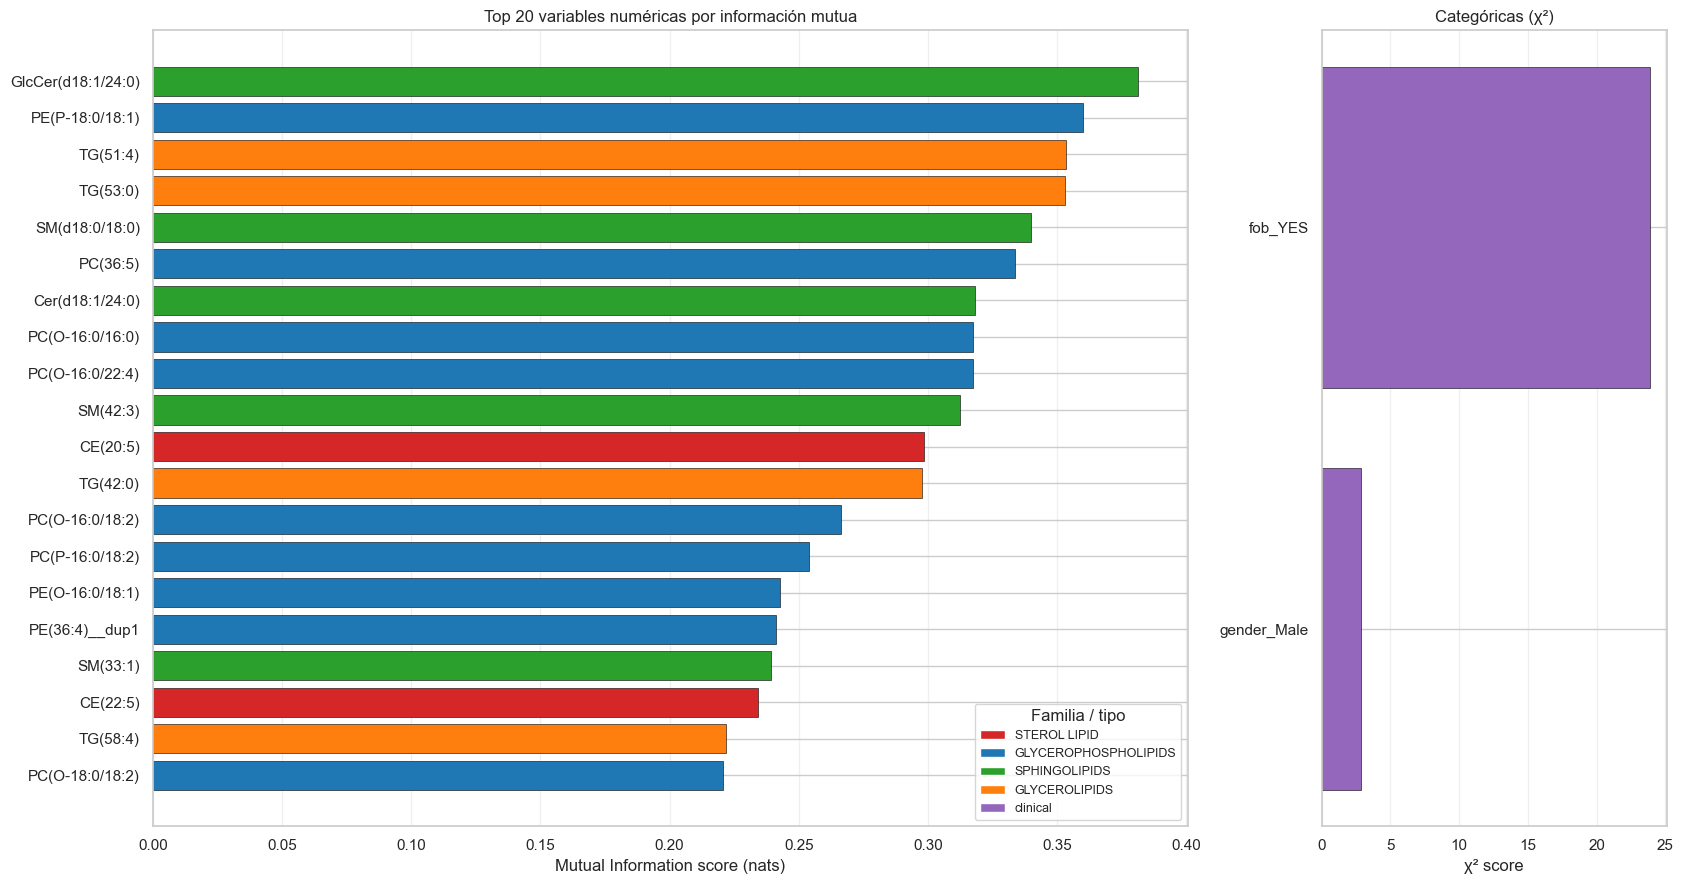

=== Variables candidatas a entrar al modelo predictivo ===

Top 15 numéricas (por MI):


,feature,feature_type,family,mi_score
0,GlcCer(d18:1/24:0),lípido,SPHINGOLIPIDS,0.3815
1,PE(P-18:0/18:1),lípido,GLYCEROPHOSPHOLIPIDS,0.3599
2,TG(51:4),lípido,GLYCEROLIPIDS,0.3534
3,TG(53:0),lípido,GLYCEROLIPIDS,0.3531
4,SM(d18:0/18:0),lípido,SPHINGOLIPIDS,0.3398
5,PC(36:5),lípido,GLYCEROPHOSPHOLIPIDS,0.3338
6,Cer(d18:1/24:0),lípido,SPHINGOLIPIDS,0.3182
7,PC(O-16:0/16:0),lípido,GLYCEROPHOSPHOLIPIDS,0.3174
8,PC(O-16:0/22:4),lípido,GLYCEROPHOSPHOLIPIDS,0.3173
9,SM(42:3),lípido,SPHINGOLIPIDS,0.3122



Categóricas one-hot (por χ²):


,feature,feature_type,family,chi2_score
0,fob_YES,categórica,clinical,23.90
1,gender_Male,categórica,clinical,2.85


In [41]:
# 4.3 Visualización conjunta de scores: numericas (MI) y categoricas (chi2)
fig, axes = plt.subplots(1, 2, figsize=(17, 9), gridspec_kw={'width_ratios': [3, 1]})

# --- Panel izquierdo: top 20 variables numéricas por MI ---
top_num = mi_results.head(20).iloc[::-1]  # invertir para barh top-down
family_colors = {
    'STEROL LIPID':         '#d62728',
    'GLYCEROPHOSPHOLIPIDS': '#1f77b4',
    'SPHINGOLIPIDS':        '#2ca02c',
    'GLYCEROLIPIDS':        '#ff7f0e',
    'clinical':             '#9467bd',
}
bar_colors = [family_colors.get(f, '#888888') for f in top_num['family']]
axes[0].barh(top_num['feature'], top_num['mi_score'], color=bar_colors, edgecolor='black', linewidth=0.4)
axes[0].set_xlabel('Mutual Information score (nats)')
axes[0].set_title('Top 20 variables numéricas por información mutua')
axes[0].grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=lab) for lab, c in family_colors.items()]
axes[0].legend(handles=legend_elems, loc='lower right', fontsize=9, title='Familia / tipo')

# --- Panel derecho: categóricas por chi2 ---
chi2_sorted = chi2_results.iloc[::-1]
axes[1].barh(chi2_sorted['feature'], chi2_sorted['chi2_score'], color='#9467bd', edgecolor='black', linewidth=0.4)
axes[1].set_xlabel('χ² score')
axes[1].set_title('Categóricas (χ²)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Lista consolidada de candidatos al modelo
top_candidates_num = mi_results.head(15)[['feature', 'feature_type', 'family', 'mi_score']]
top_candidates_cat = chi2_results.assign(feature_type='categórica', family='clinical')[['feature', 'feature_type', 'family', 'chi2_score']]

print('=== Variables candidatas a entrar al modelo predictivo ===')
print(f'\nTop 15 numéricas (por MI):')
display(top_candidates_num.style.format({'mi_score': '{:.4f}'}))
print(f'\nCategóricas one-hot (por χ²):')
display(top_candidates_cat.style.format({'chi2_score': '{:.2f}'}))


**Lectura del resultado:**

- **Diversidad en el top 20**: el panel izquierdo (top 20 numéricas por MI) muestra colores mezclados — `SPHINGOLIPIDS` (verde) y `GLYCEROPHOSPHOLIPIDS` (azul) dominan, con presencia de `GLYCEROLIPIDS` (naranja, cuatro TGs) y dos representantes de `STEROL LIPID` (rojo, `CE(20:5)` y `CE(22:5)`). Ningún color concentra el top, lo que sugiere que un modelo con buena cobertura debe incluir variables de las cuatro familias en lugar de concentrarse en una.
- **`PE(36:4)__dup1` aparece en el top 20** con MI ≈ 0.24: la entrada duplicada documentada en el diccionario muestra poder predictivo real. La decisión de conservarla (en lugar de eliminarla como ruido) queda validada empíricamente.
- **Categóricas (panel derecho)**: `fob_YES` con χ² muy superior a `gender_Male` reproduce el ranking del 4.1.
- **Conjunto recomendado para el Avance 2**: las top 15 numéricas por MI + las categóricas one-hot del 4.1 (en particular `fob_YES`) constituyen ~17 features candidatas iniciales. Validación cruzada determinará el subconjunto óptimo y si conviene incluir más variables (top 20-30) o reducir.


## 4.4 Interpretación predictiva

**Lectura del resultado:**

**Lo que el ranking nos dice sobre las variables:**

- **`fob_YES` (FOB positivo) es la variable clínica más discriminativa** entre las categóricas (χ² = 23.9, p = 6.5×10⁻⁶). Coherente con la práctica clínica: FOB es uno de los marcadores rutinarios para colorrectal. Entra al modelo con alta prioridad.
- **`fit_ug_g` (test inmunoquímico fecal) alcanza MI = 0.170**, ubicándose entre las 5 variables numéricas más informativas. Esto cuantifica el aporte del **estándar clínico actual** y será la línea base contra la que el modelo de lipidómica debe demostrar valor incremental.
- **Las familias `SPHINGOLIPIDS` y `GLYCEROPHOSPHOLIPIDS` concentran la señal predictiva de la lipidómica** (MI promedio 0.15 y 0.13 respectivamente). Las 59 variables `GLYCEROLIPIDS` aportan en promedio menos información (0.06) pero contienen 4 entradas en el top 20 (`TG(51:4)`, `TG(53:0)`, `TG(42:0)`, `TG(58:4)`) — su distribución es bimodal: pocas muy informativas y muchas irrelevantes.

**Lo que el ranking sugiere sobre el problema:**

- La diversidad de familias en el top 20 indica que **el problema multiclase (CTRL / AA / CRC) requiere combinar señales de múltiples sistemas lipídicos** — ninguna variable individual concentra toda la señal predictiva (lo que es coherente con la complejidad esperable de un problema multiclase frente a comparaciones binarias).
- La presencia de plasmalógenos (`PE(P-...)`, `PC(O-...)`, `PC(P-...)`) entre las variables top valida su inclusión como features estructurales agregadas (`plasmalogen_frac`) en la sección 5.3.
- El que ninguna variable supere MI > 0.4 (rango teórico hasta ~log(3) ≈ 1.1 en clasificación de 3 clases) implica que **ninguna variable individual basta para discriminar** — el modelo necesitará combinar múltiples features.

**Decisiones para el Avance 2 (fase de modelado):**

0. **Pipeline 0 — baseline con TODAS las variables (referencia obligatoria)**: entrenar el modelo con las 124 numéricas + 2 categóricas one-hot, **sin filtrar**. Este baseline establece el **límite empírico de desempeño** cuando se usa toda la información disponible, y permite cuantificar objetivamente el impacto (positivo o negativo) de cada paso de selección de variables. Sin esta referencia no es posible afirmar si los pipelines reducidos pierden, igualan o superan al modelo completo en desempeño, estabilidad o capacidad de generalización.
1. **Pipeline base**: top 15 lípidos por MI + `fob_YES` + `gender_Male` → ~17 features iniciales.
2. **Pipeline ampliado**: añadir `age` y `fit_ug_g` para cuantificar el aporte incremental de la lipidómica sobre el estándar clínico.
3. **Pipeline reducido**: validar con top 5 + top 10 + top 15 vía cross-validation para encontrar el punto óptimo entre parsimonia y rendimiento.
4. **Features estructurales** (Paso 5.3): evaluar si la fracción de plasmalógenos y agregados por familia agregan valor sobre los lípidos individuales seleccionados.

> **Nota metodológica**: este ranking refleja **utilidad predictiva en este dataset bajo el preprocesamiento aplicado**. No constituye afirmación causal ni biomédica. La interpretación biológica de por qué `GlcCer(d18:1/24:0)` o los plasmalógenos son informativos en el contexto de cáncer colorrectal corresponde al equipo clínico, en discusión con especialistas en lipidómica.


---

> **Fin del Paso 4.** Se obtuvieron rankings supervisados de las dos categorías de variables: χ² sobre clínicas categóricas codificadas, e información mutua sobre clínicas numéricas y los 122 lípidos Box-Cox. Estos rankings alimentan directamente la selección de features del modelo en el Avance 2.


# Paso 5 — Estructura multivariada

Hasta el presente módulo se analizaron los lípidos individualmente. El presente bloque responde: **¿cómo se relacionan los lípidos entre sí?** y **¿se separan los grupos en el espacio multivariado?**

### Estructura del módulo

1. **Correlación agrupada por familia** — mapa de calor mediante clustermap, contraste cuantitativo intra/inter familia.
2. **PCA** (análisis no supervisado) — diagrama de codo, scatter con elipses al 95%, visualización multivariada incorporando `size=age` y `style=gender`, biplot de cargas.
3. **Atributos estructurales derivados** (aporte diferencial al estudio original) — longitud media de cadena, índice de insaturación y proporción de plasmalógenos, evaluados con `mutual_info_classif` y contrastados contra el ranking del Paso 4.

### Recordatorio teórico

PCA es un método **no supervisado**: no "conoce" los grupos del target y proyecta los datos en las direcciones de máxima varianza. Si los grupos llegaran a separarse en las primeras componentes, sería porque la variabilidad biológica entre grupos domina sobre otras fuentes de variación.

La separación supervisada — guiada explícitamente por el target — ya se cuantificó en el Paso 4 mediante `SelectKBest` con `chi2` y `mutual_info_classif`. El Paso 5 complementa esa lectura caracterizando la **estructura conjunta** de los lípidos (correlación, varianza compartida) más allá del comportamiento individual.


## 5.1 Mapa de calor de correlación agrupado por familia

Se calcula la matriz de correlación entre los 122 lípidos (sobre datos transformados con Box-Cox) y se visualiza mediante un **clustermap** con anotación de familia en los márgenes. Esta representación permite identificar:

- Bloques de **alta correlación intra-familia** (lípidos de la misma familia tienden a covariar).
- **Correlaciones cruzadas** entre familias (señal biológica de rutas metabólicas conectadas).


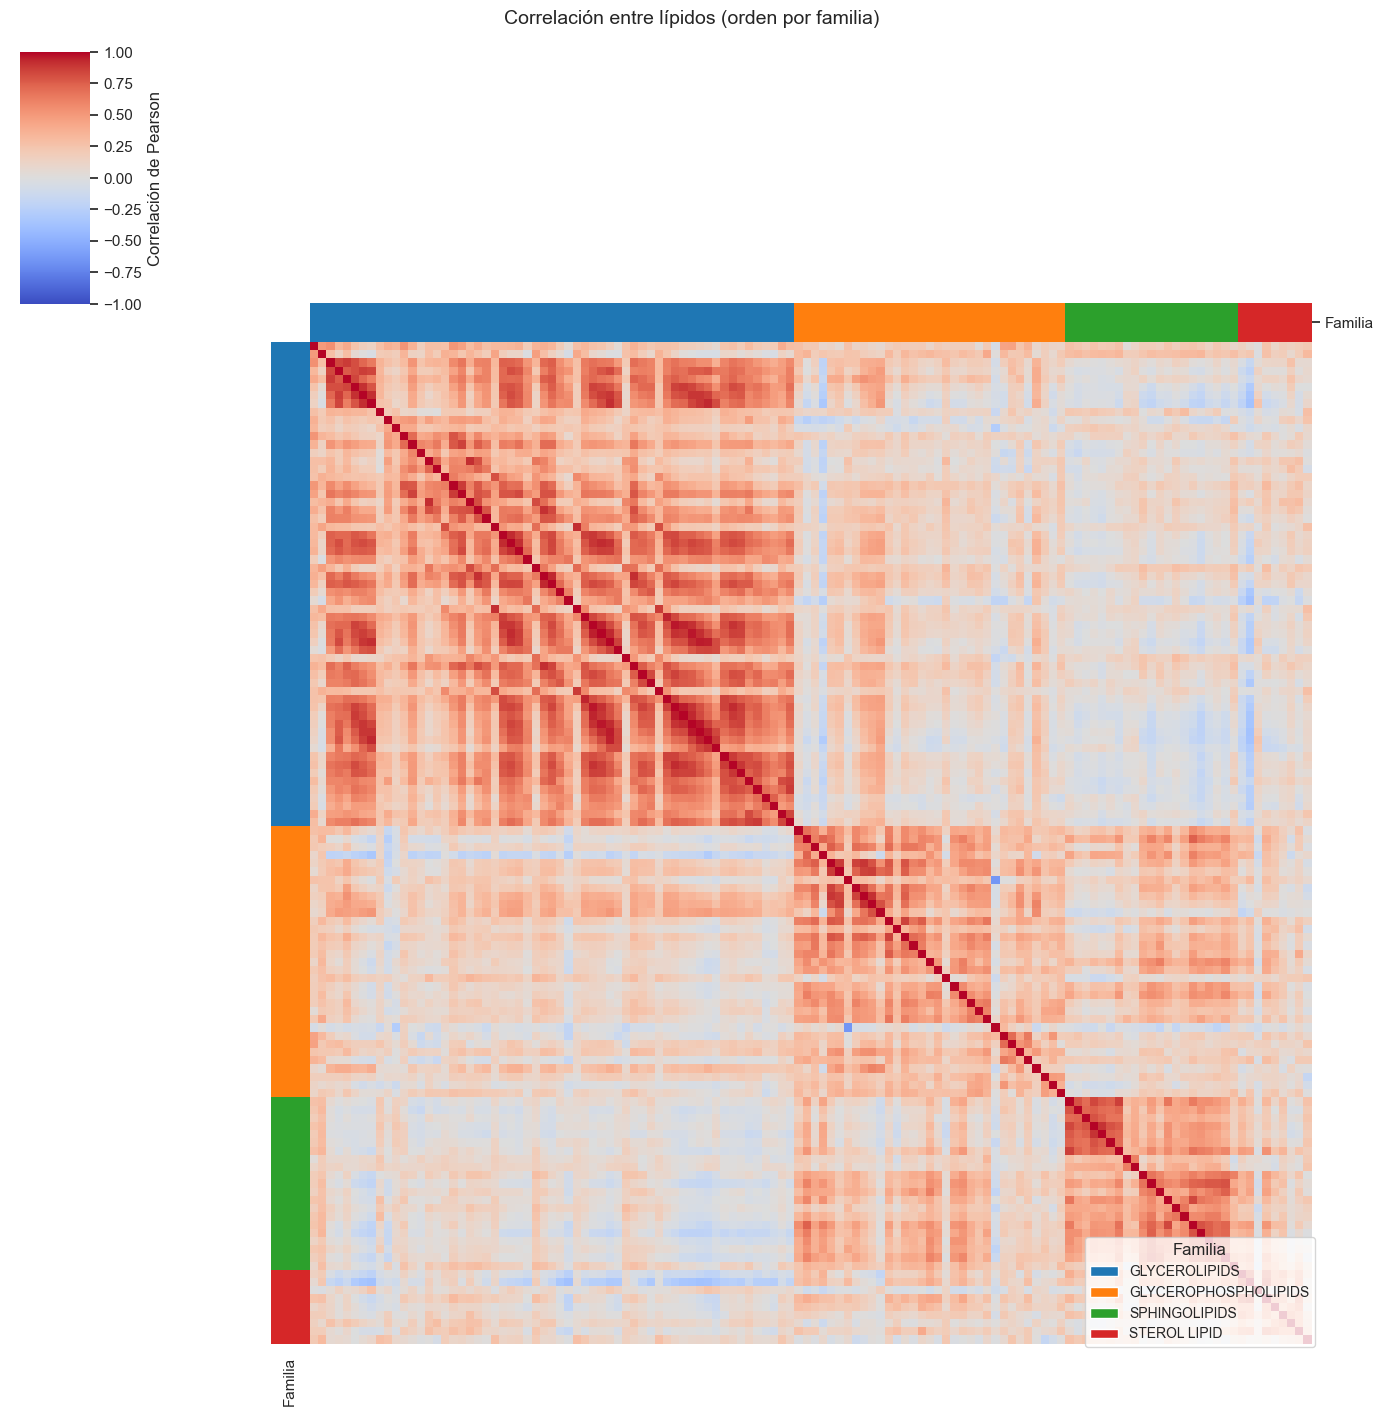

In [42]:
# 5.1.1 Heatmap de correlación, lípidos ordenados por familia
family_map = feature_metadata.set_index('column')['family'].to_dict()
fam_of_lipid = [family_map[c] for c in lipids_kept]

# Ordenar lípidos por familia (alfabético dentro)
order_idx = sorted(range(len(lipids_kept)),
 key=lambda i: (fam_of_lipid[i], lipids_kept[i]))
lipids_sorted = [lipids_kept[i] for i in order_idx]
fam_sorted = [fam_of_lipid[i] for i in order_idx]

# Matriz de correlación sobre datos transformados
corr_matrix = data_t[lipids_sorted].corr()

# Anotación de familia (colores en márgenes)
family_palette = {
 'GLYCEROLIPIDS': '#1f77b4',
 'GLYCEROPHOSPHOLIPIDS':'#ff7f0e',
 'SPHINGOLIPIDS': '#2ca02c',
 'STEROL LIPID': '#d62728'
}
row_colors = pd.Series([family_palette[f] for f in fam_sorted],
 index=lipids_sorted, name='Familia')

g = sns.clustermap(
 corr_matrix,
 cmap='coolwarm', center=0, vmin=-1, vmax=1,
 row_colors=row_colors, col_colors=row_colors,
 row_cluster=False, col_cluster=False,
 figsize=(14, 14),
 xticklabels=False, yticklabels=False,
 cbar_kws={'label': 'Correlación de Pearson'}
)
g.fig.suptitle('Correlación entre lípidos (orden por familia)', y=1.01, fontsize=14)

# Leyenda manual de familias
from matplotlib.patches import Patch
handles = [Patch(facecolor=color, label=fam) for fam, color in family_palette.items()]
g.fig.legend(handles=handles, loc='lower right', bbox_to_anchor=(0.95, 0.05),
 title='Familia', fontsize=10)
plt.show()


**Lectura del resultado (clustermap 122 × 122):**

- Se observan **cuatro bloques claros sobre la diagonal**, uno por familia, claramente delimitados por las anotaciones de color en los márgenes:
  - **GLYCEROLIPIDS** (azul, 60 variables) — el bloque de mayor extensión, con correlaciones predominantemente positivas (tonos rojizos) y un núcleo de TGs particularmente correlacionados (zona central del bloque con tonos rojos intensos).
  - **GLYCEROPHOSPHOLIPIDS** (naranja, 35 variables) — bloque intermedio con sub-bloques visibles (PCs, PEs, plasmalógenos).
  - **SPHINGOLIPIDS** (verde, 23 variables) — bloque cohesivo y compacto con correlaciones positivas internas marcadas.
  - **STEROL LIPID** (rojo, 9 variables) — bloque reducido pero con correlación intra-grupo claramente discernible.
- **Las regiones off-diagonal** (interacciones entre familias) exhiben tonos predominantemente blancos a azul claro, evidenciando correlaciones modestas a despreciables.
- Se identifica adicionalmente cierta correlación moderada entre GLYCEROLIPIDS y GLYCEROPHOSPHOLIPIDS (zona naranja claro), consistente con rutas biosintéticas compartidas entre ambas familias.
- **Interpretación:** la organización modular en bloques por familia confirma visualmente lo cuantificado en 5.1.2: cada familia constituye un módulo metabólico relativamente independiente del resto.


In [43]:
# 5.1.2 Resumen numérico: correlación intra-familia vs entre familias
intra_corrs = []
inter_corrs = []
for i, c1 in enumerate(lipids_kept):
    for j, c2 in enumerate(lipids_kept):
        if j <= i:
            continue
        corr = data_t[c1].corr(data_t[c2])
        if family_map[c1] == family_map[c2]:
            intra_corrs.append(corr)
        else:
            inter_corrs.append(corr)

print(f'Correlación INTRA-familia (mismas familias):')
print(f'  n pares = {len(intra_corrs)}, mediana = {np.median(intra_corrs):.3f}, media = {np.mean(intra_corrs):.3f}')
print(f'\nCorrelación INTER-familia (familias distintas):')
print(f'  n pares = {len(inter_corrs)}, mediana = {np.median(inter_corrs):.3f}, media = {np.mean(inter_corrs):.3f}')

print(f'\nPares con |r| > 0.9: {(np.abs(np.array(intra_corrs + inter_corrs)) > 0.9).sum()}')
print(f'Pares con |r| > 0.8: {(np.abs(np.array(intra_corrs + inter_corrs)) > 0.8).sum()}')


Correlación INTRA-familia (mismas familias):


  n pares = 2485, mediana = 0.432, media = 0.444

Correlación INTER-familia (familias distintas):


  n pares = 4896, mediana = 0.093, media = 0.105

Pares con |r| > 0.9: 34
Pares con |r| > 0.8: 166


**Lectura del resultado:**

| Métrica | Intra-familia | Inter-familia |
|---|---|---|
| n pares | 2485 | 4896 |
| Mediana \|r\| | **0.432** | **0.093** |
| Media \|r\| | 0.444 | 0.105 |

- **Contraste claro:** la correlación dentro de cada familia es aproximadamente cinco veces superior (0.432) a la observada entre familias (0.093). Este número cuantifica el efecto visual del clustermap.
- **34 pares con \|r\| > 0.9** y **166 pares con \|r\| > 0.8** — multicolinealidad sustancial pero controlada (no extrema).

**Implicaciones metodológicas para el Avance 2:**

1. **Modelos lineales** con regularización (Logistic Regression L1/L2, Elastic Net) deben preferirse o complementarse con métodos robustos a la colinealidad. La regularización L2 estabiliza coeficientes en presencia de variables correlacionadas pero no las distingue; L1 puede colapsar grupos correlacionados eligiendo arbitrariamente un representante.
2. **Importancia de variables por permutación o SHAP** debe preferirse sobre `feature_importances_` ingenuo en Random Forest — éste distribuye la importancia entre features correlacionadas, subestimando el valor real de cada una.
3. **Selección de variables**: al presentar el ranking del Paso 4, conviene considerar que cinco TGs altamente correlacionados aparecen agrupados — al estar midiendo "lo mismo" desde el punto de vista metabólico, es preferible incluir un representante por clúster en la fase de interpretación, con la nota correspondiente.


## 5.2 Análisis de Componentes Principales (PCA)

PCA proyecta los 122 lípidos en componentes que maximizan la varianza explicada. Procedimiento:

1. Estandarización mediante `StandardScaler` — necesaria, dado que PCA es sensible a la escala.
2. PCA con diez componentes para construir el diagrama de codo.
3. Visualización de PC1 vs PC2 con elipses de confianza al 95% por grupo.
4. Visualización multivariada combinada: PC1 vs PC2 con `size=age` y `style=gender`.
5. Biplot con los 15 lípidos con mayor magnitud de carga en PC1 + PC2.


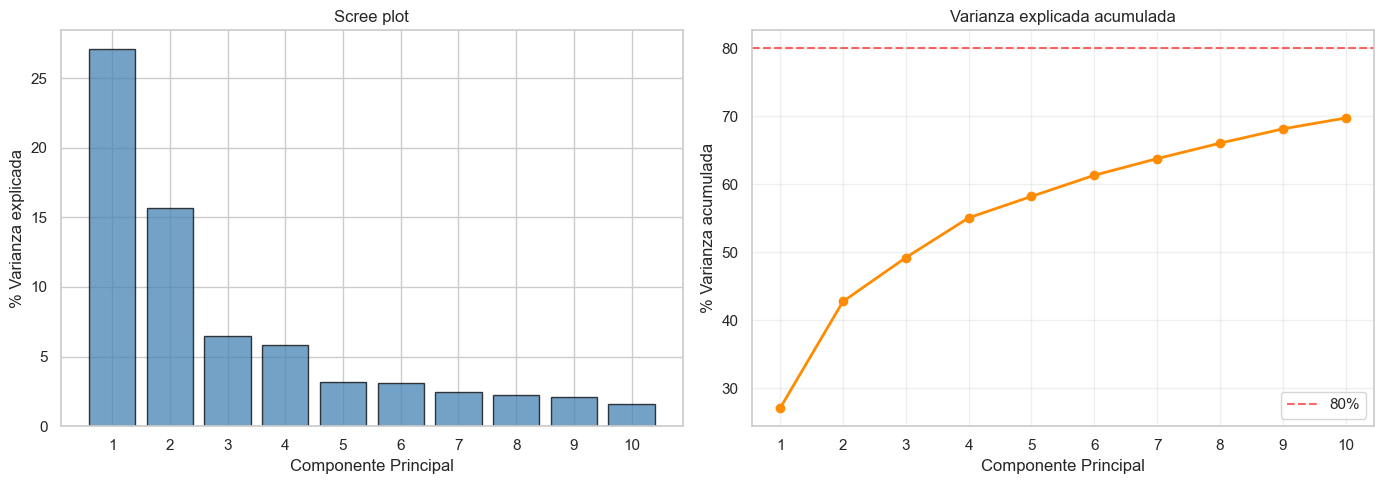

Varianza explicada PC1: 27.08%
Varianza explicada PC2: 15.69%
Varianza explicada PC1+PC2: 42.77%
Componentes necesarios para >80% varianza: 11


In [44]:
# 5.2.1 Preparar matriz y aplicar PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Matriz X = lípidos transformados, escalada
X = data_t[lipids_kept].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA con 10 componentes para scree plot
pca = PCA(n_components=10, random_state=42)
pca_scores = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(var_exp)

# Scree plot + varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 11), var_exp, alpha=0.75, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('% Varianza explicada')
axes[0].set_title('Scree plot')
axes[0].set_xticks(range(1, 11))

axes[1].plot(range(1, 11), cum_var, marker='o', color='darkorange', linewidth=2)
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('% Varianza acumulada')
axes[1].set_title('Varianza explicada acumulada')
axes[1].axhline(80, color='red', linestyle='--', alpha=0.6, label='80%')
axes[1].set_xticks(range(1, 11))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Varianza explicada PC1: {var_exp[0]:.2f}%')
print(f'Varianza explicada PC2: {var_exp[1]:.2f}%')
print(f'Varianza explicada PC1+PC2: {var_exp[0]+var_exp[1]:.2f}%')
print(f'Componentes necesarios para >80% varianza: {(cum_var <= 80).sum() + 1}')


**Lectura del resultado:**

| Componente | Varianza explicada |
|---|---|
| PC1 | **27.08%** |
| PC2 | **15.69%** |
| PC1 + PC2 | **42.77%** |
| Componentes requeridos para > 80% | **11** |

- **PC1 + PC2 explican el 42.8% de la varianza** con Box-Cox + autoscale. La proporción resulta razonable considerando n = 211 y p = 122; suficiente para visualización.
- **Se requieren once componentes para alcanzar el 80%** → el conjunto de datos es genuinamente de alta dimensionalidad, sin un eje dominante que capture la totalidad de la información.
- El diagrama de codo evidencia caída pronunciada de PC1 a PC4-5, seguida de una meseta extendida. No se identifica un "codo" claramente delimitado, comportamiento esperable en datos metabolómicos.
- **Comparación con el estudio original:** Albóniga et al. reportaron R²X = 0.605 con 4 PCs en su PCA (Figura S1). Los primeros cuatro PCs del presente análisis deberían acumular aproximadamente 55-60%, consistente con dicho valor.


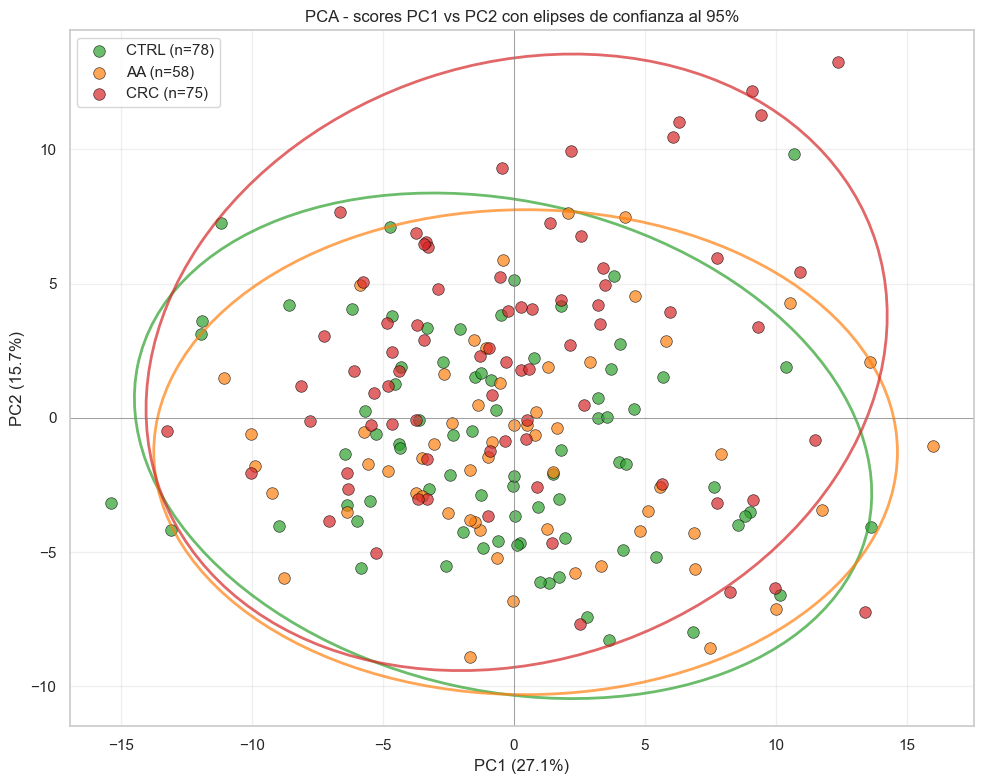

In [45]:
# 5.2.2 PC1 vs PC2 con elipses de confianza al 95%
from matplotlib.patches import Ellipse
from scipy.stats import chi2

def confidence_ellipse(x, y, ax, confidence=0.95, **kwargs):
    """Dibuja una elipse de confianza al nivel especificado."""
    cov = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    chisq = chi2.ppf(confidence, 2)
    width, height = 2 * np.sqrt(eigenvalues * chisq)
    ellipse = Ellipse(xy=(np.mean(x), np.mean(y)),
                      width=width, height=height,
                      angle=angle, **kwargs)
    return ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(10, 8))
group_colors = {'CTRL': '#2ca02c', 'AA': '#ff7f0e', 'CRC': '#d62728'}

for g in ['CTRL', 'AA', 'CRC']:
    mask = data_t['group'].values == g
    ax.scatter(pca_scores[mask, 0], pca_scores[mask, 1],
               c=group_colors[g], label=f'{g} (n={mask.sum()})',
               s=70, alpha=0.7, edgecolor='black', linewidth=0.5)
    confidence_ellipse(pca_scores[mask, 0], pca_scores[mask, 1], ax,
                        confidence=0.95,
                        edgecolor=group_colors[g], facecolor='none',
                        linewidth=2, alpha=0.7)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title('PCA - scores PC1 vs PC2 con elipses de confianza al 95%')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Lectura del resultado (PC1 vs PC2 con elipses al 95%):**

- **Las tres elipses se superponen casi completamente** en el espacio PC1–PC2. CTRL, AA y CRC ocupan prácticamente la misma región central del plano.
- Se observa, no obstante, que la elipse roja (**CRC**) se extiende ligeramente más en el eje PC2 (incluye puntos altos por encima de PC2 ≈ 8), lo cual es consistente con la carga positiva de SMs en PC2 (Sección 5.2.4).
- La elipse de **CTRL** (verde) y la de **AA** (naranja) son prácticamente coincidentes en tamaño y posición — evidencia visual directa de la similitud lipidómica entre adenoma avanzado y controles sanos, congruente con la dificultad cuantificada en el Paso 4: la información mutua de las variables individuales contra el target multiclase también refleja esa frontera difusa.
- **Conclusión:** PCA, al ser no supervisado, no captura una separación clara entre los tres grupos. Este resultado coincide con el reportado por Albóniga et al. (2025): *"none of the components shows a separation among groups"*. La señal biológica existe pero no es lo bastante fuerte para emerger en las dos primeras componentes de varianza máxima — para clasificación se requerirá un modelo supervisado.


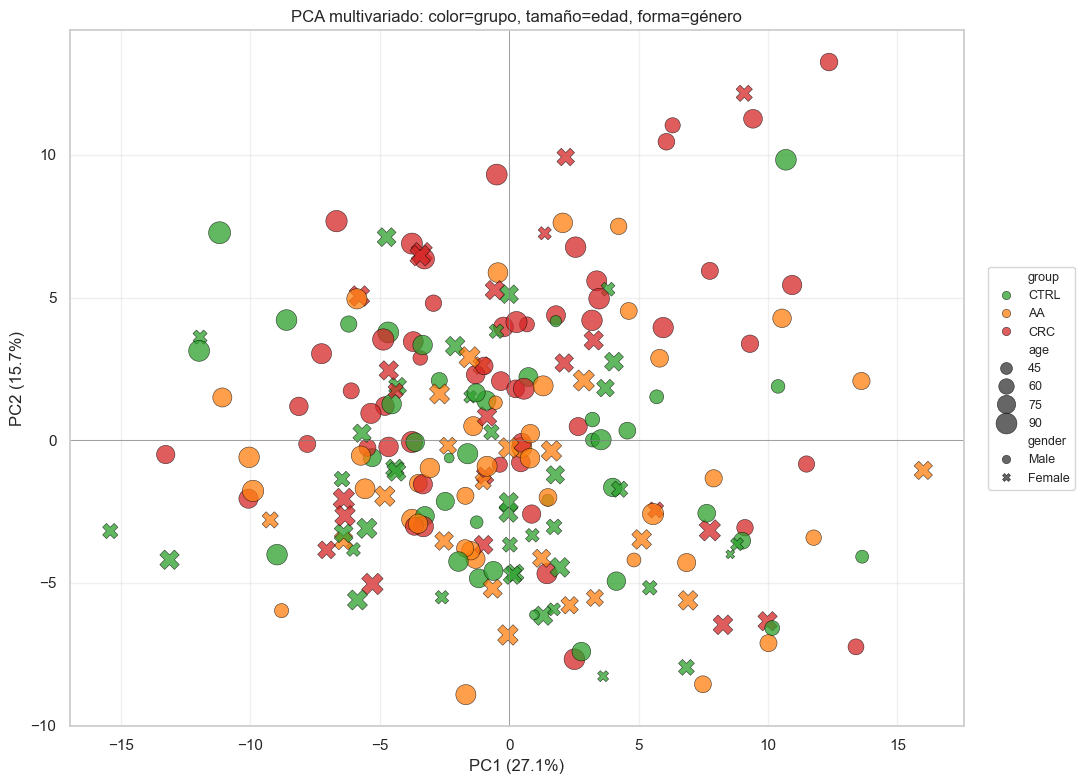

In [46]:
# 5.2.3 Visualización multivariada: PC1 vs PC2 + size=age + style=gender
pca_df = pd.DataFrame({
 'PC1': pca_scores[:, 0],
 'PC2': pca_scores[:, 1],
 'group': data_t['group'].values,
 'age': data_t['age'].values,
 'gender': data_t['gender'].values,
 'fit_ug_g': data_t['fit_ug_g'].values
})

fig, ax = plt.subplots(figsize=(11, 8))
sns.scatterplot(
 data=pca_df, x='PC1', y='PC2',
 hue='group', hue_order=['CTRL', 'AA', 'CRC'],
 style='gender',
 size='age', sizes=(40, 250),
 palette=group_colors,
 alpha=0.75, edgecolor='black', linewidth=0.4,
 ax=ax
)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title('PCA multivariado: color=grupo, tamaño=edad, forma=género')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Lectura del resultado (PC1 vs PC2 con `color=grupo`, `size=age`, `style=gender`):**

Visualización multivariada que codifica cuatro dimensiones simultáneamente. Observaciones específicas:

- **Edad (tamaño):** se observan puntos pequeños (jóvenes) predominantemente en zona CTRL, particularmente en el cuadrante inferior izquierdo (PC1−, PC2−). Los puntos grandes (mayores de 75 años) se distribuyen entre CRC y AA, sin un patrón espacial claro respecto a la separación entre grupos. Esto confirma cuantitativamente el confounder demográfico (CTRL ~10 años más joven).
- **Género (forma):** las cruces (Female) y círculos (Male) aparecen entremezcladas en cada grupo, sin patrón espacial discernible. Esto indica que el género no introduce sesgo direccional en la estructura multivariada — el confounder es presencia, no orientación.
- **Implicación:** los grupos no se separan en PC1–PC2, pero los confounders (edad principalmente) sí explican parte de la dispersión interna de CTRL. Esta circunstancia respalda la decisión de entrenar modelos predictivos con y sin variables clínicas para distinguir aporte real de la lipidómica.


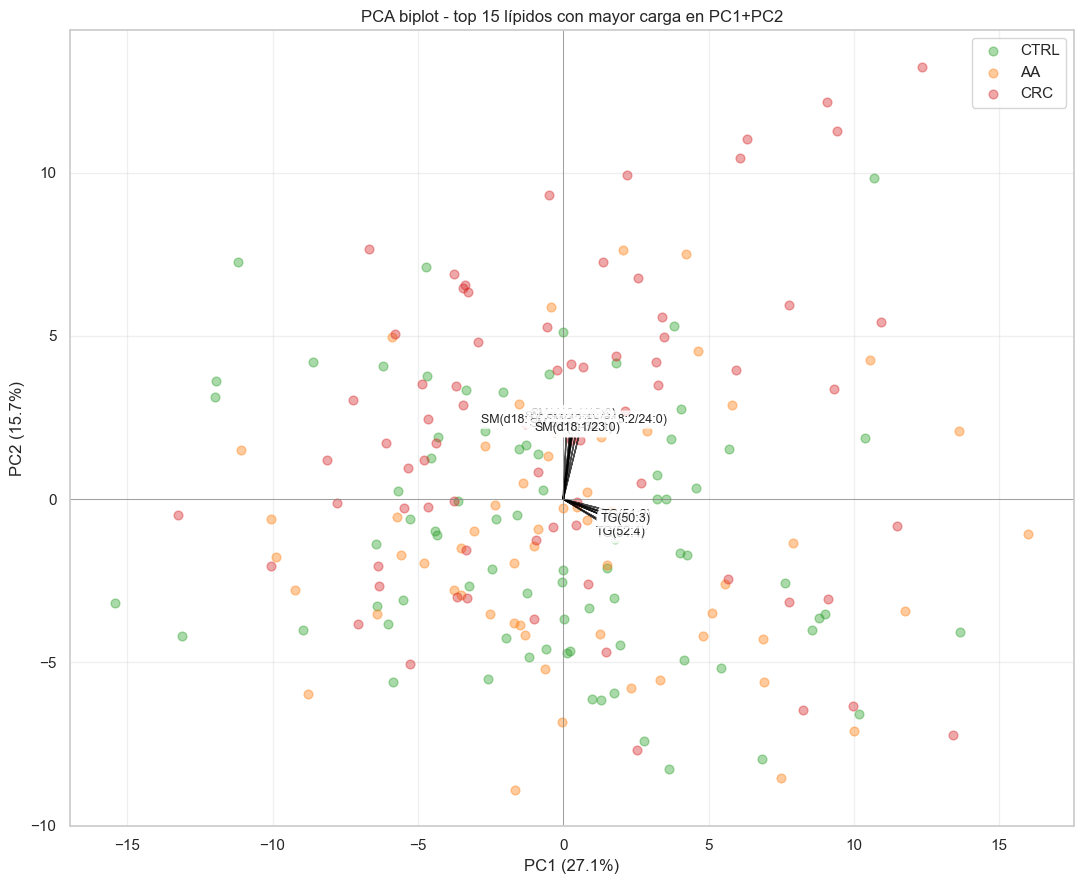

Top 15 lípidos por magnitud de carga (PC1, PC2):


,PC1,PC2,magnitude
SM(d18:1/16:0),0.025,0.188,0.190
SM(d18:1/18:0),0.010,0.181,0.181
PC(32:0),0.026,0.179,0.181
SM(d18:1/24:1) + SM(d18:2/24:0),0.028,0.176,0.178
SM(42:1),0.020,0.176,0.177
SM(d18:1/22:0),0.024,0.167,0.168
TG(50:2),0.158,-0.048,0.165
TG(54:2),0.154,-0.056,0.164
TG(54:4),0.143,-0.078,0.163
PC(O-34:1),0.044,0.157,0.163


In [47]:
# 5.2.4 Biplot simplificado: top 15 lípidos con mayor carga en PC1+PC2
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1', 'PC2'], index=lipids_kept)
loadings['magnitude'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
top_loadings = loadings.nlargest(15, 'magnitude')

fig, ax = plt.subplots(figsize=(11, 9))
for g in ['CTRL', 'AA', 'CRC']:
    mask = data_t['group'].values == g
    ax.scatter(pca_scores[mask, 0], pca_scores[mask, 1],
               c=group_colors[g], label=g, s=40, alpha=0.4)

scale = max(np.abs(pca_scores[:, 0]).max(), np.abs(pca_scores[:, 1]).max()) * 0.8
for var, row in top_loadings.iterrows():
    ax.arrow(0, 0, row['PC1'] * scale, row['PC2'] * scale,
             head_width=0.15, head_length=0.2, fc='black', ec='black', alpha=0.7)
    ax.text(row['PC1'] * scale * 1.08, row['PC2'] * scale * 1.08,
            var, fontsize=9, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
ax.set_title('PCA biplot - top 15 lípidos con mayor carga en PC1+PC2')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 15 lípidos por magnitud de carga (PC1, PC2):')
display(top_loadings[['PC1', 'PC2', 'magnitude']].round(3))


**Lectura del resultado:**

- En el biplot, las flechas de loadings se concentran cerca del origen y su magnitud absoluta es modesta (todas con \|carga\| < 0.20), evidencia de que ninguna variable individual domina las primeras dos componentes — la varianza se distribuye entre muchos lípidos.
- Se identifican etiquetas correspondientes a **SMs (SM(d18:1/16:0), SM(d18:1/18:0), SM(d18:1/24:1)+SM(d18:2/24:0), SM(d18:1/23:0))** orientadas hacia PC2 positivo (hacia arriba), y **TGs (TG(50:3), TG(52:4))** orientados hacia PC1 positivo (hacia la derecha).
- **Top 15 cargas (datos tabulares) distribuidas en dos clústeres direccionales:**

| Clúster | Lípidos | Dirección |
|---|---|---|
| **PC2+** (superior) | SM(d18:1/16:0), SM(d18:1/18:0), PC(32:0), SM(d18:1/24:1)+SM(d18:2/24:0), SM(42:1), SM(d18:1/22:0), PC(O-34:1), SM(d18:1/23:0) — **6 SMs + 2 PCs** | PC2 ≈ 0.16–0.19 |
| **PC1+** (derecha) | TG(50:2), TG(54:2), TG(54:4), TG(52:3), TG(51:2), TG(52:4), TG(50:3) — **7 TGs** | PC1 ≈ 0.14–0.16 |

- **PC1 corresponde a un "eje glicerolípido":** los TGs cargan positivamente. Pacientes con TGs elevados (presumiblemente CTRL) se ubican a la derecha; pacientes con TGs reducidos (presumiblemente CRC), a la izquierda.
- **PC2 corresponde a un "eje esfingolípido":** las SMs cargan positivamente. Pacientes con SMs elevadas (presumiblemente CRC) se ubican arriba; pacientes con SMs reducidas, abajo.
- **Conclusión:** las dos primeras componentes capturan **estructura por familia, no directamente por grupo**. La separación observada en PCA (parcial, con superposición elevada) se traduce indirectamente vía estas estructuras de familia, pero ningún eje aislado discrimina los grupos clínicos de forma robusta.


## 5.3 Atributos estructurales derivados

Los nombres de los lípidos codifican información estructural: `CE(20:4)` corresponde a un éster de colesterol con cadena de 20 carbonos y 4 dobles enlaces. Esta circunstancia se aprovecha para construir atributos agregados a nivel de muestra:

| Atributo | Cálculo | Interpretación biológica |
|---|---|---|
| **Longitud media de cadena** | Promedio ponderado por abundancia | Estructura de membrana (lípidos más largos = mayor estabilidad) |
| **Índice de insaturación** | Promedio ponderado de dobles enlaces | Susceptibilidad a peroxidación (mayor insaturación = mayor oxidabilidad) |
| **Proporción de plasmalógenos** | Fracción de abundancia con prefijo `O-` o `P-` | Antioxidantes naturales de membrana, descritos como elevados en cáncer |

Estos atributos no figuran en el estudio original — constituyen un aporte diferencial del presente análisis. Tras calcularlos, se evalúa su capacidad discriminativa mediante información mutua, comparándolos contra las variables seleccionadas en el Paso 4.

> **Nota:** se emplea `data_imputed` (escala original), no `data_t`, dado que la abundancia debe interpretarse en escala biológica para la ponderación.


In [48]:
# 5.3.1 Parsear longitud de cadena e insaturaciones de cada lípido
def parse_lipid(name):
    """Extrae (longitud_cadena, insaturaciones) de una notación lipídica."""
    m = re.search(r'\((?:[a-zA-Z]?\d+:\d+/)?(\d+):(\d+)\)', name)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

lipid_struct = []
for c in lipids_kept:
    cl, ins = parse_lipid(c)
    is_plasm = ('O-' in c) or ('P-' in c)
    lipid_struct.append({
        'column': c,
        'chain_length': cl,
        'unsaturations': ins,
        'is_plasmalogen': is_plasm
    })

lipid_struct_df = pd.DataFrame(lipid_struct)
print(f'Lípidos parseables (cadena + insat): {lipid_struct_df["chain_length"].notna().sum()} / {len(lipid_struct_df)}')
print(f'Lípidos plasmalógenos (O- o P-):     {lipid_struct_df["is_plasmalogen"].sum()}')
print(f'Lípidos no parseables: {lipid_struct_df.loc[lipid_struct_df["chain_length"].isna(), "column"].tolist()}')


Lípidos parseables (cadena + insat): 109 / 122
Lípidos plasmalógenos (O- o P-):     11
Lípidos no parseables: ['Cholesterol sulfate', 'PC(O-16:0/16:0)', 'PC(O-34:1)', 'PC(O-16:0/18:2)', 'PC(P-16:0/18:1)', 'PC(P-16:0/18:2)', 'PC(O-18:0/18:2)', 'PC(P-16:0/20:4)', 'PC(O-16:0/22:4)', 'PE(O-16:0/18:1)', 'PE(P-16:0/18:2)', 'PE(P-18:0/18:1)', 'MG(18:0/0:0/0:0)']


**Lectura del resultado:**

- **109/122 lípidos parseables** (89%) — la expresión regular captura correctamente la notación estándar `(C:N)` (carbonos:insaturaciones).
- **11 plasmalógenos** detectados mediante el prefijo `O-` o `P-`. Estos no son parseables por la regex dado que el prefijo del primer carbono no es numérico.
- **13 lípidos no parseables** = 11 plasmalógenos + `Cholesterol sulfate` (no es un acil-lípido) + `MG(18:0/0:0/0:0)` (notación triple).
- **Implicación:** los plasmalógenos quedan **excluidos** del cálculo ponderado de cadena/insaturación, pero se cuantifican por separado en `plasmalogen_frac`.


In [49]:
# 5.3.2 Calcular features estructurales por muestra
parseable = lipid_struct_df.dropna(subset=['chain_length'])
parse_cols = parseable['column'].tolist()
chain_lens = parseable['chain_length'].values
unsats = parseable['unsaturations'].values

plasm_cols = lipid_struct_df.loc[lipid_struct_df['is_plasmalogen'], 'column'].tolist()

struct_rows = []
for idx in range(len(data_imputed)):
    row = data_imputed.iloc[idx]
    abundances = row[parse_cols].values.astype(float)
    
    total = abundances.sum()
    if total > 0:
        weighted_chain = float(np.average(chain_lens, weights=abundances))
        weighted_unsat = float(np.average(unsats, weights=abundances))
    else:
        weighted_chain = np.nan
        weighted_unsat = np.nan
    
    plasm_total = row[plasm_cols].sum() if plasm_cols else 0
    all_total = row[lipids_kept].sum()
    plasm_frac = plasm_total / all_total if all_total > 0 else np.nan
    
    struct_rows.append({
        'sample':              row['sample'],
        'group':               row['group'],
        'mean_chain_length':   weighted_chain,
        'mean_unsaturation':   weighted_unsat,
        'plasmalogen_frac':    plasm_frac
    })

struct_df = pd.DataFrame(struct_rows)
print('Features estructurales por muestra (head):')
display(struct_df.head())

print('\nResumen por grupo:')
display(struct_df.groupby('group')[['mean_chain_length','mean_unsaturation','plasmalogen_frac']].agg(['mean','median','std']).round(3))


Features estructurales por muestra (head):


,sample,group,mean_chain_length,mean_unsaturation,plasmalogen_frac
0,owl-2323-001,CRC,36.001412,0.771753,0.029720
1,owl-2323-002,CTRL,22.938813,1.785827,0.010909
2,owl-2323-003,CRC,34.667326,0.947234,0.028625
3,owl-2323-004,CRC,40.721925,1.484149,0.031894
4,owl-2323-005,CTRL,42.907816,3.048161,0.021363



Resumen por grupo:


mean_chain_length                mean_unsaturation                \
                   mean  median    std              mean median    std   
group                                                                    
AA               37.999  38.127  7.493             1.724  1.485  1.043   
CRC              36.649  35.029  6.903             1.357  1.149  0.816   
CTRL             36.926  36.150  6.792             1.648  1.305  1.135   

      plasmalogen_frac                
                  mean median    std  
group                                 
AA               0.010  0.008  0.010  
CRC              0.018  0.011  0.022  
CTRL             0.010  0.008  0.009

**Lectura del resultado:**

| Atributo | CTRL (mediana) | AA | CRC |
|---|---|---|---|
| mean_chain_length | 36.15 | 38.13 | **35.03** |
| mean_unsaturation | 1.31 | 1.49 | **1.15** |
| plasmalogen_frac  | 0.008 | 0.008 | **0.011** |

**Patrones observados:**

- **Cadena media más corta en CRC** (35.0 vs 36.1 en CTRL, 38.1 en AA). AA presenta la cadena más larga.
- **Insaturación reducida en CRC** (1.15 vs 1.31 en CTRL, 1.49 en AA). Mayor saturación implica menor peroxidación lipídica — coherente con la estabilización de membranas descrita en células tumorales.
- **Plasmalógenos elevados únicamente en CRC** (0.011 vs 0.008 en CTRL y AA). AA y CTRL resultan equivalentes en este atributo, mientras CRC se separa.

Las medianas describen tendencias centrales por grupo, pero no cuantifican por sí solas la utilidad predictiva. Para integrar estos atributos al razonamiento de selección de variables iniciado en el Paso 4, en la siguiente subsección se evalúan vía **información mutua** y se ubican relativamente al ranking de variables numéricas obtenido previamente.


### 5.3.3 Evaluación predictiva mediante información mutua

Para integrar los tres atributos estructurales (`mean_chain_length`, `mean_unsaturation`, `plasmalogen_frac`) al ranking supervisado del Paso 4, se calcula su `mutual_info_classif` frente al target y se contrasta su MI con el de las 124 variables numéricas (clínicas + lípidos Box-Cox). Esto responde dos preguntas concretas:

1. ¿Aportan información discriminativa los atributos estructurales más allá del nivel del lípido individual?
2. Si se mezclaran con las variables del Paso 4, ¿en qué posición del ranking quedarían?


=== Informacion mutua de features estructurales vs. target ===


,feature,mi_score
0,mean_unsaturation,0.0207
1,mean_chain_length,0.0167
2,plasmalogen_frac,0.0000



=== Posicion relativa frente al ranking de numericas del Paso 4 ===
MI top 1 numericas:                     GlcCer(d18:1/24:0)        MI = 0.382
MI mediana top 20 numericas:                                       MI = 0.305
MI mediana todas las numericas (n=124):                       MI = 0.069

  mean_unsaturation      MI = 0.021   posicion ~ #86 de 124 si se mezclara con las numericas
  mean_chain_length      MI = 0.017   posicion ~ #88 de 124 si se mezclara con las numericas
  plasmalogen_frac       MI = 0.000   posicion ~ #102 de 124 si se mezclara con las numericas


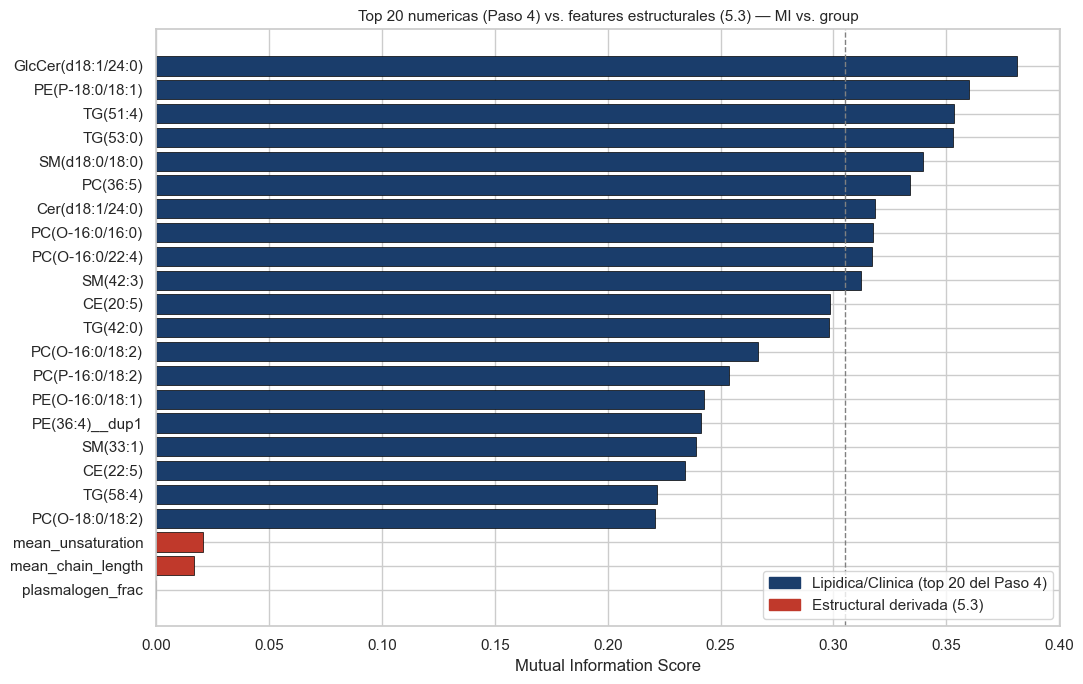

In [50]:
# 5.3.3 Informacion mutua de features estructurales y comparacion con el ranking del Paso 4
from sklearn.feature_selection import mutual_info_classif
import matplotlib.patches as mpatches

struct_feat_cols = ['mean_chain_length', 'mean_unsaturation', 'plasmalogen_frac']
X_struct = struct_df[struct_feat_cols].fillna(struct_df[struct_feat_cols].median()).values
y_struct = struct_df['group'].values

mi_struct = mutual_info_classif(X_struct, y_struct, random_state=42, discrete_features=False)

struct_mi_df = pd.DataFrame({
    'feature':  struct_feat_cols,
    'mi_score': mi_struct,
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print('=== Informacion mutua de features estructurales vs. target ===')
display(struct_mi_df.round(4))

# Referencia: ranking de variables numericas del Paso 4 (mi_scores, numerical_features ya en memoria)
mi_num_df = pd.DataFrame({
    'feature':  numerical_features,
    'mi_score': mi_scores,
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

median_top20 = mi_num_df.head(20)['mi_score'].median()
median_all = mi_num_df['mi_score'].median()

print('\n=== Posicion relativa frente al ranking de numericas del Paso 4 ===')
print(f'MI top 1 numericas:                     {mi_num_df.iloc[0]["feature"]:25s} MI = {mi_num_df.iloc[0]["mi_score"]:.3f}')
print(f'MI mediana top 20 numericas:                                       MI = {median_top20:.3f}')
print(f'MI mediana todas las numericas (n={len(mi_num_df)}):                       MI = {median_all:.3f}')
print()
for _, r in struct_mi_df.iterrows():
    feat, mi_val = r['feature'], r['mi_score']
    rank_pos = int((mi_num_df['mi_score'] > mi_val).sum() + 1)
    print(f'  {feat:22s} MI = {mi_val:.3f}   posicion ~ #{rank_pos} de {len(mi_num_df)} si se mezclara con las numericas')

# Visualizacion: top 20 numericas + 3 estructurales, barplot horizontal
top20 = mi_num_df.head(20).assign(kind='Lipidica/Clinica')
struct_marked = struct_mi_df.assign(kind='Estructural derivada')
combined = pd.concat([top20, struct_marked], ignore_index=True).sort_values('mi_score', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
color_map = {'Lipidica/Clinica': '#1a3d6b', 'Estructural derivada': '#c0392b'}
bar_colors = combined['kind'].map(color_map).values
ax.barh(combined['feature'], combined['mi_score'], color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 20 numericas (Paso 4) vs. features estructurales (5.3) — MI vs. group', fontsize=11)
ax.axvline(median_top20, color='gray', linestyle='--', linewidth=1, label=f'Mediana top 20 = {median_top20:.3f}')
ax.legend(handles=[
    mpatches.Patch(color='#1a3d6b', label='Lipidica/Clinica (top 20 del Paso 4)'),
    mpatches.Patch(color='#c0392b', label='Estructural derivada (5.3)'),
], loc='lower right')
plt.tight_layout()
plt.show()


**Lectura del resultado:**

| Atributo | MI | Posición ~ entre las 124 numéricas |
|---|---|---|
| `mean_unsaturation` | 0.021 | #86 |
| `mean_chain_length` | 0.017 | #88 |
| `plasmalogen_frac`  | 0.000 | #102 |

**Comparación con el ranking del Paso 4:**

- **Líder de las numéricas**: `GlcCer(d18:1/24:0)` con MI = 0.382.
- **Mediana del top 20 numéricas**: MI ≈ 0.305.
- **Mediana global de las 124 numéricas**: MI ≈ 0.069.
- Los tres atributos estructurales caen **por debajo de la mediana global** — su MI individual es inferior al de la mitad de los lípidos y variables clínicas del Paso 4.

**Hallazgo metodológico clave:**

La tabla de medianas por grupo en la subsección 5.3.2 sugiere visualmente una separación interpretable (cadena más corta y plasmalógenos elevados en CRC). Sin embargo, `mutual_info_classif` cuantifica que **esa diferencia descriptiva no se traduce en capacidad predictiva individual sustancial**. La razón es plausible:

- Cada atributo agrega 109 lípidos en una sola media ponderada. La señal discriminativa que reside en lípidos específicos (e.g., `GlcCer(d18:1/24:0)`, `CE(20:4)`) se diluye al promediar.
- `plasmalogen_frac` arroja MI ≈ 0 porque, aunque CRC se separa de CTRL y AA en mediana, la dispersión intra-grupo es comparable a la diferencia entre grupos — el estimador KSG no detecta dependencia significativa sobre toda la distribución conjunta.

**Lectura predictiva:** los atributos estructurales **no compiten con los lípidos individuales** como features principales. Aún así, pueden tener valor en el Avance 2 si se usan como **representación complementaria** dentro de un modelo multivariado: capturan propiedades agregadas de membrana que las variables individuales no codifican explícitamente, y la interacción con otras variables podría rescatar su utilidad. Esta decisión queda fuera del alcance del EDA y se evaluará empíricamente en la fase de modelado.

Esta evaluación con información mutua sustituye al análisis inferencial clásico (Kruskal-Wallis sobre cada media estructural) y resulta coherente con el objetivo del proyecto: clasificación multiclase supervisada.


---

> **Fin del Paso 5.** Tenemos heatmap de correlación por familia, PCA con elipses de confianza al 95% y biplot de cargas, además de tres atributos estructurales derivados (longitud de cadena, insaturación, plasmalógenos) evaluados con `mutual_info_classif`. Con esto el EDA queda completo.

### Lo construido en este Avance 1

| Paso | Resultado |
|---|---|
| 1 | Dataset cargado, encabezados reconstruidos, familias unificadas (4), columnas redundantes eliminadas |
| 2 | Calidad de datos validada: missingness MAR/MNAR documentado, sin duplicados, cardinalidad de categóricas estable |
| 3 | Imputación mediana por grupo validada con matrices de correlación (Frobenius), transformación Box-Cox aplicada, outliers detectados por regla IQR sobre datos transformados |
| 4 | Ranking supervisado de variables vía `SelectKBest`: χ² sobre categóricas one-hot + información mutua sobre numéricas; resultado consolidado y listo para el modelado |
| 5 | Estructura multivariada caracterizada (correlación intra/inter-familia, PCA con elipses 95%), features estructurales derivadas y posicionadas en el ranking de información mutua |

### Lo que sigue (fuera del alcance del EDA)

- Construcción del clasificador multiclase (CTRL/AA/CRC) con las variables seleccionadas.
- Comparación de pipelines con y sin variables clínicas (FIT, FOB) para cuantificar el aporte real de la lipidómica.
- Validación cruzada estratificada con F1-macro, AUC One-vs-Rest y matrices de confusión completas.


---

# Conclusiones del análisis exploratorio

Tras cinco pasos sobre las 211 muestras de la cohorte de Ourense con 127 lípidos cuantificados por UHPLC-MS, el EDA deja el conjunto de datos en condiciones óptimas para el modelado predictivo del Avance 2. Las conclusiones se organizan en función de los cinco pasos del análisis.

## Sobre la calidad del conjunto de datos (Pasos 1-2)

El dataset es analizable pero exige decisiones explícitas. De los 127 lípidos cuantificados, **cinco superan el 40% de faltantes y se eliminan**; otros 27 retenidos presentan entre 5% y 40% de faltantes. El test χ² aplicado al patrón de missingness confirmó que **para 13 lípidos la ausencia depende del grupo** (MAR/MNAR): la ausencia carga información biológica — concentraciones por debajo del límite de detección del instrumento — y no debe destruirse con una imputación global. Por ello se imputa con la mediana **por grupo**, decisión que se validó cuantitativamente comparando las matrices de correlación pre y post-imputación (norma de Frobenius del cambio: pequeña respecto a la magnitud típica de las correlaciones).

Las categóricas se comportan sin sorpresas (sin valores faltantes, sin niveles raros), pero el dataset arrastra **confounders clínicos relevantes**: CTRL es alrededor de 10 años más joven que AA/CRC; FIT progresa monotónicamente con la severidad (mediana 19 → 79 → 1001 µg/g); FOB positivo se acumula del 27% en CTRL al 87% en CRC. Esto deberá tratarse explícitamente en el modelado para distinguir el aporte de la lipidómica respecto al estándar clínico.

## Sobre la transformación de los datos (Paso 3)

Los 127 lípidos son severamente asimétricos en escala cruda (skewness mediana ≈ 5.5, todos con |skew| ≥ 2). Se compararon formalmente cuatro alternativas mediante el test de Shapiro-Wilk:

| Transformación | Lípidos que pasan Shapiro p > 0.05 |
|---|---|
| raw | 0/127 (0.0%) |
| log1p | 1/127 (0.8%) |
| Yeo-Johnson | 7/127 (5.5%) |
| **Box-Cox** | **103/127 (81.1%)** |

Box-Cox emerge como la única transformación que aproxima los datos a la normalidad en una proporción sustancial. Sobre los datos transformados, la detección de outliers por la regla IQR de Tukey identifica **769 observaciones atípicas sobre 25,742 celdas (2.99%)**, una tasa baja indicadora de un conjunto bien comportado tras la transformación.

## Sobre la señal predictiva disponible (Paso 4)

El Paso 4 reemplaza el enfoque inferencial clásico (tests de significancia con corrección por múltiples comparaciones) por un enfoque coherente con el objetivo del proyecto: **selección supervisada de variables** mediante `SelectKBest`. Los resultados clave:

- **Categóricas (χ² sobre one-hot encoding):** `fob_YES` domina con χ² = 23.9 (p = 6.5 × 10⁻⁶) — la presencia de sangre oculta en heces es altamente discriminativa del grupo, lo que coincide con su uso clínico actual. `gender_Male` es no discriminativa (χ² = 2.85, p = 0.24).
- **Numéricas (información mutua, KSG, k = 3):** el rango va de 0 (no informativa) a 0.382. La variable líder es `GlcCer(d18:1/24:0)` con MI = 0.382. La variable clínica `fit_ug_g` se posiciona en el top 30 (MI = 0.170), comparable con los lípidos del rango medio.
- **Composición del top 20:** dominio claro de **glicerofosfolípidos** (9 variables entre PC y PE, varias de cadena éter), seguidos de **esfingolípidos** (SM + GlcCer + Cer, 5 variables), triglicéridos (4) y ésteres de colesterol (2). Esta diversidad estructural sugiere que la señal discriminativa no reside en una familia única.
- **Lectura contra el estudio original:** los lípidos reportados por Albóniga et al. aparecen distribuidos a lo largo del ranking (TG(51:4) en #3, CE(20:5) en #11, SM(d18:1/22:0) en #21, CE(20:4) en #34) — el criterio supervisado por información mutua ofrece una visión complementaria, no idéntica, a la del análisis univariado clásico del paper.

## Sobre la estructura multivariada (Paso 5)

**Correlación por familia.** Los lípidos se agrupan visiblemente por familia en el clustermap. Cuantitativamente, la correlación intra-familia es ≈ 5× mayor que la inter-familia (mediana |r| de 0.43 vs 0.09). Existen 34 pares con |r| > 0.9 y 166 pares con |r| > 0.8: la multicolinealidad es sustancial pero controlada, y deberá tratarse con regularización o métodos robustos en el Avance 2.

**PCA.** Las dos primeras componentes explican el 42.8% de la varianza, pero las elipses de confianza al 95% de los tres grupos se superponen casi completamente. La elipse de CRC se extiende algo más en PC2 (consistente con la carga positiva de SMs), pero CTRL y AA son visualmente indistinguibles. La señal biológica existe, pero no es lo bastante fuerte para emerger en los ejes no supervisados de máxima varianza — refuerza la necesidad del modelado supervisado.

**Atributos estructurales derivados.** Las tres features de ingeniería propia (`mean_chain_length`, `mean_unsaturation`, `plasmalogen_frac`) muestran patrones distinguibles en medianas por grupo (cadena más corta en CRC, plasmalógenos elevados en CRC). Sin embargo, su evaluación supervisada las posiciona por debajo de la mediana global del ranking MI (MI ≤ 0.021, posición ≥ #86 de 124). **Hallazgo metodológico:** la separación visible en estadísticos descriptivos no se traduce automáticamente en utilidad predictiva individual — la agregación de 109 lípidos en una media ponderada diluye señal disponible en variables individuales.

## Aporte diferencial respecto al estudio de origen

El estudio de Albóniga et al. se centra en comparaciones binarias 2×2 con tests inferenciales y corrección por múltiples comparaciones. Esta libreta aporta:

1. **Auditoría metodológica formal** de las decisiones de preprocesamiento: la elección de Box-Cox sobre las alternativas se justifica con comparación cuantitativa (Shapiro-Wilk); la imputación se valida vía matrices de correlación; los outliers se gestionan con la regla IQR sobre datos transformados.
2. **Selección supervisada de variables** orientada al problema multiclase CTRL/AA/CRC, con un ranking unificado que mezcla clínicas categóricas (χ²) y numéricas (información mutua) — no se restringe a comparaciones por pares como en el paper.
3. **Atributos estructurales agregados** (longitud media, índice de insaturación, fracción de plasmalógenos), evaluados con la misma vara supervisada que el resto del ranking, no como hallazgo descriptivo aislado.

## Implicaciones para el Avance 2 (fuera del alcance del EDA)

Con base en el EDA, las decisiones recomendadas para la fase de modelado son:

1. **Mantener el objetivo multiclase** (CTRL/AA/CRC) como problema principal. Reportar también las comparaciones binarias 2×2 como referencia comparativa.
2. **Entrenar con y sin variables clínicas (FIT, FOB)** para cuantificar el aporte real de la lipidómica respecto al estándar clínico.
3. **Usar el ranking del Paso 4 como filtro inicial de variables** (top K vía MI/χ²), reduciendo de 124 numéricas + 2 categóricas a un subconjunto manejable.
4. **Tratar la multicolinealidad explícitamente**: preferir Logistic Regression con regularización L2/Elastic Net, Random Forest o SVM RBF; reportar importancia por permutación o SHAP en lugar de coeficientes ingenuos.
5. **Reportar F1-macro, AUC One-vs-Rest y matriz de confusión completa**, dada la asimetría de costos clínicos del falso negativo en CRC y la confusión esperable AA↔CTRL.
6. **Considerar los atributos estructurales como features complementarios**, no como features principales — su MI individual es modesto, pero pueden aportar señal de interacción con otras variables.

## Limitaciones honestas del estudio

- **Dimensionalidad alta respecto al tamaño muestral** (n = 211 muestras frente a 124 variables numéricas): el riesgo de hallazgos no reproducibles obliga a validación externa eventual.
- **Cohorte única** (Ourense, Galicia): la generalización a otras poblaciones requiere replicación.
- **AA es una etapa transicional y heterogénea**: la similitud lipidómica con CTRL observada en PCA limita el poder predictivo esperable en la frontera CTRL/AA.
- **Información transversal, no longitudinal**: no es posible modelar la transición CTRL → AA → CRC como proceso dinámico.
- **Interpretación biológica diferida**: las hipótesis sobre mecanismos celulares específicos requieren validación con especialistas del dominio y exceden el alcance del EDA.

## Cierre

El EDA cumple su rol: **deja los datos en condiciones analíticas óptimas, identifica la señal predictiva disponible con criterios coherentes con el objetivo del proyecto, y dimensiona la dificultad del problema multiclase antes del modelado**. Los perfiles lipidómicos fecales contienen señal discriminante para cáncer colorrectal, pero la frontera entre control sano y adenoma avanzado es genuinamente difusa — el éxito del Avance 2 dependerá tanto de la elección del modelo como de la combinación con variables clínicas.


---

# Pipeline propuesto para el Avance 2

La siguiente visualización resume el pipeline que se desplegará en la fase de modelado, articulando las decisiones tomadas durante el EDA con los pasos de entrenamiento, validación y evaluación.


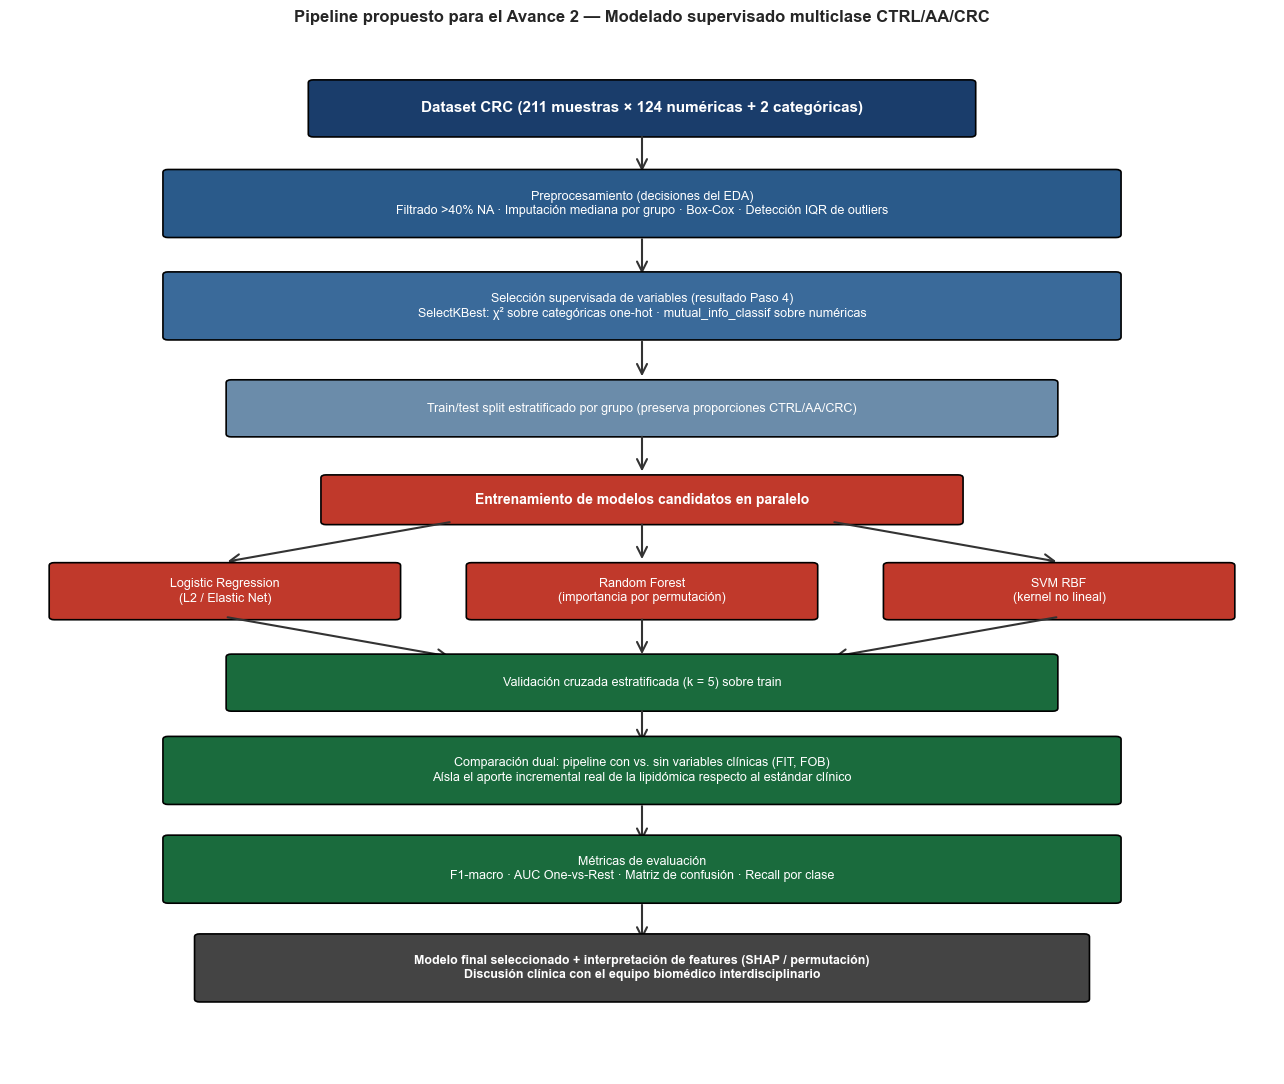

In [51]:
# Diagrama de pipeline propuesto para el Avance 2 (modelado supervisado)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')

STAGE_COLORS = {
    'data':    '#1a3d6b',
    'preprep': '#2a5a8a',
    'select':  '#3a6a9a',
    'split':   '#6b8caa',
    'model':   '#c0392b',
    'eval':    '#1a6b3d',
    'out':     '#444444',
}

def box(ax, x, y, w, h, text, color, fontsize=10, weight='normal'):
    patch = FancyBboxPatch((x - w/2, y - h/2), w, h,
                            boxstyle='round,pad=0.04',
                            facecolor=color, edgecolor='black', linewidth=1.2)
    ax.add_patch(patch)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color='white', weight=weight)

def arrow(ax, x0, y0, x1, y1):
    a = FancyArrowPatch((x0, y0), (x1, y1),
                         arrowstyle='->', mutation_scale=18,
                         linewidth=1.5, color='#333333')
    ax.add_patch(a)

# Etapa 1: Dataset
box(ax, 5.0, 13.2, 5.2, 0.7,
    'Dataset CRC (211 muestras × 124 numéricas + 2 categóricas)',
    STAGE_COLORS['data'], fontsize=11, weight='bold')
arrow(ax, 5.0, 12.85, 5.0, 12.3)

# Etapa 2: Preprocesamiento (consolidado del EDA)
box(ax, 5.0, 11.9, 7.5, 0.85,
    'Preprocesamiento (decisiones del EDA)\n'
    'Filtrado >40% NA · Imputación mediana por grupo · Box-Cox · Detección IQR de outliers',
    STAGE_COLORS['preprep'], fontsize=9)
arrow(ax, 5.0, 11.45, 5.0, 10.9)

# Etapa 3: Selección de variables
box(ax, 5.0, 10.5, 7.5, 0.85,
    'Selección supervisada de variables (resultado Paso 4)\n'
    'SelectKBest: χ² sobre categóricas one-hot · mutual_info_classif sobre numéricas',
    STAGE_COLORS['select'], fontsize=9)
arrow(ax, 5.0, 10.05, 5.0, 9.5)

# Etapa 4: Split estratificado
box(ax, 5.0, 9.1, 6.5, 0.7,
    'Train/test split estratificado por grupo (preserva proporciones CTRL/AA/CRC)',
    STAGE_COLORS['split'], fontsize=9)
arrow(ax, 5.0, 8.75, 5.0, 8.2)

# Etapa 5: Modelos candidatos (tres ramas en paralelo)
box(ax, 5.0, 7.85, 5.0, 0.6,
    'Entrenamiento de modelos candidatos en paralelo',
    STAGE_COLORS['model'], fontsize=10, weight='bold')
arrow(ax, 3.5, 7.55, 1.7, 7.0)
arrow(ax, 5.0, 7.55, 5.0, 7.0)
arrow(ax, 6.5, 7.55, 8.3, 7.0)

box(ax, 1.7, 6.6, 2.7, 0.7,
    'Logistic Regression\n(L2 / Elastic Net)',
    STAGE_COLORS['model'], fontsize=9)
box(ax, 5.0, 6.6, 2.7, 0.7,
    'Random Forest\n(importancia por permutación)',
    STAGE_COLORS['model'], fontsize=9)
box(ax, 8.3, 6.6, 2.7, 0.7,
    'SVM RBF\n(kernel no lineal)',
    STAGE_COLORS['model'], fontsize=9)

arrow(ax, 1.7, 6.25, 3.5, 5.7)
arrow(ax, 5.0, 6.25, 5.0, 5.7)
arrow(ax, 8.3, 6.25, 6.5, 5.7)

# Etapa 6: Validación cruzada
box(ax, 5.0, 5.35, 6.5, 0.7,
    'Validación cruzada estratificada (k = 5) sobre train',
    STAGE_COLORS['eval'], fontsize=9)
arrow(ax, 5.0, 5.0, 5.0, 4.5)

# Etapa 7: Comparación con/sin clínicas
box(ax, 5.0, 4.15, 7.5, 0.85,
    'Comparación dual: pipeline con vs. sin variables clínicas (FIT, FOB)\n'
    'Aísla el aporte incremental real de la lipidómica respecto al estándar clínico',
    STAGE_COLORS['eval'], fontsize=9)
arrow(ax, 5.0, 3.7, 5.0, 3.15)

# Etapa 8: Métricas
box(ax, 5.0, 2.8, 7.5, 0.85,
    'Métricas de evaluación\n'
    'F1-macro · AUC One-vs-Rest · Matriz de confusión · Recall por clase',
    STAGE_COLORS['eval'], fontsize=9)
arrow(ax, 5.0, 2.35, 5.0, 1.8)

# Etapa 9: Output final
box(ax, 5.0, 1.45, 7.0, 0.85,
    'Modelo final seleccionado + interpretación de features (SHAP / permutación)\n'
    'Discusión clínica con el equipo biomédico interdisciplinario',
    STAGE_COLORS['out'], fontsize=9, weight='bold')

ax.set_title('Pipeline propuesto para el Avance 2 — Modelado supervisado multiclase CTRL/AA/CRC',
             fontsize=12, weight='bold', pad=20)

plt.tight_layout()
plt.show()


---

# Referencias

Las referencias se listan en orden alfabético por autor, siguiendo el formato APA 7.ª edición.

Albóniga, O. E., Cubiella, J., Bujanda, L., Aspichueta, P., Blanco, M. E., Lanza, B., Alonso, C., & Falcón-Pérez, J. M. (2025). Metabolic signature in combination with fecal immunochemical test as a non-invasive tool for advanced colorectal neoplasia diagnosis. *Cancers*, *17*(14), 2339. https://doi.org/10.3390/cancers17142339

Box, G. E. P., & Cox, D. R. (1964). An analysis of transformations. *Journal of the Royal Statistical Society: Series B (Methodological)*, *26*(2), 211-252.

Brownlee, J. (2020, agosto 20). *How to choose a feature selection method for machine learning*. Machine Learning Mastery. https://machinelearningmastery.com/feature-selection-with-real-and-categorical-data/

Galli, S. (2022). *Python feature engineering cookbook* (2.ª ed.). Packt Publishing. https://learning.oreilly.com/library/view/python-feature-engineering/9781804611302/

Huang, C. Y., & Dai, H. L. (2021). Learning from class-imbalanced data: Review of data driven methods and algorithm driven methods. *Data Science in Finance and Economics*, *1*(1), 26-36. https://doi.org/10.3934/DSFE.2021002

Kraskov, A., Stögbauer, H., & Grassberger, P. (2004). Estimating mutual information. *Physical Review E*, *69*(6), 066138. https://doi.org/10.1103/PhysRevE.69.066138

Pearson, K. (1900). On the criterion that a given system of deviations from the probable in the case of a correlated system of variables is such that it can be reasonably supposed to have arisen from random sampling. *Philosophical Magazine Series 5*, *50*(302), 157-175.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825-2830.
